In [77]:
from pathlib import Path
import pandas as pd
import numpy as np

# BU_TotActPwr_Academy

In [78]:
from pathlib import Path
import pandas as pd
import numpy as np

# Change these paths to your actual saved prediction CSVs
prediction_files = {
    "15min": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_130357_63eba77e_ridge_BU_TotActPwr_Academy_profile_predictions.csv"),
    "30min": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_144150_088cccee_ridge_BU_TotActPwr_Academy_profile_predictions.csv"),
    "60min": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_093036_4a85546b_xgboost_BU_TotActPwr_Academy_profile_predictions.csv"),
}

target_col = "BU_TotActPwr_Academy"  

In [79]:
from pathlib import Path
import pandas as pd
import numpy as np


def resolution_to_hours(resolution: str) -> float:
    mapping = {
        "15min": 15 / 60,
        "30min": 30 / 60,
        "60min": 60 / 60,
    }
    if resolution not in mapping:
        raise ValueError(f"Unknown resolution: {resolution}")
    return mapping[resolution]


def daily_energy_from_profile_predictions(pred_path: Path, resolution: str) -> pd.DataFrame:


    dt_hours = resolution_to_hours(resolution)

    df = pd.read_csv(pred_path)

    # First column is usually the saved index / issue timestamp
    first_col = df.columns[0]
    df[first_col] = pd.to_datetime(df[first_col], errors="coerce")

    df = df.dropna(subset=[first_col]).copy()
    df = df.rename(columns={first_col: "issue_time"})

    true_cols = sorted([c for c in df.columns if c.endswith("_true")])
    pred_cols = sorted([c for c in df.columns if c.endswith("_pred")])

    if not true_cols:
        raise ValueError(f"No *_true columns found in: {pred_path}")

    if not pred_cols:
        raise ValueError(f"No *_pred columns found in: {pred_path}")

    if len(true_cols) != len(pred_cols):
        raise ValueError(
            f"Different number of true and pred columns in {pred_path}: "
            f"{len(true_cols)} true vs {len(pred_cols)} pred"
        )

    rows = []

    for _, row in df.iterrows():
        issue_time = row["issue_time"]

        # Your forecast is issued at the end of the previous day.
        # So the predicted profile belongs to the next calendar day.
        forecast_date = (issue_time + pd.Timedelta(days=1)).date()

        actual_energy_kWh = row[true_cols].sum() * dt_hours
        predicted_energy_kWh = row[pred_cols].sum() * dt_hours

        rows.append({
            "date": forecast_date,
            "issue_time": issue_time,
            "resolution": resolution,
            "actual_energy_kWh": actual_energy_kWh,
            "predicted_energy_kWh": predicted_energy_kWh,
            "n_horizon_steps": len(true_cols),
        })

    daily = pd.DataFrame(rows)

    daily["energy_error_kWh"] = (
        daily["predicted_energy_kWh"] - daily["actual_energy_kWh"]
    )

    daily["abs_energy_error_kWh"] = daily["energy_error_kWh"].abs()

    daily["energy_error_percent"] = np.where(
        daily["actual_energy_kWh"] != 0,
        daily["energy_error_kWh"] / daily["actual_energy_kWh"] * 100,
        np.nan,
    )

    daily["abs_energy_error_percent"] = daily["energy_error_percent"].abs()

    return daily

In [80]:
daily_tables = []

for resolution, path in prediction_files.items():
    daily_res = daily_energy_from_profile_predictions(path, resolution)
    daily_tables.append(daily_res)

daily_energy_all = pd.concat(daily_tables, ignore_index=True)

display(daily_energy_all.head())

,date,issue_time,resolution,actual_energy_kWh,predicted_energy_kWh,n_horizon_steps,energy_error_kWh,abs_energy_error_kWh,energy_error_percent,abs_energy_error_percent
0,2026-04-12,2026-04-11 23:45:00,15min,214.890830,247.197948,96,32.307118,32.307118,15.034200,15.034200
1,2026-04-13,2026-04-12 23:45:00,15min,280.942675,192.450229,96,-88.492446,88.492446,-31.498399,31.498399
2,2026-04-14,2026-04-13 23:45:00,15min,232.991928,219.968789,96,-13.023138,13.023138,-5.589523,5.589523
3,2026-04-15,2026-04-14 23:45:00,15min,238.207250,220.326330,96,-17.880920,17.880920,-7.506455,7.506455
4,2026-04-16,2026-04-15 23:45:00,15min,183.301413,206.467979,96,23.166567,23.166567,12.638510,12.638510


In [81]:
required_resolutions = set(prediction_files.keys())

date_counts = (
    daily_energy_all
    .groupby("date")["resolution"]
    .nunique()
)

common_dates = date_counts[date_counts == len(required_resolutions)].index

daily_energy_common = daily_energy_all[
    daily_energy_all["date"].isin(common_dates)
].copy()

print("Common comparison days:", len(common_dates))
display(daily_energy_common.head())

Common comparison days: 19


,date,issue_time,resolution,actual_energy_kWh,predicted_energy_kWh,n_horizon_steps,energy_error_kWh,abs_energy_error_kWh,energy_error_percent,abs_energy_error_percent
0,2026-04-12,2026-04-11 23:45:00,15min,214.890830,247.197948,96,32.307118,32.307118,15.034200,15.034200
1,2026-04-13,2026-04-12 23:45:00,15min,280.942675,192.450229,96,-88.492446,88.492446,-31.498399,31.498399
2,2026-04-14,2026-04-13 23:45:00,15min,232.991928,219.968789,96,-13.023138,13.023138,-5.589523,5.589523
3,2026-04-15,2026-04-14 23:45:00,15min,238.207250,220.326330,96,-17.880920,17.880920,-7.506455,7.506455
4,2026-04-16,2026-04-15 23:45:00,15min,183.301413,206.467979,96,23.166567,23.166567,12.638510,12.638510


In [82]:
day_score = (
    daily_energy_common
    .groupby("date")
    .agg(
        mean_abs_energy_error_kWh=("abs_energy_error_kWh", "mean"),
        max_abs_energy_error_kWh=("abs_energy_error_kWh", "max"),
        mean_abs_energy_error_percent=("abs_energy_error_percent", "mean"),
    )
    .reset_index()
)

best_day = day_score.sort_values("mean_abs_energy_error_kWh", ascending=True).iloc[0]["date"]
worst_day = day_score.sort_values("mean_abs_energy_error_kWh", ascending=False).iloc[0]["date"]

print("Best forecasted day:", best_day)
print("Worst forecasted day:", worst_day)

display(day_score.sort_values("mean_abs_energy_error_kWh").head(10))
display(day_score.sort_values("mean_abs_energy_error_kWh", ascending=False).head(10))

Best forecasted day: 2026-04-24
Worst forecasted day: 2026-04-13


,date,mean_abs_energy_error_kWh,max_abs_energy_error_kWh,mean_abs_energy_error_percent
12,2026-04-24,4.469960,7.278990,2.642650
2,2026-04-14,5.062340,13.023138,2.172753
5,2026-04-17,8.075758,20.576383,4.842677
3,2026-04-15,17.741083,18.471585,7.447423
7,2026-04-19,18.769136,24.968685,17.970399
16,2026-04-28,19.402385,31.223313,11.075022
18,2026-04-30,23.271441,33.292886,14.935398
4,2026-04-16,27.659056,30.500671,15.089385
17,2026-04-29,28.001782,42.070130,15.193684
11,2026-04-23,31.520011,45.139574,17.957141


,date,mean_abs_energy_error_kWh,max_abs_energy_error_kWh,mean_abs_energy_error_percent
1,2026-04-13,77.310308,88.492446,27.518180
14,2026-04-26,51.666594,53.392525,50.870056
13,2026-04-25,51.415340,63.644427,48.033240
0,2026-04-12,41.180543,56.561225,19.163471
6,2026-04-18,38.243173,47.785974,36.350722
8,2026-04-20,36.956952,58.760097,21.619340
10,2026-04-22,35.014950,48.219916,21.203691
9,2026-04-21,33.069837,42.703389,19.877280
15,2026-04-27,32.420754,39.215411,17.558385
11,2026-04-23,31.520011,45.139574,17.957141


In [83]:
best_worst_comparison = daily_energy_common[
    daily_energy_common["date"].isin([best_day, worst_day])
].copy()

best_worst_comparison["day_type"] = np.where(
    best_worst_comparison["date"] == best_day,
    "best_day",
    "worst_day",
)

best_worst_comparison = best_worst_comparison[
    [
        "day_type",
        "date",
        "resolution",
        "actual_energy_kWh",
        "predicted_energy_kWh",
        "energy_error_kWh",
        "abs_energy_error_kWh",
        "energy_error_percent",
        "abs_energy_error_percent",
        "n_horizon_steps",
    ]
].sort_values(["day_type", "resolution"])

display(best_worst_comparison)

,day_type,date,resolution,actual_energy_kWh,predicted_energy_kWh,energy_error_kWh,abs_energy_error_kWh,energy_error_percent,abs_energy_error_percent,n_horizon_steps
12,best_day,2026-04-24,15min,169.146848,161.867858,-7.278990,7.278990,-4.303355,4.303355,96
31,best_day,2026-04-24,30min,169.146845,163.342233,-5.804612,5.804612,-3.431700,3.431700,48
50,best_day,2026-04-24,60min,169.146820,169.473097,0.326277,0.326277,0.192896,0.192896,24
1,worst_day,2026-04-13,15min,280.942675,192.450229,-88.492446,88.492446,-31.498399,31.498399,96
20,worst_day,2026-04-13,30min,280.942655,204.356793,-76.585862,76.585862,-27.260318,27.260318,48
39,worst_day,2026-04-13,60min,280.942670,214.090054,-66.852616,66.852616,-23.795821,23.795821,24


## total test-period energy comparison

In [84]:
total_energy_comparison = (
    daily_energy_common
    .groupby("resolution")
    .agg(
        actual_energy_kWh=("actual_energy_kWh", "sum"),
        predicted_energy_kWh=("predicted_energy_kWh", "sum"),
        total_abs_daily_error_kWh=("abs_energy_error_kWh", "sum"),
        mean_daily_abs_error_kWh=("abs_energy_error_kWh", "mean"),
        mean_daily_abs_error_percent=("abs_energy_error_percent", "mean"),
        n_days=("date", "nunique"),
    )
    .reset_index()
)

total_energy_comparison["total_energy_error_kWh"] = (
    total_energy_comparison["predicted_energy_kWh"]
    - total_energy_comparison["actual_energy_kWh"]
)

total_energy_comparison["total_energy_error_percent"] = np.where(
    total_energy_comparison["actual_energy_kWh"] != 0,
    total_energy_comparison["total_energy_error_kWh"]
    / total_energy_comparison["actual_energy_kWh"] * 100,
    np.nan,
)

display(total_energy_comparison.sort_values("mean_daily_abs_error_kWh"))

,resolution,actual_energy_kWh,predicted_energy_kWh,total_abs_daily_error_kWh,mean_daily_abs_error_kWh,mean_daily_abs_error_percent,n_days,total_energy_error_kWh,total_energy_error_percent
2,60min,3281.22288,3436.793547,438.314625,23.069191,14.907553,19,155.570667,4.741240
1,30min,3281.89139,3203.467436,642.148573,33.797293,21.555306,19,-78.423954,-2.389596
0,15min,3283.56846,3117.018273,663.290999,34.910053,22.198336,19,-166.550187,-5.072231


## Optional plot for best and worst day

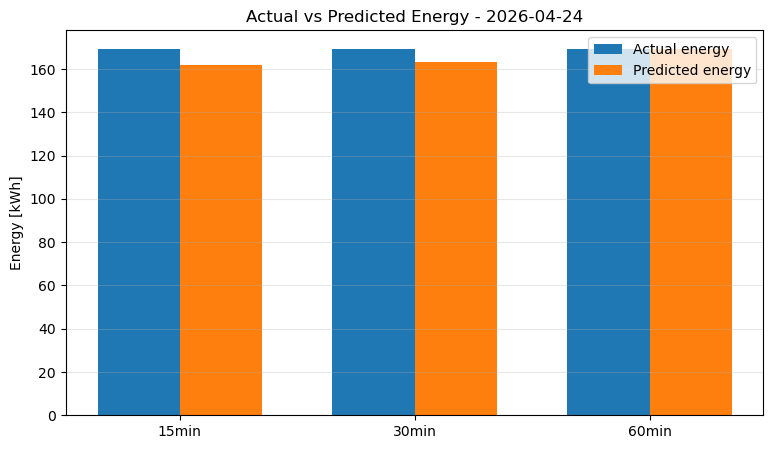

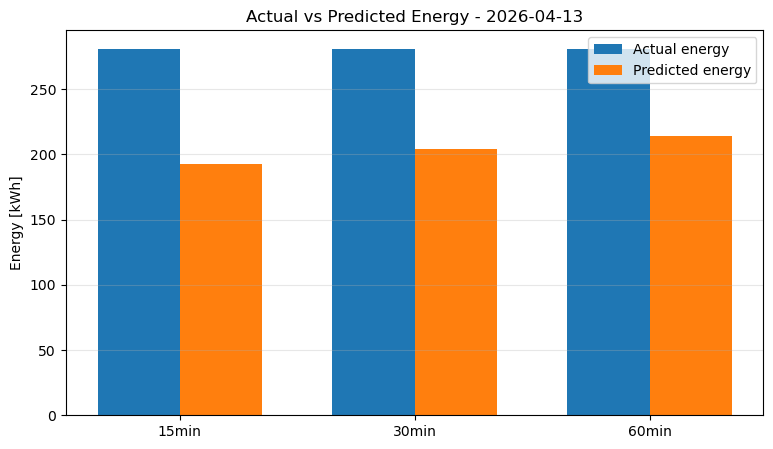

In [85]:
import matplotlib.pyplot as plt

def plot_energy_comparison_for_day(daily_df, selected_day):
    plot_df = daily_df[daily_df["date"] == selected_day].copy()
    plot_df = plot_df.sort_values("resolution")

    x = np.arange(len(plot_df))
    width = 0.35

    plt.figure(figsize=(9, 5))
    plt.bar(x - width/2, plot_df["actual_energy_kWh"], width, label="Actual energy")
    plt.bar(x + width/2, plot_df["predicted_energy_kWh"], width, label="Predicted energy")

    plt.xticks(x, plot_df["resolution"])
    plt.ylabel("Energy [kWh]")
    plt.title(f"Actual vs Predicted Energy - {selected_day}")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.show()


plot_energy_comparison_for_day(daily_energy_common, best_day)
plot_energy_comparison_for_day(daily_energy_common, worst_day)

All rows: 57
Rows with valid constant baseline: 54


,date,issue_time,resolution,n_horizon_steps,actual_energy_kWh,ml_predicted_energy_kWh,constant_load_kW,constant_energy_kWh,ml_residual_energy_kWh,constant_residual_energy_kWh,ml_abs_energy_error_kWh,constant_abs_energy_error_kWh,ml_abs_energy_error_%,constant_abs_energy_error_%,ml_error_reduction_vs_constant_kWh,ml_error_reduction_vs_constant_%
1,2026-04-13,2026-04-12 23:45:00,15min,96,280.942675,192.450229,3.43267,82.38408,88.492446,198.558595,88.492446,198.558595,31.498399,70.675840,110.066149,55.432579
2,2026-04-14,2026-04-13 23:45:00,15min,96,232.991928,219.968789,4.63800,111.31200,13.023138,121.679928,13.023138,121.679928,5.589523,52.224954,108.656789,89.297217
3,2026-04-15,2026-04-14 23:45:00,15min,96,238.207250,220.326330,3.84433,92.26392,17.880920,145.943330,17.880920,145.943330,7.506455,61.267375,128.062410,87.748039
4,2026-04-16,2026-04-15 23:45:00,15min,96,183.301412,206.467979,4.65000,111.60000,-23.166567,71.701412,23.166567,71.701412,12.638510,39.116672,48.534846,67.690223
5,2026-04-17,2026-04-16 23:45:00,15min,96,166.762252,168.298104,3.86600,92.78400,-1.535851,73.978252,1.535851,73.978252,0.920983,44.361510,72.442401,97.923915


Best forecasted day based on ML energy error: 2026-04-24
Worst forecasted day based on ML energy error: 2026-04-13

Best days:


,date,mean_ml_abs_error_kWh,mean_constant_abs_error_kWh,mean_ml_abs_error_percent,mean_constant_abs_error_percent,mean_ml_reduction_vs_constant_kWh,mean_ml_reduction_vs_constant_percent,n_resolutions
11,2026-04-24,4.469960,83.995477,2.642650,49.658320,79.525518,94.689556,3
1,2026-04-14,5.062340,118.607289,2.172753,50.906179,113.544949,95.817618,3
4,2026-04-17,8.075758,75.894967,4.842677,45.510881,67.819210,89.450118,3
2,2026-04-15,17.741083,142.101057,7.447423,59.651415,124.359974,87.508821,3
6,2026-04-19,18.769136,16.400022,17.970399,15.702104,-2.369115,-14.358945,3
15,2026-04-28,19.402385,81.395218,11.075022,46.460978,61.992833,76.310845,3
17,2026-04-30,23.271441,40.776437,14.935398,26.161606,17.504996,39.331949,3
3,2026-04-16,27.659056,70.722134,15.089385,38.582427,43.063078,60.840221,3
16,2026-04-29,28.001782,93.382192,15.193684,50.668901,65.380410,70.028162,3
10,2026-04-23,31.520011,90.058988,17.957141,51.322876,58.538977,64.981400,3



Worst days:


,date,mean_ml_abs_error_kWh,mean_constant_abs_error_kWh,mean_ml_abs_error_percent,mean_constant_abs_error_percent,mean_ml_reduction_vs_constant_kWh,mean_ml_reduction_vs_constant_percent,n_resolutions
0,2026-04-13,77.310308,196.785947,27.518180,70.044877,119.475639,60.755941,3
13,2026-04-26,51.666594,12.887828,50.870056,12.689138,-38.778765,-303.021068,3
12,2026-04-25,51.415340,22.219805,48.033240,20.758187,-29.195535,-130.201108,3
5,2026-04-18,38.243173,14.860092,36.350722,14.124745,-23.383081,-156.867353,3
7,2026-04-20,36.956952,79.959629,21.619340,46.781044,43.002678,52.606271,3
9,2026-04-22,35.014950,76.469388,21.203691,46.311762,41.454438,54.124045,3
8,2026-04-21,33.069837,78.788850,19.877280,47.400884,45.719013,58.217390,3
14,2026-04-27,32.420754,99.118697,17.558385,53.680562,66.697944,67.250896,3
10,2026-04-23,31.520011,90.058988,17.957141,51.322876,58.538977,64.981400,3
16,2026-04-29,28.001782,93.382192,15.193684,50.668901,65.380410,70.028162,3


,day_type,date,issue_time,resolution,actual_energy_kWh,ml_predicted_energy_kWh,ml_residual_energy_kWh,ml_abs_energy_error_kWh,ml_abs_energy_error_%,constant_load_kW,constant_energy_kWh,constant_residual_energy_kWh,constant_abs_energy_error_kWh,constant_abs_energy_error_%,ml_error_reduction_vs_constant_kWh,ml_error_reduction_vs_constant_%,n_horizon_steps
12,best_day,2026-04-24,2026-04-23 23:45:00,15min,169.146847,161.867858,7.278990,7.278990,4.303355,3.52767,84.66408,84.482767,84.482767,49.946404,77.203778,91.384054,96
31,best_day,2026-04-24,2026-04-23 23:30:00,30min,169.146845,163.342233,5.804612,5.804612,3.431700,3.55550,85.33200,83.814845,83.814845,49.551527,78.010233,93.074482,48
50,best_day,2026-04-24,2026-04-23 23:00:00,60min,169.146820,169.473097,-0.326277,0.326277,0.192896,3.56075,85.45800,83.688820,83.688820,49.477028,83.362543,99.610131,24
1,worst_day,2026-04-13,2026-04-12 23:45:00,15min,280.942675,192.450229,88.492446,88.492446,31.498399,3.43267,82.38408,198.558595,198.558595,70.675840,110.066149,55.432579,96
20,worst_day,2026-04-13,2026-04-12 23:30:00,30min,280.942655,204.356793,76.585862,76.585862,27.260318,3.42800,82.27200,198.670655,198.670655,70.715732,122.084793,61.450843,48
39,worst_day,2026-04-13,2026-04-12 23:00:00,60min,280.942670,214.090054,66.852616,66.852616,23.795821,3.65892,87.81408,193.128590,193.128590,68.743061,126.275974,65.384402,24


,day_type,date,actual_energy_kWh,ml_predicted_energy_kWh,constant_energy_kWh,ml_abs_energy_error_kWh,constant_abs_energy_error_kWh,ml_abs_energy_error_percent,constant_abs_energy_error_percent,ml_error_reduction_vs_constant_kWh,ml_error_reduction_vs_constant_percent
0,best_day,2026-04-24,169.146837,164.894396,85.15136,4.469960,83.995477,2.64265,49.658320,79.525518,94.689556
1,worst_day,2026-04-13,280.942667,203.632359,84.15672,77.310308,196.785947,27.51818,70.044877,119.475639,60.755941


,resolution,n_days,actual_energy_kWh,ml_predicted_energy_kWh,constant_energy_kWh,total_ml_abs_error_kWh,total_constant_abs_error_kWh,mean_ml_abs_error_kWh,mean_constant_abs_error_kWh,mean_ml_abs_error_percent,mean_constant_abs_error_percent,mean_ml_reduction_vs_constant_kWh,mean_ml_reduction_vs_constant_percent
0,15min,18,3068.677630,2869.820325,1664.11248,630.983881,1404.565150,35.054660,78.031397,22.596343,41.780912,42.976737,15.960021
1,30min,18,3067.000555,2932.015375,1672.64400,585.587348,1394.356555,32.532630,77.464253,21.290550,41.426413,44.931623,11.358440
2,60min,18,3066.332030,3187.229412,1681.98168,403.641340,1384.350350,22.424519,76.908353,14.839344,41.195489,54.483834,33.925666


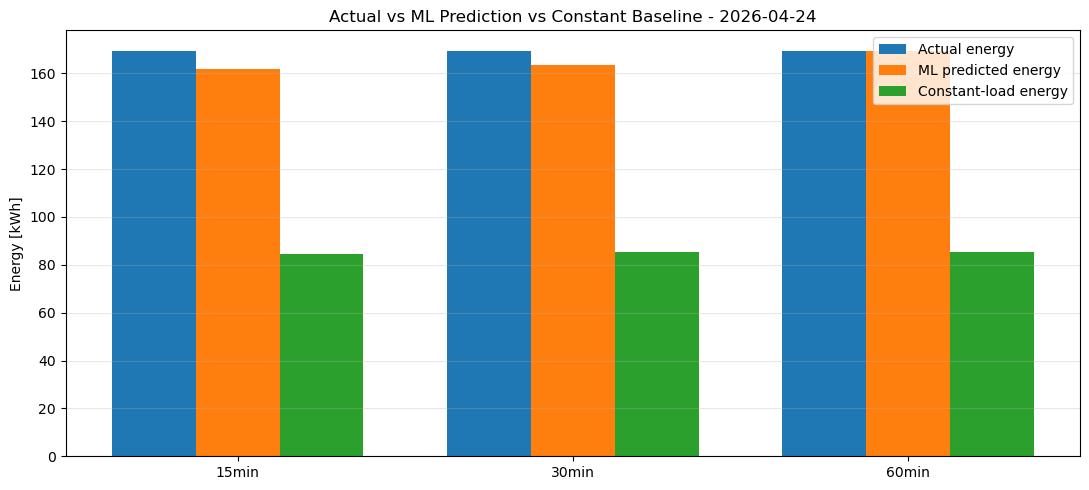

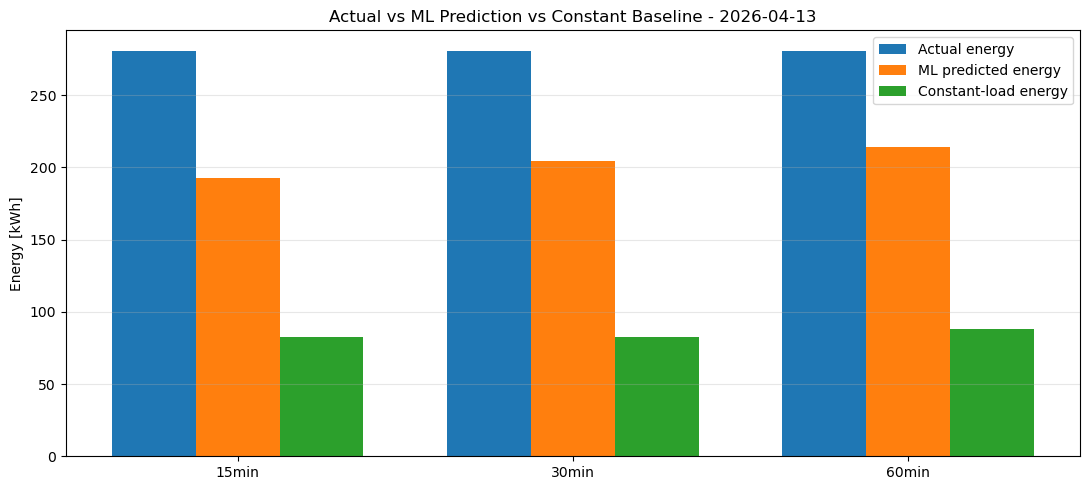

Saved results to: C:\Data_analysis\Thesis\outputs\profile_forecasting\energy_error_comparison


In [86]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# Energy error comparison:
# ML prediction vs constant-load baseline
# Constant baseline = last available actual sample at issue_time
# held constant for the whole next forecasted day/profile
# =========================================================

def resolution_to_hours(resolution: str) -> float:
    mapping = {
        "15min": 15 / 60,
        "30min": 30 / 60,
        "60min": 60 / 60,
        "1h": 1.0,
    }
    if resolution not in mapping:
        raise ValueError(f"Unknown resolution: {resolution}")
    return mapping[resolution]


def read_profile_prediction_csv(pred_path: Path) -> tuple[pd.DataFrame, list[str], list[str]]:
    df = pd.read_csv(pred_path)

    # First column is saved index / forecast issue timestamp
    first_col = df.columns[0]
    df[first_col] = pd.to_datetime(df[first_col], errors="coerce")

    df = df.dropna(subset=[first_col]).copy()
    df = df.rename(columns={first_col: "issue_time"})
    df = df.sort_values("issue_time").reset_index(drop=True)

    true_cols = sorted([c for c in df.columns if c.endswith("_true")])
    pred_cols = sorted([c for c in df.columns if c.endswith("_pred")])

    if len(true_cols) == 0:
        raise ValueError(f"No *_true columns found in {pred_path}")

    if len(pred_cols) == 0:
        raise ValueError(f"No *_pred columns found in {pred_path}")

    if len(true_cols) != len(pred_cols):
        raise ValueError(
            f"Mismatch in {pred_path}: {len(true_cols)} true cols vs {len(pred_cols)} pred cols"
        )

    return df, true_cols, pred_cols


def build_actual_lookup_from_profiles(df: pd.DataFrame, true_cols: list[str], dt_hours: float) -> pd.Series:
    """
    Reconstruct actual values from the profile prediction file.

    For each issue_time:
        y_tplus_001 belongs to issue_time + 1 step
        y_tplus_002 belongs to issue_time + 2 steps
        ...
    
    This allows us to find the actual load at the next forecast issue_time
    from the previous day's true profile.
    """
    rows = []

    step = pd.to_timedelta(dt_hours, unit="h")

    for _, row in df.iterrows():
        issue_time = row["issue_time"]

        for i, col in enumerate(true_cols, start=1):
            actual_time = issue_time + i * step
            rows.append({
                "actual_time": actual_time,
                "actual_load_kW": row[col],
            })

    actual_long = pd.DataFrame(rows)
    actual_long = actual_long.dropna(subset=["actual_time", "actual_load_kW"])

    # If duplicated timestamps exist, keep last occurrence
    actual_lookup = (
        actual_long
        .sort_values("actual_time")
        .drop_duplicates("actual_time", keep="last")
        .set_index("actual_time")["actual_load_kW"]
    )

    return actual_lookup


def daily_energy_ml_vs_constant(pred_path: Path, resolution: str) -> pd.DataFrame:
    dt_hours = resolution_to_hours(resolution)

    df, true_cols, pred_cols = read_profile_prediction_csv(pred_path)

    n_steps = len(true_cols)

    # Reconstruct actual load lookup from true profiles
    actual_lookup = build_actual_lookup_from_profiles(df, true_cols, dt_hours)

    rows = []

    for _, row in df.iterrows():
        issue_time = row["issue_time"]

        # Forecast profile belongs to the period after issue_time.
        # For your thesis explanation, use next calendar day as date label.
        forecast_date = (issue_time + pd.Timedelta(days=1)).date()

        actual_profile = row[true_cols].astype(float).values
        ml_profile = row[pred_cols].astype(float).values

        # Energy from profile
        actual_energy_kWh = np.nansum(actual_profile) * dt_hours
        ml_energy_kWh = np.nansum(ml_profile) * dt_hours

        # Constant baseline:
        # load at issue_time, held constant for all forecast horizon steps
        constant_load_kW = actual_lookup.get(issue_time, np.nan)
        constant_energy_kWh = constant_load_kW * n_steps * dt_hours if pd.notna(constant_load_kW) else np.nan

        rows.append({
            "date": forecast_date,
            "issue_time": issue_time,
            "resolution": resolution,
            "n_horizon_steps": n_steps,

            "actual_energy_kWh": actual_energy_kWh,

            "ml_predicted_energy_kWh": ml_energy_kWh,
            "constant_load_kW": constant_load_kW,
            "constant_energy_kWh": constant_energy_kWh,

            # User-requested residual definition: actual - prediction/input
            "ml_residual_energy_kWh": actual_energy_kWh - ml_energy_kWh,
            "constant_residual_energy_kWh": actual_energy_kWh - constant_energy_kWh,
        })

    out = pd.DataFrame(rows)

    out["ml_abs_energy_error_kWh"] = out["ml_residual_energy_kWh"].abs()
    out["constant_abs_energy_error_kWh"] = out["constant_residual_energy_kWh"].abs()

    out["ml_abs_energy_error_%"] = np.where(
        out["actual_energy_kWh"] != 0,
        out["ml_abs_energy_error_kWh"] / out["actual_energy_kWh"] * 100,
        np.nan,
    )

    out["constant_abs_energy_error_%"] = np.where(
        out["actual_energy_kWh"] != 0,
        out["constant_abs_energy_error_kWh"] / out["actual_energy_kWh"] * 100,
        np.nan,
    )

    # Positive value means ML is better than constant baseline
    out["ml_error_reduction_vs_constant_kWh"] = (
        out["constant_abs_energy_error_kWh"] - out["ml_abs_energy_error_kWh"]
    )

    out["ml_error_reduction_vs_constant_%"] = np.where(
        out["constant_abs_energy_error_kWh"] != 0,
        out["ml_error_reduction_vs_constant_kWh"] / out["constant_abs_energy_error_kWh"] * 100,
        np.nan,
    )

    return out


# =========================================================
# Run for all prediction files
# =========================================================

daily_tables = []

for resolution, path in prediction_files.items():
    daily_res = daily_energy_ml_vs_constant(path, resolution)
    daily_tables.append(daily_res)

daily_energy_comparison = pd.concat(daily_tables, ignore_index=True)

# Remove rows where constant baseline cannot be calculated.
# Usually the first test day may be NaN because the previous day's true profile
# is not present in the prediction CSV.
daily_energy_common = daily_energy_comparison.dropna(
    subset=["constant_energy_kWh"]
).copy()

print("All rows:", len(daily_energy_comparison))
print("Rows with valid constant baseline:", len(daily_energy_common))

display(daily_energy_common.head())


# =========================================================
# Find best and worst day based on ML absolute energy error
# =========================================================

day_score = (
    daily_energy_common
    .groupby("date")
    .agg(
        mean_ml_abs_error_kWh=("ml_abs_energy_error_kWh", "mean"),
        mean_constant_abs_error_kWh=("constant_abs_energy_error_kWh", "mean"),
        mean_ml_abs_error_percent=("ml_abs_energy_error_%", "mean"),
        mean_constant_abs_error_percent=("constant_abs_energy_error_%", "mean"),
        mean_ml_reduction_vs_constant_kWh=("ml_error_reduction_vs_constant_kWh", "mean"),
        mean_ml_reduction_vs_constant_percent=("ml_error_reduction_vs_constant_%", "mean"),
        n_resolutions=("resolution", "nunique"),
    )
    .reset_index()
)

best_day = day_score.sort_values("mean_ml_abs_error_kWh", ascending=True).iloc[0]["date"]
worst_day = day_score.sort_values("mean_ml_abs_error_kWh", ascending=False).iloc[0]["date"]

print("Best forecasted day based on ML energy error:", best_day)
print("Worst forecasted day based on ML energy error:", worst_day)

print("\nBest days:")
display(day_score.sort_values("mean_ml_abs_error_kWh").head(10))

print("\nWorst days:")
display(day_score.sort_values("mean_ml_abs_error_kWh", ascending=False).head(10))


# =========================================================
# Best and worst day detailed comparison
# =========================================================

best_worst_comparison = daily_energy_common[
    daily_energy_common["date"].isin([best_day, worst_day])
].copy()

best_worst_comparison["day_type"] = np.where(
    best_worst_comparison["date"] == best_day,
    "best_day",
    "worst_day",
)

best_worst_comparison = best_worst_comparison[
    [
        "day_type",
        "date",
        "issue_time",
        "resolution",
        "actual_energy_kWh",

        "ml_predicted_energy_kWh",
        "ml_residual_energy_kWh",
        "ml_abs_energy_error_kWh",
        "ml_abs_energy_error_%",

        "constant_load_kW",
        "constant_energy_kWh",
        "constant_residual_energy_kWh",
        "constant_abs_energy_error_kWh",
        "constant_abs_energy_error_%",

        "ml_error_reduction_vs_constant_kWh",
        "ml_error_reduction_vs_constant_%",
        "n_horizon_steps",
    ]
].sort_values(["day_type", "resolution"])

display(best_worst_comparison)


# =========================================================
# Thesis-friendly summary table
# =========================================================

summary_best_worst = (
    best_worst_comparison
    .groupby("day_type")
    .agg(
        date=("date", "first"),
        actual_energy_kWh=("actual_energy_kWh", "mean"),
        ml_predicted_energy_kWh=("ml_predicted_energy_kWh", "mean"),
        constant_energy_kWh=("constant_energy_kWh", "mean"),
        ml_abs_energy_error_kWh=("ml_abs_energy_error_kWh", "mean"),
        constant_abs_energy_error_kWh=("constant_abs_energy_error_kWh", "mean"),
        ml_abs_energy_error_percent=("ml_abs_energy_error_%", "mean"),
        constant_abs_energy_error_percent=("constant_abs_energy_error_%", "mean"),
        ml_error_reduction_vs_constant_kWh=("ml_error_reduction_vs_constant_kWh", "mean"),
        ml_error_reduction_vs_constant_percent=("ml_error_reduction_vs_constant_%", "mean"),
    )
    .reset_index()
)

display(summary_best_worst)


# =========================================================
# Overall comparison across all valid days
# =========================================================

overall_comparison = (
    daily_energy_common
    .groupby("resolution")
    .agg(
        n_days=("date", "nunique"),
        actual_energy_kWh=("actual_energy_kWh", "sum"),
        ml_predicted_energy_kWh=("ml_predicted_energy_kWh", "sum"),
        constant_energy_kWh=("constant_energy_kWh", "sum"),
        total_ml_abs_error_kWh=("ml_abs_energy_error_kWh", "sum"),
        total_constant_abs_error_kWh=("constant_abs_energy_error_kWh", "sum"),
        mean_ml_abs_error_kWh=("ml_abs_energy_error_kWh", "mean"),
        mean_constant_abs_error_kWh=("constant_abs_energy_error_kWh", "mean"),
        mean_ml_abs_error_percent=("ml_abs_energy_error_%", "mean"),
        mean_constant_abs_error_percent=("constant_abs_energy_error_%", "mean"),
        mean_ml_reduction_vs_constant_kWh=("ml_error_reduction_vs_constant_kWh", "mean"),
        mean_ml_reduction_vs_constant_percent=("ml_error_reduction_vs_constant_%", "mean"),
    )
    .reset_index()
)

display(overall_comparison)


# =========================================================
# Plot: Best and worst day energy comparison
# =========================================================

def plot_ml_vs_constant_for_day(daily_df, selected_day):
    plot_df = daily_df[daily_df["date"] == selected_day].copy()
    plot_df = plot_df.sort_values("resolution")

    x = np.arange(len(plot_df))
    width = 0.25

    plt.figure(figsize=(11, 5))

    plt.bar(x - width, plot_df["actual_energy_kWh"], width, label="Actual energy")
    plt.bar(x, plot_df["ml_predicted_energy_kWh"], width, label="ML predicted energy")
    plt.bar(x + width, plot_df["constant_energy_kWh"], width, label="Constant-load energy")

    plt.xticks(x, plot_df["resolution"])
    plt.ylabel("Energy [kWh]")
    plt.title(f"Actual vs ML Prediction vs Constant Baseline - {selected_day}")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_ml_vs_constant_for_day(daily_energy_common, best_day)
plot_ml_vs_constant_for_day(daily_energy_common, worst_day)


# =========================================================
# Optional: save results
# =========================================================

out_dir = Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\energy_error_comparison")
out_dir.mkdir(parents=True, exist_ok=True)

daily_energy_common.to_csv(out_dir / "daily_ml_vs_constant_energy_error.csv", index=False)
best_worst_comparison.to_csv(out_dir / "best_worst_ml_vs_constant_energy_error.csv", index=False)
overall_comparison.to_csv(out_dir / "overall_ml_vs_constant_energy_error.csv", index=False)

print("Saved results to:", out_dir)

# BU_TotActPwr_Tech_Room

In [87]:
# Change these paths to your actual saved prediction CSVs
prediction_files = {
    "15min": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_104832_8082fb66_ridge_BU_TotActPwr_Tech_Room_profile_predictions.csv"),
    "30min": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260527_102452_d1d61cc1_xgboost_BU_TotActPwr_Tech_Room_profile_predictions.csv"),
    "60min": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_111054_750e3408_xgboost_BU_TotActPwr_Tech_Room_profile_predictions.csv"),
}

target_col = "BU_TotActPwr_Tech_Room"  

In [88]:
from pathlib import Path
import pandas as pd
import numpy as np


def resolution_to_hours(resolution: str) -> float:
    mapping = {
        "15min": 15 / 60,
        "30min": 30 / 60,
        "60min": 60 / 60,
    }
    if resolution not in mapping:
        raise ValueError(f"Unknown resolution: {resolution}")
    return mapping[resolution]


def daily_energy_from_profile_predictions(pred_path: Path, resolution: str) -> pd.DataFrame:


    dt_hours = resolution_to_hours(resolution)

    df = pd.read_csv(pred_path)

    # First column is usually the saved index / issue timestamp
    first_col = df.columns[0]
    df[first_col] = pd.to_datetime(df[first_col], errors="coerce")

    df = df.dropna(subset=[first_col]).copy()
    df = df.rename(columns={first_col: "issue_time"})

    true_cols = sorted([c for c in df.columns if c.endswith("_true")])
    pred_cols = sorted([c for c in df.columns if c.endswith("_pred")])

    if not true_cols:
        raise ValueError(f"No *_true columns found in: {pred_path}")

    if not pred_cols:
        raise ValueError(f"No *_pred columns found in: {pred_path}")

    if len(true_cols) != len(pred_cols):
        raise ValueError(
            f"Different number of true and pred columns in {pred_path}: "
            f"{len(true_cols)} true vs {len(pred_cols)} pred"
        )

    rows = []

    for _, row in df.iterrows():
        issue_time = row["issue_time"]

        # Your forecast is issued at the end of the previous day.
        # So the predicted profile belongs to the next calendar day.
        forecast_date = (issue_time + pd.Timedelta(days=1)).date()

        actual_energy_kWh = row[true_cols].sum() * dt_hours
        predicted_energy_kWh = row[pred_cols].sum() * dt_hours

        rows.append({
            "date": forecast_date,
            "issue_time": issue_time,
            "resolution": resolution,
            "actual_energy_kWh": actual_energy_kWh,
            "predicted_energy_kWh": predicted_energy_kWh,
            "n_horizon_steps": len(true_cols),
        })

    daily = pd.DataFrame(rows)

    daily["energy_error_kWh"] = (
        daily["predicted_energy_kWh"] - daily["actual_energy_kWh"]
    )

    daily["abs_energy_error_kWh"] = daily["energy_error_kWh"].abs()

    daily["energy_error_percent"] = np.where(
        daily["actual_energy_kWh"] != 0,
        daily["energy_error_kWh"] / daily["actual_energy_kWh"] * 100,
        np.nan,
    )

    daily["abs_energy_error_percent"] = daily["energy_error_percent"].abs()

    return daily

In [89]:
daily_tables = []

for resolution, path in prediction_files.items():
    daily_res = daily_energy_from_profile_predictions(path, resolution)
    daily_tables.append(daily_res)

daily_energy_all = pd.concat(daily_tables, ignore_index=True)

display(daily_energy_all.head())

,date,issue_time,resolution,actual_energy_kWh,predicted_energy_kWh,n_horizon_steps,energy_error_kWh,abs_energy_error_kWh,energy_error_percent,abs_energy_error_percent
0,2026-04-12,2026-04-11 23:45:00,15min,67.117837,66.723143,96,-0.394695,0.394695,-0.588062,0.588062
1,2026-04-13,2026-04-12 23:45:00,15min,61.671665,60.071469,96,-1.600196,1.600196,-2.594702,2.594702
2,2026-04-14,2026-04-13 23:45:00,15min,61.619583,57.170061,96,-4.449522,4.449522,-7.220954,7.220954
3,2026-04-15,2026-04-14 23:45:00,15min,62.490455,56.292684,96,-6.197771,6.197771,-9.917949,9.917949
4,2026-04-16,2026-04-15 23:45:00,15min,61.655327,58.004916,96,-3.650411,3.650411,-5.920675,5.920675


In [90]:
required_resolutions = set(prediction_files.keys())

date_counts = (
    daily_energy_all
    .groupby("date")["resolution"]
    .nunique()
)

common_dates = date_counts[date_counts == len(required_resolutions)].index

daily_energy_common = daily_energy_all[
    daily_energy_all["date"].isin(common_dates)
].copy()

print("Common comparison days:", len(common_dates))
display(daily_energy_common.head())

Common comparison days: 9


,date,issue_time,resolution,actual_energy_kWh,predicted_energy_kWh,n_horizon_steps,energy_error_kWh,abs_energy_error_kWh,energy_error_percent,abs_energy_error_percent
10,2026-04-22,2026-04-21 23:45:00,15min,59.293707,52.305145,96,-6.988562,6.988562,-11.786347,11.786347
11,2026-04-23,2026-04-22 23:45:00,15min,57.267080,50.914126,96,-6.352954,6.352954,-11.093553,11.093553
12,2026-04-24,2026-04-23 23:45:00,15min,59.666010,52.849475,96,-6.816535,6.816535,-11.424486,11.424486
13,2026-04-25,2026-04-24 23:45:00,15min,56.736013,53.267375,96,-3.468638,3.468638,-6.113644,6.113644
14,2026-04-26,2026-04-25 23:45:00,15min,57.702173,54.151042,96,-3.551131,3.551131,-6.154241,6.154241


In [91]:
day_score = (
    daily_energy_common
    .groupby("date")
    .agg(
        mean_abs_energy_error_kWh=("abs_energy_error_kWh", "mean"),
        max_abs_energy_error_kWh=("abs_energy_error_kWh", "max"),
        mean_abs_energy_error_percent=("abs_energy_error_percent", "mean"),
    )
    .reset_index()
)

best_day = day_score.sort_values("mean_abs_energy_error_kWh", ascending=True).iloc[0]["date"]
worst_day = day_score.sort_values("mean_abs_energy_error_kWh", ascending=False).iloc[0]["date"]

print("Best forecasted day:", best_day)
print("Worst forecasted day:", worst_day)

display(day_score.sort_values("mean_abs_energy_error_kWh").head(10))
display(day_score.sort_values("mean_abs_energy_error_kWh", ascending=False).head(10))

Best forecasted day: 2026-04-28
Worst forecasted day: 2026-04-24


,date,mean_abs_energy_error_kWh,max_abs_energy_error_kWh,mean_abs_energy_error_percent
6,2026-04-28,1.970609,4.312389,3.480755
3,2026-04-25,2.267237,3.468638,3.996117
4,2026-04-26,2.296732,3.551131,3.980322
7,2026-04-29,2.885110,4.508499,5.017989
1,2026-04-23,3.558650,6.352954,6.214129
5,2026-04-27,4.022088,5.909740,6.840244
0,2026-04-22,4.777270,6.988562,8.057268
8,2026-04-30,4.824169,7.345538,8.141884
2,2026-04-24,5.548791,6.816535,9.299753


,date,mean_abs_energy_error_kWh,max_abs_energy_error_kWh,mean_abs_energy_error_percent
2,2026-04-24,5.548791,6.816535,9.299753
8,2026-04-30,4.824169,7.345538,8.141884
0,2026-04-22,4.777270,6.988562,8.057268
5,2026-04-27,4.022088,5.909740,6.840244
1,2026-04-23,3.558650,6.352954,6.214129
7,2026-04-29,2.885110,4.508499,5.017989
4,2026-04-26,2.296732,3.551131,3.980322
3,2026-04-25,2.267237,3.468638,3.996117
6,2026-04-28,1.970609,4.312389,3.480755


In [92]:
best_worst_comparison = daily_energy_common[
    daily_energy_common["date"].isin([best_day, worst_day])
].copy()

best_worst_comparison["day_type"] = np.where(
    best_worst_comparison["date"] == best_day,
    "best_day",
    "worst_day",
)

best_worst_comparison = best_worst_comparison[
    [
        "day_type",
        "date",
        "resolution",
        "actual_energy_kWh",
        "predicted_energy_kWh",
        "energy_error_kWh",
        "abs_energy_error_kWh",
        "energy_error_percent",
        "abs_energy_error_percent",
        "n_horizon_steps",
    ]
].sort_values(["day_type", "resolution"])

display(best_worst_comparison)

,day_type,date,resolution,actual_energy_kWh,predicted_energy_kWh,energy_error_kWh,abs_energy_error_kWh,energy_error_percent,abs_energy_error_percent,n_horizon_steps
16,best_day,2026-04-28,15min,56.614423,52.302034,-4.312389,4.312389,-7.617120,7.617120,96
25,best_day,2026-04-28,30min,56.614410,55.488454,-1.125956,1.125956,-1.988816,1.988816,48
44,best_day,2026-04-28,60min,56.614420,56.140936,-0.473484,0.473484,-0.836330,0.836330,24
12,worst_day,2026-04-24,15min,59.666010,52.849475,-6.816535,6.816535,-11.424486,11.424486,96
21,worst_day,2026-04-24,30min,59.666010,54.823223,-4.842787,4.842787,-8.116492,8.116492,48
40,worst_day,2026-04-24,60min,59.665970,54.678920,-4.987050,4.987050,-8.358282,8.358282,24


In [93]:
total_energy_comparison = (
    daily_energy_common
    .groupby("resolution")
    .agg(
        actual_energy_kWh=("actual_energy_kWh", "sum"),
        predicted_energy_kWh=("predicted_energy_kWh", "sum"),
        total_abs_daily_error_kWh=("abs_energy_error_kWh", "sum"),
        mean_daily_abs_error_kWh=("abs_energy_error_kWh", "mean"),
        mean_daily_abs_error_percent=("abs_energy_error_percent", "mean"),
        n_days=("date", "nunique"),
    )
    .reset_index()
)

total_energy_comparison["total_energy_error_kWh"] = (
    total_energy_comparison["predicted_energy_kWh"]
    - total_energy_comparison["actual_energy_kWh"]
)

total_energy_comparison["total_energy_error_percent"] = np.where(
    total_energy_comparison["actual_energy_kWh"] != 0,
    total_energy_comparison["total_energy_error_kWh"]
    / total_energy_comparison["actual_energy_kWh"] * 100,
    np.nan,
)

display(total_energy_comparison.sort_values("mean_daily_abs_error_kWh"))

,resolution,actual_energy_kWh,predicted_energy_kWh,total_abs_daily_error_kWh,mean_daily_abs_error_kWh,mean_daily_abs_error_percent,n_days,total_energy_error_kWh,total_energy_error_percent
2,60min,522.662900,500.493728,22.169172,2.463241,4.194120,9,-22.169172,-4.241581
1,30min,522.720820,497.692008,25.028812,2.780979,4.764988,9,-25.028812,-4.788180
0,15min,522.956089,473.702104,49.253985,5.472665,9.383713,9,-49.253985,-9.418379


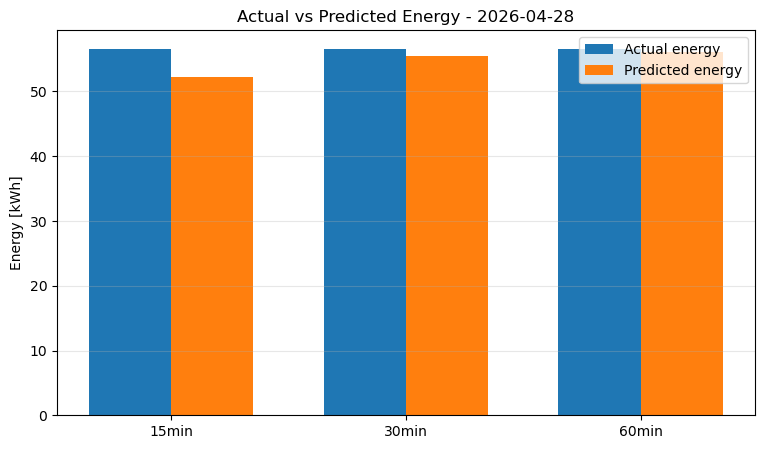

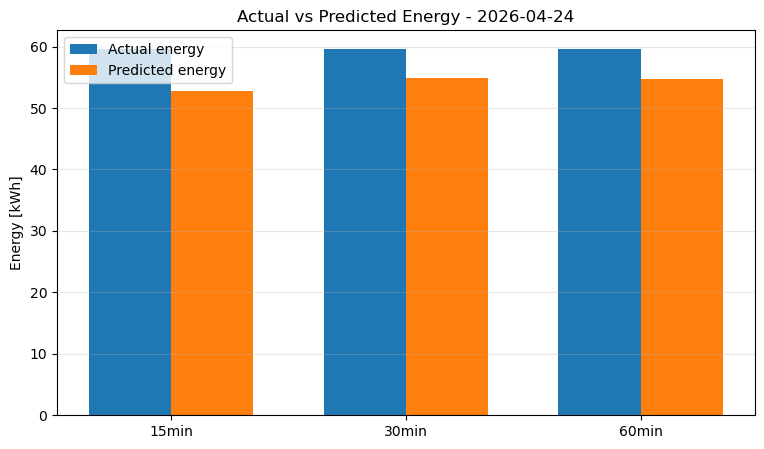

In [94]:
import matplotlib.pyplot as plt

def plot_energy_comparison_for_day(daily_df, selected_day):
    plot_df = daily_df[daily_df["date"] == selected_day].copy()
    plot_df = plot_df.sort_values("resolution")

    x = np.arange(len(plot_df))
    width = 0.35

    plt.figure(figsize=(9, 5))
    plt.bar(x - width/2, plot_df["actual_energy_kWh"], width, label="Actual energy")
    plt.bar(x + width/2, plot_df["predicted_energy_kWh"], width, label="Predicted energy")

    plt.xticks(x, plot_df["resolution"])
    plt.ylabel("Energy [kWh]")
    plt.title(f"Actual vs Predicted Energy - {selected_day}")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.show()


plot_energy_comparison_for_day(daily_energy_common, best_day)
plot_energy_comparison_for_day(daily_energy_common, worst_day)

All rows: 47
Rows with valid constant baseline: 44


,date,issue_time,resolution,n_horizon_steps,actual_energy_kWh,ml_predicted_energy_kWh,constant_load_kW,constant_energy_kWh,ml_residual_energy_kWh,constant_residual_energy_kWh,ml_abs_energy_error_kWh,constant_abs_energy_error_kWh,ml_abs_energy_error_%,constant_abs_energy_error_%,ml_error_reduction_vs_constant_kWh,ml_error_reduction_vs_constant_%
1,2026-04-13,2026-04-12 23:45:00,15min,96,61.671665,60.071469,4.01533,96.36792,1.600196,-34.696255,1.600196,34.696255,2.594702,56.259637,33.096059,95.387987
2,2026-04-14,2026-04-13 23:45:00,15min,96,61.619582,57.170061,3.96800,95.23200,4.449522,-33.612418,4.449522,33.612418,7.220954,54.548272,29.162896,86.762268
3,2026-04-15,2026-04-14 23:45:00,15min,96,62.490455,56.292684,3.93733,94.49592,6.197771,-32.005465,6.197771,32.005465,9.917949,51.216566,25.807694,80.635271
4,2026-04-16,2026-04-15 23:45:00,15min,96,61.655327,58.004916,4.02567,96.61608,3.650411,-34.960752,3.650411,34.960752,5.920675,56.703539,31.310341,89.558545
5,2026-04-17,2026-04-16 23:45:00,15min,96,59.305325,55.241326,3.86667,92.80008,4.063999,-33.494755,4.063999,33.494755,6.852671,56.478495,29.430756,87.866761


Best forecasted day based on ML energy error: 2026-04-20
Worst forecasted day based on ML energy error: 2026-04-21

Best days:


,date,mean_ml_abs_error_kWh,mean_constant_abs_error_kWh,mean_ml_abs_error_percent,mean_constant_abs_error_percent,mean_ml_reduction_vs_constant_kWh,mean_ml_reduction_vs_constant_percent,n_resolutions
7,2026-04-20,0.685815,36.265926,1.232372,65.167889,35.580112,98.108723,2
0,2026-04-13,1.602927,34.717242,2.599129,56.293657,33.114316,95.382913,2
15,2026-04-28,1.970609,31.372223,3.480755,55.413840,29.401613,93.692756,3
6,2026-04-19,2.102196,34.561451,3.651700,60.036302,32.459255,93.909883,2
12,2026-04-25,2.267237,34.790639,3.996117,61.320218,32.523402,93.487606,3
13,2026-04-26,2.296732,34.410474,3.980322,59.634632,32.113742,93.325315,3
5,2026-04-18,2.764042,34.583503,4.725060,59.119627,31.819460,91.986024,2
16,2026-04-29,2.885110,33.423385,5.017989,58.132342,30.538275,91.361058,3
4,2026-04-17,3.442268,34.061743,5.804314,57.434531,30.619474,89.860841,2
10,2026-04-23,3.558650,31.836918,6.214129,55.593750,28.278268,88.722247,3



Worst days:


,date,mean_ml_abs_error_kWh,mean_constant_abs_error_kWh,mean_ml_abs_error_percent,mean_constant_abs_error_percent,mean_ml_reduction_vs_constant_kWh,mean_ml_reduction_vs_constant_percent,n_resolutions
8,2026-04-21,7.181245,29.122355,11.985582,48.630683,21.941110,75.322156,2
2,2026-04-15,5.629330,31.935658,9.007547,51.100086,26.306327,82.376707,2
11,2026-04-24,5.548791,29.829363,9.299753,49.993908,24.280573,81.337316,3
9,2026-04-22,5.207343,31.502966,8.783525,53.141714,26.295624,83.496377,2
17,2026-04-30,4.824169,29.512780,8.141884,49.836958,24.688611,83.576182,3
1,2026-04-14,4.250434,33.662444,6.897862,54.629445,29.412009,87.372457,2
14,2026-04-27,4.022088,31.134157,6.840244,52.960182,27.112069,86.947529,3
3,2026-04-16,3.785384,34.824676,6.139590,56.482837,31.039292,89.128488,2
10,2026-04-23,3.558650,31.836918,6.214129,55.593750,28.278268,88.722247,3
4,2026-04-17,3.442268,34.061743,5.804314,57.434531,30.619474,89.860841,2


,day_type,date,issue_time,resolution,actual_energy_kWh,ml_predicted_energy_kWh,ml_residual_energy_kWh,ml_abs_energy_error_kWh,ml_abs_energy_error_%,constant_load_kW,constant_energy_kWh,constant_residual_energy_kWh,constant_abs_energy_error_kWh,constant_abs_energy_error_%,ml_error_reduction_vs_constant_kWh,ml_error_reduction_vs_constant_%,n_horizon_steps
8,best_day,2026-04-20,2026-04-19 23:45:00,15min,55.649997,55.189247,0.460751,0.460751,0.827944,3.83033,91.92792,-36.277923,36.277923,65.189441,35.817172,98.729942,96
36,best_day,2026-04-20,2026-04-19 23:00:00,60min,55.649990,56.560869,-0.910879,0.910879,1.636800,3.82933,91.90392,-36.253930,36.253930,65.146337,35.343051,97.487503,24
9,worst_day,2026-04-21,2026-04-20 23:45:00,15min,60.030410,51.340460,8.689950,8.689950,14.475913,3.71033,89.04792,-29.017510,29.017510,48.338017,20.327560,70.052737,96
37,worst_day,2026-04-21,2026-04-20 23:00:00,60min,59.740800,54.068261,5.672539,5.672539,9.495252,3.70700,88.96800,-29.227200,29.227200,48.923349,23.554661,80.591575,24


,day_type,date,actual_energy_kWh,ml_predicted_energy_kWh,constant_energy_kWh,ml_abs_energy_error_kWh,constant_abs_energy_error_kWh,ml_abs_energy_error_percent,constant_abs_energy_error_percent,ml_error_reduction_vs_constant_kWh,ml_error_reduction_vs_constant_percent
0,best_day,2026-04-20,55.649994,55.875058,91.91592,0.685815,36.265926,1.232372,65.167889,35.580112,98.108723
1,worst_day,2026-04-21,59.885605,52.704360,89.00796,7.181245,29.122355,11.985582,48.630683,21.941110,75.322156


,resolution,n_days,actual_energy_kWh,ml_predicted_energy_kWh,constant_energy_kWh,total_ml_abs_error_kWh,total_constant_abs_error_kWh,mean_ml_abs_error_kWh,mean_constant_abs_error_kWh,mean_ml_abs_error_percent,mean_constant_abs_error_percent,mean_ml_reduction_vs_constant_kWh,mean_ml_reduction_vs_constant_percent
0,15min,18,1061.443964,976.875909,1648.30368,84.568055,586.859716,4.698225,32.603318,7.941049,55.368735,27.905092,85.114961
1,30min,8,463.413180,442.301492,720.40800,21.111688,256.994820,2.638961,32.124353,4.535017,55.512330,29.485392,91.713847
2,60min,18,1060.872870,1012.952245,1656.42408,49.742383,595.551210,2.763466,33.086178,4.630440,56.221953,30.322713,91.414394


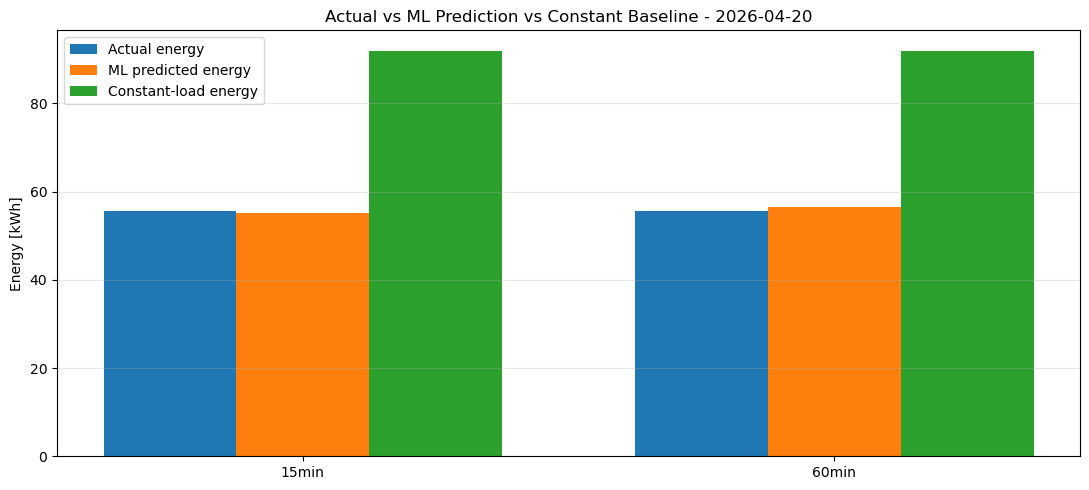

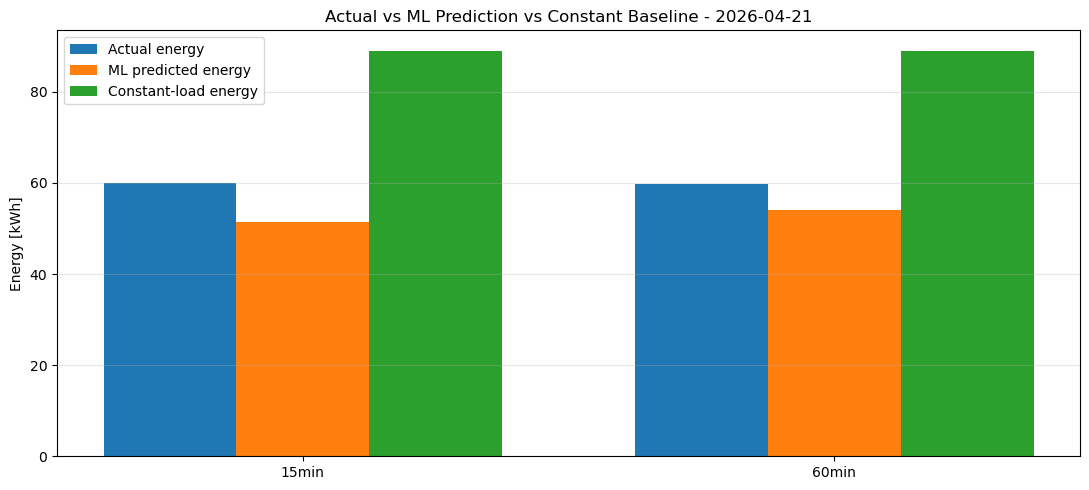

Saved results to: C:\Data_analysis\Thesis\outputs\profile_forecasting\energy_error_comparison


In [95]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# Energy error comparison:
# ML prediction vs constant-load baseline
# Constant baseline = last available actual sample at issue_time
# held constant for the whole next forecasted day/profile
# =========================================================

def resolution_to_hours(resolution: str) -> float:
    mapping = {
        "15min": 15 / 60,
        "30min": 30 / 60,
        "60min": 60 / 60,
        "1h": 1.0,
    }
    if resolution not in mapping:
        raise ValueError(f"Unknown resolution: {resolution}")
    return mapping[resolution]


def read_profile_prediction_csv(pred_path: Path) -> tuple[pd.DataFrame, list[str], list[str]]:
    df = pd.read_csv(pred_path)

    # First column is saved index / forecast issue timestamp
    first_col = df.columns[0]
    df[first_col] = pd.to_datetime(df[first_col], errors="coerce")

    df = df.dropna(subset=[first_col]).copy()
    df = df.rename(columns={first_col: "issue_time"})
    df = df.sort_values("issue_time").reset_index(drop=True)

    true_cols = sorted([c for c in df.columns if c.endswith("_true")])
    pred_cols = sorted([c for c in df.columns if c.endswith("_pred")])

    if len(true_cols) == 0:
        raise ValueError(f"No *_true columns found in {pred_path}")

    if len(pred_cols) == 0:
        raise ValueError(f"No *_pred columns found in {pred_path}")

    if len(true_cols) != len(pred_cols):
        raise ValueError(
            f"Mismatch in {pred_path}: {len(true_cols)} true cols vs {len(pred_cols)} pred cols"
        )

    return df, true_cols, pred_cols


def build_actual_lookup_from_profiles(df: pd.DataFrame, true_cols: list[str], dt_hours: float) -> pd.Series:
    """
    Reconstruct actual values from the profile prediction file.

    For each issue_time:
        y_tplus_001 belongs to issue_time + 1 step
        y_tplus_002 belongs to issue_time + 2 steps
        ...
    
    This allows us to find the actual load at the next forecast issue_time
    from the previous day's true profile.
    """
    rows = []

    step = pd.to_timedelta(dt_hours, unit="h")

    for _, row in df.iterrows():
        issue_time = row["issue_time"]

        for i, col in enumerate(true_cols, start=1):
            actual_time = issue_time + i * step
            rows.append({
                "actual_time": actual_time,
                "actual_load_kW": row[col],
            })

    actual_long = pd.DataFrame(rows)
    actual_long = actual_long.dropna(subset=["actual_time", "actual_load_kW"])

    # If duplicated timestamps exist, keep last occurrence
    actual_lookup = (
        actual_long
        .sort_values("actual_time")
        .drop_duplicates("actual_time", keep="last")
        .set_index("actual_time")["actual_load_kW"]
    )

    return actual_lookup


def daily_energy_ml_vs_constant(pred_path: Path, resolution: str) -> pd.DataFrame:
    dt_hours = resolution_to_hours(resolution)

    df, true_cols, pred_cols = read_profile_prediction_csv(pred_path)

    n_steps = len(true_cols)

    # Reconstruct actual load lookup from true profiles
    actual_lookup = build_actual_lookup_from_profiles(df, true_cols, dt_hours)

    rows = []

    for _, row in df.iterrows():
        issue_time = row["issue_time"]

        # Forecast profile belongs to the period after issue_time.
        # For your thesis explanation, use next calendar day as date label.
        forecast_date = (issue_time + pd.Timedelta(days=1)).date()

        actual_profile = row[true_cols].astype(float).values
        ml_profile = row[pred_cols].astype(float).values

        # Energy from profile
        actual_energy_kWh = np.nansum(actual_profile) * dt_hours
        ml_energy_kWh = np.nansum(ml_profile) * dt_hours

        # Constant baseline:
        # load at issue_time, held constant for all forecast horizon steps
        constant_load_kW = actual_lookup.get(issue_time, np.nan)
        constant_energy_kWh = constant_load_kW * n_steps * dt_hours if pd.notna(constant_load_kW) else np.nan

        rows.append({
            "date": forecast_date,
            "issue_time": issue_time,
            "resolution": resolution,
            "n_horizon_steps": n_steps,

            "actual_energy_kWh": actual_energy_kWh,

            "ml_predicted_energy_kWh": ml_energy_kWh,
            "constant_load_kW": constant_load_kW,
            "constant_energy_kWh": constant_energy_kWh,

            # User-requested residual definition: actual - prediction/input
            "ml_residual_energy_kWh": actual_energy_kWh - ml_energy_kWh,
            "constant_residual_energy_kWh": actual_energy_kWh - constant_energy_kWh,
        })

    out = pd.DataFrame(rows)

    out["ml_abs_energy_error_kWh"] = out["ml_residual_energy_kWh"].abs()
    out["constant_abs_energy_error_kWh"] = out["constant_residual_energy_kWh"].abs()

    out["ml_abs_energy_error_%"] = np.where(
        out["actual_energy_kWh"] != 0,
        out["ml_abs_energy_error_kWh"] / out["actual_energy_kWh"] * 100,
        np.nan,
    )

    out["constant_abs_energy_error_%"] = np.where(
        out["actual_energy_kWh"] != 0,
        out["constant_abs_energy_error_kWh"] / out["actual_energy_kWh"] * 100,
        np.nan,
    )

    # Positive value means ML is better than constant baseline
    out["ml_error_reduction_vs_constant_kWh"] = (
        out["constant_abs_energy_error_kWh"] - out["ml_abs_energy_error_kWh"]
    )

    out["ml_error_reduction_vs_constant_%"] = np.where(
        out["constant_abs_energy_error_kWh"] != 0,
        out["ml_error_reduction_vs_constant_kWh"] / out["constant_abs_energy_error_kWh"] * 100,
        np.nan,
    )

    return out


# =========================================================
# Run for all prediction files
# =========================================================

daily_tables = []

for resolution, path in prediction_files.items():
    daily_res = daily_energy_ml_vs_constant(path, resolution)
    daily_tables.append(daily_res)

daily_energy_comparison = pd.concat(daily_tables, ignore_index=True)

# Remove rows where constant baseline cannot be calculated.
# Usually the first test day may be NaN because the previous day's true profile
# is not present in the prediction CSV.
daily_energy_common = daily_energy_comparison.dropna(
    subset=["constant_energy_kWh"]
).copy()

print("All rows:", len(daily_energy_comparison))
print("Rows with valid constant baseline:", len(daily_energy_common))

display(daily_energy_common.head())


# =========================================================
# Find best and worst day based on ML absolute energy error
# =========================================================

day_score = (
    daily_energy_common
    .groupby("date")
    .agg(
        mean_ml_abs_error_kWh=("ml_abs_energy_error_kWh", "mean"),
        mean_constant_abs_error_kWh=("constant_abs_energy_error_kWh", "mean"),
        mean_ml_abs_error_percent=("ml_abs_energy_error_%", "mean"),
        mean_constant_abs_error_percent=("constant_abs_energy_error_%", "mean"),
        mean_ml_reduction_vs_constant_kWh=("ml_error_reduction_vs_constant_kWh", "mean"),
        mean_ml_reduction_vs_constant_percent=("ml_error_reduction_vs_constant_%", "mean"),
        n_resolutions=("resolution", "nunique"),
    )
    .reset_index()
)

best_day = day_score.sort_values("mean_ml_abs_error_kWh", ascending=True).iloc[0]["date"]
worst_day = day_score.sort_values("mean_ml_abs_error_kWh", ascending=False).iloc[0]["date"]

print("Best forecasted day based on ML energy error:", best_day)
print("Worst forecasted day based on ML energy error:", worst_day)

print("\nBest days:")
display(day_score.sort_values("mean_ml_abs_error_kWh").head(10))

print("\nWorst days:")
display(day_score.sort_values("mean_ml_abs_error_kWh", ascending=False).head(10))


# =========================================================
# Best and worst day detailed comparison
# =========================================================

best_worst_comparison = daily_energy_common[
    daily_energy_common["date"].isin([best_day, worst_day])
].copy()

best_worst_comparison["day_type"] = np.where(
    best_worst_comparison["date"] == best_day,
    "best_day",
    "worst_day",
)

best_worst_comparison = best_worst_comparison[
    [
        "day_type",
        "date",
        "issue_time",
        "resolution",
        "actual_energy_kWh",

        "ml_predicted_energy_kWh",
        "ml_residual_energy_kWh",
        "ml_abs_energy_error_kWh",
        "ml_abs_energy_error_%",

        "constant_load_kW",
        "constant_energy_kWh",
        "constant_residual_energy_kWh",
        "constant_abs_energy_error_kWh",
        "constant_abs_energy_error_%",

        "ml_error_reduction_vs_constant_kWh",
        "ml_error_reduction_vs_constant_%",
        "n_horizon_steps",
    ]
].sort_values(["day_type", "resolution"])

display(best_worst_comparison)


# =========================================================
# Thesis-friendly summary table
# =========================================================

summary_best_worst = (
    best_worst_comparison
    .groupby("day_type")
    .agg(
        date=("date", "first"),
        actual_energy_kWh=("actual_energy_kWh", "mean"),
        ml_predicted_energy_kWh=("ml_predicted_energy_kWh", "mean"),
        constant_energy_kWh=("constant_energy_kWh", "mean"),
        ml_abs_energy_error_kWh=("ml_abs_energy_error_kWh", "mean"),
        constant_abs_energy_error_kWh=("constant_abs_energy_error_kWh", "mean"),
        ml_abs_energy_error_percent=("ml_abs_energy_error_%", "mean"),
        constant_abs_energy_error_percent=("constant_abs_energy_error_%", "mean"),
        ml_error_reduction_vs_constant_kWh=("ml_error_reduction_vs_constant_kWh", "mean"),
        ml_error_reduction_vs_constant_percent=("ml_error_reduction_vs_constant_%", "mean"),
    )
    .reset_index()
)

display(summary_best_worst)


# =========================================================
# Overall comparison across all valid days
# =========================================================

overall_comparison = (
    daily_energy_common
    .groupby("resolution")
    .agg(
        n_days=("date", "nunique"),
        actual_energy_kWh=("actual_energy_kWh", "sum"),
        ml_predicted_energy_kWh=("ml_predicted_energy_kWh", "sum"),
        constant_energy_kWh=("constant_energy_kWh", "sum"),
        total_ml_abs_error_kWh=("ml_abs_energy_error_kWh", "sum"),
        total_constant_abs_error_kWh=("constant_abs_energy_error_kWh", "sum"),
        mean_ml_abs_error_kWh=("ml_abs_energy_error_kWh", "mean"),
        mean_constant_abs_error_kWh=("constant_abs_energy_error_kWh", "mean"),
        mean_ml_abs_error_percent=("ml_abs_energy_error_%", "mean"),
        mean_constant_abs_error_percent=("constant_abs_energy_error_%", "mean"),
        mean_ml_reduction_vs_constant_kWh=("ml_error_reduction_vs_constant_kWh", "mean"),
        mean_ml_reduction_vs_constant_percent=("ml_error_reduction_vs_constant_%", "mean"),
    )
    .reset_index()
)

display(overall_comparison)


# =========================================================
# Plot: Best and worst day energy comparison
# =========================================================

def plot_ml_vs_constant_for_day(daily_df, selected_day):
    plot_df = daily_df[daily_df["date"] == selected_day].copy()
    plot_df = plot_df.sort_values("resolution")

    x = np.arange(len(plot_df))
    width = 0.25

    plt.figure(figsize=(11, 5))

    plt.bar(x - width, plot_df["actual_energy_kWh"], width, label="Actual energy")
    plt.bar(x, plot_df["ml_predicted_energy_kWh"], width, label="ML predicted energy")
    plt.bar(x + width, plot_df["constant_energy_kWh"], width, label="Constant-load energy")

    plt.xticks(x, plot_df["resolution"])
    plt.ylabel("Energy [kWh]")
    plt.title(f"Actual vs ML Prediction vs Constant Baseline - {selected_day}")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_ml_vs_constant_for_day(daily_energy_common, best_day)
plot_ml_vs_constant_for_day(daily_energy_common, worst_day)


# =========================================================
# Optional: save results
# =========================================================

out_dir = Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\energy_error_comparison")
out_dir.mkdir(parents=True, exist_ok=True)

daily_energy_common.to_csv(out_dir / "daily_ml_vs_constant_energy_error.csv", index=False)
best_worst_comparison.to_csv(out_dir / "best_worst_ml_vs_constant_energy_error.csv", index=False)
overall_comparison.to_csv(out_dir / "overall_ml_vs_constant_energy_error.csv", index=False)

print("Saved results to:", out_dir)

# BU_TotActPwr_SDB_EL_Substation

In [109]:
# Change these paths to your actual saved prediction CSVs
prediction_files = {
    "15min": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260528_115442_63c0a563_random_forest_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv"),
    "30min": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260527_092954_174e032d_random_forest_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv"),
    "60min": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260527_083211_c3cb7819_ridge_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv"),
}

target_col = "BU_TotActPwr_SDB_EL_Substation_profile_predictions"  

In [110]:
from pathlib import Path
import pandas as pd
import numpy as np


def resolution_to_hours(resolution: str) -> float:
    mapping = {
        "15min": 15 / 60,
        "30min": 30 / 60,
        "60min": 60 / 60,
    }
    if resolution not in mapping:
        raise ValueError(f"Unknown resolution: {resolution}")
    return mapping[resolution]


def daily_energy_from_profile_predictions(pred_path: Path, resolution: str) -> pd.DataFrame:


    dt_hours = resolution_to_hours(resolution)

    df = pd.read_csv(pred_path)

    # First column is usually the saved index / issue timestamp
    first_col = df.columns[0]
    df[first_col] = pd.to_datetime(df[first_col], errors="coerce")

    df = df.dropna(subset=[first_col]).copy()
    df = df.rename(columns={first_col: "issue_time"})

    true_cols = sorted([c for c in df.columns if c.endswith("_true")])
    pred_cols = sorted([c for c in df.columns if c.endswith("_pred")])

    if not true_cols:
        raise ValueError(f"No *_true columns found in: {pred_path}")

    if not pred_cols:
        raise ValueError(f"No *_pred columns found in: {pred_path}")

    if len(true_cols) != len(pred_cols):
        raise ValueError(
            f"Different number of true and pred columns in {pred_path}: "
            f"{len(true_cols)} true vs {len(pred_cols)} pred"
        )

    rows = []

    for _, row in df.iterrows():
        issue_time = row["issue_time"]

        # Your forecast is issued at the end of the previous day.
        # So the predicted profile belongs to the next calendar day.
        forecast_date = (issue_time + pd.Timedelta(days=1)).date()

        actual_energy_kWh = row[true_cols].sum() * dt_hours
        predicted_energy_kWh = row[pred_cols].sum() * dt_hours

        rows.append({
            "date": forecast_date,
            "issue_time": issue_time,
            "resolution": resolution,
            "actual_energy_kWh": actual_energy_kWh,
            "predicted_energy_kWh": predicted_energy_kWh,
            "n_horizon_steps": len(true_cols),
        })

    daily = pd.DataFrame(rows)

    daily["energy_error_kWh"] = (
        daily["predicted_energy_kWh"] - daily["actual_energy_kWh"]
    )

    daily["abs_energy_error_kWh"] = daily["energy_error_kWh"].abs()

    daily["energy_error_percent"] = np.where(
        daily["actual_energy_kWh"] != 0,
        daily["energy_error_kWh"] / daily["actual_energy_kWh"] * 100,
        np.nan,
    )

    daily["abs_energy_error_percent"] = daily["energy_error_percent"].abs()

    return daily

In [111]:
daily_tables = []

for resolution, path in prediction_files.items():
    daily_res = daily_energy_from_profile_predictions(path, resolution)
    daily_tables.append(daily_res)

daily_energy_all = pd.concat(daily_tables, ignore_index=True)

display(daily_energy_all.head())

,date,issue_time,resolution,actual_energy_kWh,predicted_energy_kWh,n_horizon_steps,energy_error_kWh,abs_energy_error_kWh,energy_error_percent,abs_energy_error_percent
0,2026-04-21,2026-04-20 23:45:00,15min,83.772248,80.789117,96,-2.983130,2.983130,-3.561000,3.561000
1,2026-04-22,2026-04-21 23:45:00,15min,73.333091,81.286804,96,7.953713,7.953713,10.846008,10.846008
2,2026-04-23,2026-04-22 23:45:00,15min,78.713250,78.841121,96,0.127871,0.127871,0.162452,0.162452
3,2026-04-24,2026-04-23 23:45:00,15min,89.406368,88.520544,96,-0.885823,0.885823,-0.990783,0.990783
4,2026-04-25,2026-04-24 23:45:00,15min,89.863930,85.041728,96,-4.822202,4.822202,-5.366115,5.366115


In [112]:
required_resolutions = set(prediction_files.keys())

date_counts = (
    daily_energy_all
    .groupby("date")["resolution"]
    .nunique()
)

common_dates = date_counts[date_counts == len(required_resolutions)].index

daily_energy_common = daily_energy_all[
    daily_energy_all["date"].isin(common_dates)
].copy()

print("Common comparison days:", len(common_dates))
display(daily_energy_common.head())

Common comparison days: 9


,date,issue_time,resolution,actual_energy_kWh,predicted_energy_kWh,n_horizon_steps,energy_error_kWh,abs_energy_error_kWh,energy_error_percent,abs_energy_error_percent
1,2026-04-22,2026-04-21 23:45:00,15min,73.333091,81.286804,96,7.953713,7.953713,10.846008,10.846008
2,2026-04-23,2026-04-22 23:45:00,15min,78.713250,78.841121,96,0.127871,0.127871,0.162452,0.162452
3,2026-04-24,2026-04-23 23:45:00,15min,89.406368,88.520544,96,-0.885823,0.885823,-0.990783,0.990783
4,2026-04-25,2026-04-24 23:45:00,15min,89.863930,85.041728,96,-4.822202,4.822202,-5.366115,5.366115
5,2026-04-26,2026-04-25 23:45:00,15min,87.274750,95.104847,96,7.830097,7.830097,8.971778,8.971778


In [113]:
day_score = (
    daily_energy_common
    .groupby("date")
    .agg(
        mean_abs_energy_error_kWh=("abs_energy_error_kWh", "mean"),
        max_abs_energy_error_kWh=("abs_energy_error_kWh", "max"),
        mean_abs_energy_error_percent=("abs_energy_error_percent", "mean"),
    )
    .reset_index()
)

best_day = day_score.sort_values("mean_abs_energy_error_kWh", ascending=True).iloc[0]["date"]
worst_day = day_score.sort_values("mean_abs_energy_error_kWh", ascending=False).iloc[0]["date"]

print("Best forecasted day:", best_day)
print("Worst forecasted day:", worst_day)

display(day_score.sort_values("mean_abs_energy_error_kWh").head(10))
display(day_score.sort_values("mean_abs_energy_error_kWh", ascending=False).head(10))

Best forecasted day: 2026-04-23
Worst forecasted day: 2026-04-22


,date,mean_abs_energy_error_kWh,max_abs_energy_error_kWh,mean_abs_energy_error_percent
1,2026-04-23,1.398184,2.589132,1.776300
2,2026-04-24,2.035244,3.074524,2.275487
3,2026-04-25,2.685860,4.822202,2.988382
8,2026-04-30,6.771091,9.270339,8.602928
7,2026-04-29,7.045735,8.479411,9.042519
6,2026-04-28,7.225309,9.555527,9.218131
5,2026-04-27,7.408527,9.473158,9.157541
4,2026-04-26,8.893038,12.532056,10.189704
0,2026-04-22,11.792110,13.983515,16.075196


,date,mean_abs_energy_error_kWh,max_abs_energy_error_kWh,mean_abs_energy_error_percent
0,2026-04-22,11.792110,13.983515,16.075196
4,2026-04-26,8.893038,12.532056,10.189704
5,2026-04-27,7.408527,9.473158,9.157541
6,2026-04-28,7.225309,9.555527,9.218131
7,2026-04-29,7.045735,8.479411,9.042519
8,2026-04-30,6.771091,9.270339,8.602928
3,2026-04-25,2.685860,4.822202,2.988382
2,2026-04-24,2.035244,3.074524,2.275487
1,2026-04-23,1.398184,2.589132,1.776300


In [114]:
best_day = day_score.sort_values("mean_abs_energy_error_kWh", ascending=True).iloc[0]["date"]
worst_day = day_score.sort_values("mean_abs_energy_error_kWh", ascending=False).iloc[0]["date"]

print("Best forecasted day:", best_day)
print("Worst forecasted day:", worst_day)

display(day_score.sort_values("mean_abs_energy_error_kWh").head(10))
display(day_score.sort_values("mean_abs_energy_error_kWh", ascending=False).head(10))
best_worst_comparison = daily_energy_common[
    daily_energy_common["date"].isin([best_day, worst_day])
].copy()

best_worst_comparison["day_type"] = np.where(
    best_worst_comparison["date"] == best_day,
    "best_day",
    "worst_day",
)

best_worst_comparison = best_worst_comparison[
    [
        "day_type",
        "date",
        "resolution",
        "actual_energy_kWh",
        "predicted_energy_kWh",
        "energy_error_kWh",
        "abs_energy_error_kWh",
        "energy_error_percent",
        "abs_energy_error_percent",
        "n_horizon_steps",
    ]
].sort_values(["day_type", "resolution"])

display(best_worst_comparison)


Best forecasted day: 2026-04-23
Worst forecasted day: 2026-04-22


,date,mean_abs_energy_error_kWh,max_abs_energy_error_kWh,mean_abs_energy_error_percent
1,2026-04-23,1.398184,2.589132,1.776300
2,2026-04-24,2.035244,3.074524,2.275487
3,2026-04-25,2.685860,4.822202,2.988382
8,2026-04-30,6.771091,9.270339,8.602928
7,2026-04-29,7.045735,8.479411,9.042519
6,2026-04-28,7.225309,9.555527,9.218131
5,2026-04-27,7.408527,9.473158,9.157541
4,2026-04-26,8.893038,12.532056,10.189704
0,2026-04-22,11.792110,13.983515,16.075196


,date,mean_abs_energy_error_kWh,max_abs_energy_error_kWh,mean_abs_energy_error_percent
0,2026-04-22,11.792110,13.983515,16.075196
4,2026-04-26,8.893038,12.532056,10.189704
5,2026-04-27,7.408527,9.473158,9.157541
6,2026-04-28,7.225309,9.555527,9.218131
7,2026-04-29,7.045735,8.479411,9.042519
8,2026-04-30,6.771091,9.270339,8.602928
3,2026-04-25,2.685860,4.822202,2.988382
2,2026-04-24,2.035244,3.074524,2.275487
1,2026-04-23,1.398184,2.589132,1.776300


,day_type,date,resolution,actual_energy_kWh,predicted_energy_kWh,energy_error_kWh,abs_energy_error_kWh,energy_error_percent,abs_energy_error_percent,n_horizon_steps
2,best_day,2026-04-23,15min,78.713250,78.841121,0.127871,0.127871,0.162452,0.162452,96
11,best_day,2026-04-23,30min,78.713255,81.302387,2.589132,2.589132,3.289322,3.289322,48
20,best_day,2026-04-23,60min,78.713250,77.235703,-1.477547,1.477547,-1.877127,1.877127,24
1,worst_day,2026-04-22,15min,73.333091,81.286804,7.953713,7.953713,10.846008,10.846008,96
10,worst_day,2026-04-22,30min,73.355060,86.794162,13.439102,13.439102,18.320620,18.320620,48
19,worst_day,2026-04-22,60min,73.369770,87.353285,13.983515,13.983515,19.058960,19.058960,24


In [115]:
total_energy_comparison = (
    daily_energy_common
    .groupby("resolution")
    .agg(
        actual_energy_kWh=("actual_energy_kWh", "sum"),
        predicted_energy_kWh=("predicted_energy_kWh", "sum"),
        total_abs_daily_error_kWh=("abs_energy_error_kWh", "sum"),
        mean_daily_abs_error_kWh=("abs_energy_error_kWh", "mean"),
        mean_daily_abs_error_percent=("abs_energy_error_percent", "mean"),
        n_days=("date", "nunique"),
    )
    .reset_index()
)

total_energy_comparison["total_energy_error_kWh"] = (
    total_energy_comparison["predicted_energy_kWh"]
    - total_energy_comparison["actual_energy_kWh"]
)

total_energy_comparison["total_energy_error_percent"] = np.where(
    total_energy_comparison["actual_energy_kWh"] != 0,
    total_energy_comparison["total_energy_error_kWh"]
    / total_energy_comparison["actual_energy_kWh"] * 100,
    np.nan,
)

display(total_energy_comparison.sort_values("mean_daily_abs_error_kWh"))

,resolution,actual_energy_kWh,predicted_energy_kWh,total_abs_daily_error_kWh,mean_daily_abs_error_kWh,mean_daily_abs_error_percent,n_days,total_energy_error_kWh,total_energy_error_percent
0,15min,734.085717,771.135938,48.466271,5.385141,6.722978,9,37.050220,5.047125
2,60min,735.059930,784.543745,56.729678,6.303298,7.889578,9,49.483815,6.731943
1,30min,734.870235,785.930713,60.569340,6.729927,8.496174,9,51.060478,6.948231


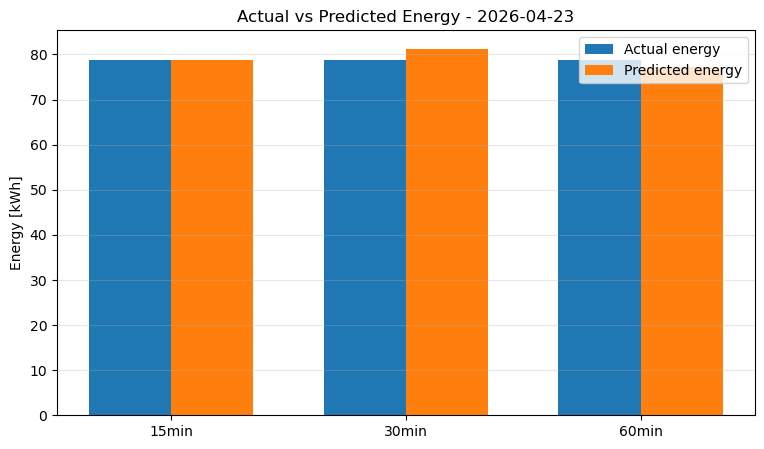

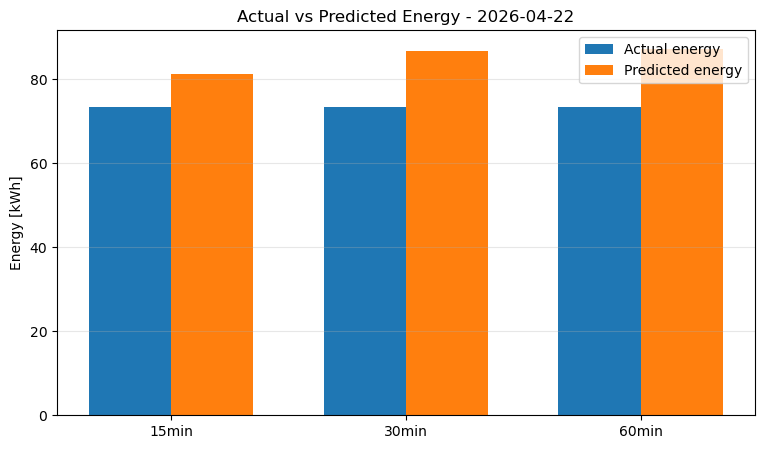

In [116]:
import matplotlib.pyplot as plt

def plot_energy_comparison_for_day(daily_df, selected_day):
    plot_df = daily_df[daily_df["date"] == selected_day].copy()
    plot_df = plot_df.sort_values("resolution")

    x = np.arange(len(plot_df))
    width = 0.35

    plt.figure(figsize=(9, 5))
    plt.bar(x - width/2, plot_df["actual_energy_kWh"], width, label="Actual energy")
    plt.bar(x + width/2, plot_df["predicted_energy_kWh"], width, label="Predicted energy")

    plt.xticks(x, plot_df["resolution"])
    plt.ylabel("Energy [kWh]")
    plt.title(f"Actual vs Predicted Energy - {selected_day}")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.show()


plot_energy_comparison_for_day(daily_energy_common, best_day)
plot_energy_comparison_for_day(daily_energy_common, worst_day)

All rows: 37
Rows with valid constant baseline: 34


,date,issue_time,resolution,n_horizon_steps,actual_energy_kWh,ml_predicted_energy_kWh,constant_load_kW,constant_energy_kWh,ml_residual_energy_kWh,constant_residual_energy_kWh,ml_abs_energy_error_kWh,constant_abs_energy_error_kWh,ml_abs_energy_error_%,constant_abs_energy_error_%,ml_error_reduction_vs_constant_kWh,ml_error_reduction_vs_constant_%
1,2026-04-13,2026-04-12 23:45:00,15min,96,109.015918,137.160307,6.16767,148.02408,-28.144389,-39.008162,28.144389,39.008162,25.816770,35.782080,10.863773,27.850001
2,2026-04-14,2026-04-13 23:45:00,15min,96,101.082583,106.437381,5.75100,138.02400,-5.354799,-36.941418,5.354799,36.941418,5.297450,36.545779,31.586619,85.504620
3,2026-04-15,2026-04-14 23:45:00,15min,96,99.525425,101.860943,5.75933,138.22392,-2.335518,-38.698495,2.335518,38.698495,2.346655,38.883024,36.362977,93.964834
4,2026-04-16,2026-04-15 23:45:00,15min,96,92.572997,99.250231,5.52667,132.64008,-6.677234,-40.067083,6.677234,40.067083,7.212939,43.281609,33.389849,83.334864
5,2026-04-17,2026-04-16 23:45:00,15min,96,83.631670,96.067687,4.48733,107.69592,-12.436017,-24.064250,12.436017,24.064250,14.869985,28.774088,11.628233,48.321611


Best forecasted day based on ML energy error: 2026-04-23
Worst forecasted day based on ML energy error: 2026-04-13

Best days:


,date,mean_ml_abs_error_kWh,mean_constant_abs_error_kWh,mean_ml_abs_error_percent,mean_constant_abs_error_percent,mean_ml_reduction_vs_constant_kWh,mean_ml_reduction_vs_constant_percent,n_resolutions
10,2026-04-23,1.450224,16.687148,1.842415,21.199923,15.236924,90.831080,3
7,2026-04-20,1.974514,28.328215,2.487054,35.681580,26.353701,93.029866,1
11,2026-04-24,2.012614,23.260068,2.250176,26.006383,21.247454,91.008755,3
2,2026-04-15,2.335518,38.698495,2.346655,38.883024,36.362977,93.964834,1
12,2026-04-25,2.687825,15.441542,2.990569,17.177116,12.753717,42.447533,3
8,2026-04-21,3.037004,14.651753,3.625311,17.489984,11.614748,79.272073,1
1,2026-04-14,5.354799,36.941418,5.297450,36.545779,31.586619,85.504620,1
3,2026-04-16,6.677234,40.067083,7.212939,43.281609,33.389849,83.334864,1
17,2026-04-30,6.840728,33.958507,8.691872,43.109859,27.117779,80.002020,3
16,2026-04-29,7.120922,30.426165,9.139014,39.049038,23.305243,76.401645,3



Worst days:


,date,mean_ml_abs_error_kWh,mean_constant_abs_error_kWh,mean_ml_abs_error_percent,mean_constant_abs_error_percent,mean_ml_reduction_vs_constant_kWh,mean_ml_reduction_vs_constant_percent,n_resolutions
0,2026-04-13,28.144389,39.008162,25.816770,35.782080,10.863773,27.850001,1
6,2026-04-19,14.286504,42.996291,18.612934,56.017001,28.709787,66.772706,1
4,2026-04-17,12.436017,24.064250,14.869985,28.774088,11.628233,48.321611,1
13,2026-04-26,8.813393,47.511253,10.098445,54.438718,38.697861,80.366659,3
5,2026-04-18,7.932503,1.837497,9.541301,2.210162,-6.095005,-331.701406,1
9,2026-04-22,7.929292,18.762829,10.812706,25.585760,10.833537,57.739359,1
14,2026-04-27,7.383425,21.943167,9.126513,27.123537,14.559742,67.078184,3
15,2026-04-28,7.204418,35.806509,9.191479,45.682352,28.602091,78.871168,3
16,2026-04-29,7.120922,30.426165,9.139014,39.049038,23.305243,76.401645,3
17,2026-04-30,6.840728,33.958507,8.691872,43.109859,27.117779,80.002020,3


,day_type,date,issue_time,resolution,actual_energy_kWh,ml_predicted_energy_kWh,ml_residual_energy_kWh,ml_abs_energy_error_kWh,ml_abs_energy_error_%,constant_load_kW,constant_energy_kWh,constant_residual_energy_kWh,constant_abs_energy_error_kWh,constant_abs_energy_error_%,ml_error_reduction_vs_constant_kWh,ml_error_reduction_vs_constant_%,n_horizon_steps
11,best_day,2026-04-23,2026-04-22 23:45:00,15min,78.713250,78.997243,-0.283993,0.283993,0.360795,3.96733,95.21592,-16.502670,16.502670,20.965555,16.218677,98.279107,96
20,best_day,2026-04-23,2026-04-22 23:30:00,30min,78.713255,81.302387,-2.589132,2.589132,3.289322,3.87517,93.00408,-14.290825,14.290825,18.155551,11.701693,81.882555,48
29,best_day,2026-04-23,2026-04-22 23:00:00,60min,78.713250,77.235703,1.477547,1.477547,1.877127,4.08255,97.98120,-19.267950,19.267950,24.478661,17.790403,92.331579,24
1,worst_day,2026-04-13,2026-04-12 23:45:00,15min,109.015918,137.160307,-28.144389,28.144389,25.816770,6.16767,148.02408,-39.008162,39.008162,35.782080,10.863773,27.850001,96


,day_type,date,actual_energy_kWh,ml_predicted_energy_kWh,constant_energy_kWh,ml_abs_energy_error_kWh,constant_abs_energy_error_kWh,ml_abs_energy_error_percent,constant_abs_energy_error_percent,ml_error_reduction_vs_constant_kWh,ml_error_reduction_vs_constant_percent
0,best_day,2026-04-23,78.713252,79.178444,95.40040,1.450224,16.687148,1.842415,21.199923,15.236924,90.831080
1,worst_day,2026-04-13,109.015918,137.160307,148.02408,28.144389,39.008162,25.816770,35.782080,10.863773,27.850001


,resolution,n_days,actual_energy_kWh,ml_predicted_energy_kWh,constant_energy_kWh,total_ml_abs_error_kWh,total_constant_abs_error_kWh,mean_ml_abs_error_kWh,mean_constant_abs_error_kWh,mean_ml_abs_error_percent,mean_constant_abs_error_percent,mean_ml_reduction_vs_constant_kWh,mean_ml_reduction_vs_constant_percent
0,15min,18,1542.972634,1656.378583,2045.93592,130.772021,502.963286,7.265112,27.942405,8.362354,32.584658,20.677293,46.108024
1,30min,8,661.515175,699.136551,889.19976,47.130237,227.684585,5.891280,28.460573,7.268118,34.483539,22.569293,79.229785
2,60min,8,661.690160,697.190460,891.50136,42.746164,229.811200,5.343270,28.726400,6.493405,34.902460,23.383130,82.665869


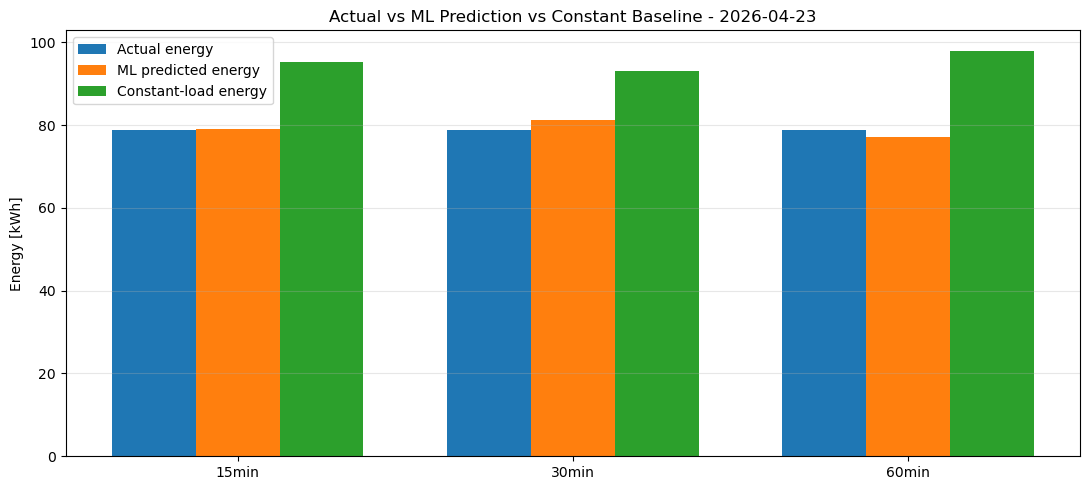

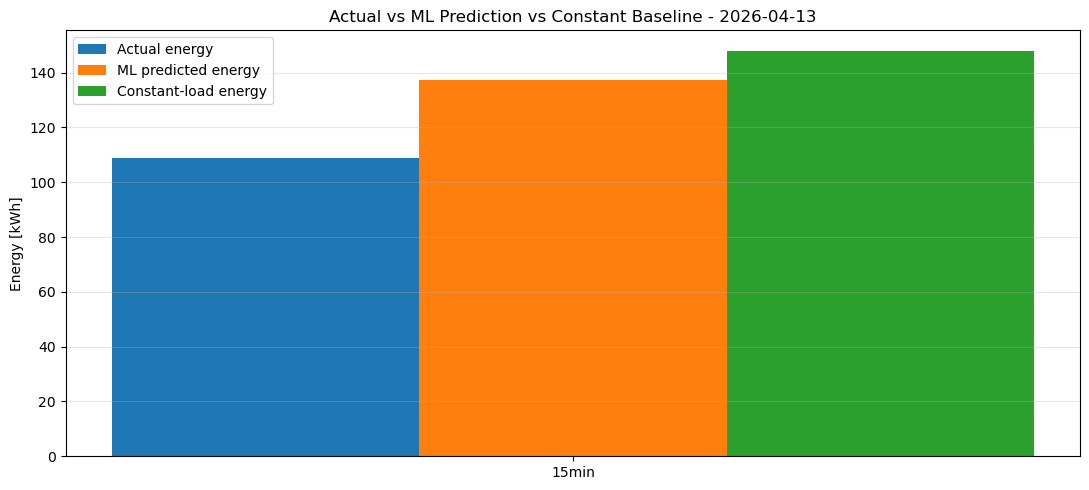

Saved results to: C:\Data_analysis\Thesis\outputs\profile_forecasting\energy_error_comparison


In [104]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# Energy error comparison:
# ML prediction vs constant-load baseline
# Constant baseline = last available actual sample at issue_time
# held constant for the whole next forecasted day/profile
# =========================================================

def resolution_to_hours(resolution: str) -> float:
    mapping = {
        "15min": 15 / 60,
        "30min": 30 / 60,
        "60min": 60 / 60,
        "1h": 1.0,
    }
    if resolution not in mapping:
        raise ValueError(f"Unknown resolution: {resolution}")
    return mapping[resolution]


def read_profile_prediction_csv(pred_path: Path) -> tuple[pd.DataFrame, list[str], list[str]]:
    df = pd.read_csv(pred_path)

    # First column is saved index / forecast issue timestamp
    first_col = df.columns[0]
    df[first_col] = pd.to_datetime(df[first_col], errors="coerce")

    df = df.dropna(subset=[first_col]).copy()
    df = df.rename(columns={first_col: "issue_time"})
    df = df.sort_values("issue_time").reset_index(drop=True)

    true_cols = sorted([c for c in df.columns if c.endswith("_true")])
    pred_cols = sorted([c for c in df.columns if c.endswith("_pred")])

    if len(true_cols) == 0:
        raise ValueError(f"No *_true columns found in {pred_path}")

    if len(pred_cols) == 0:
        raise ValueError(f"No *_pred columns found in {pred_path}")

    if len(true_cols) != len(pred_cols):
        raise ValueError(
            f"Mismatch in {pred_path}: {len(true_cols)} true cols vs {len(pred_cols)} pred cols"
        )

    return df, true_cols, pred_cols


def build_actual_lookup_from_profiles(df: pd.DataFrame, true_cols: list[str], dt_hours: float) -> pd.Series:
    """
    Reconstruct actual values from the profile prediction file.

    For each issue_time:
        y_tplus_001 belongs to issue_time + 1 step
        y_tplus_002 belongs to issue_time + 2 steps
        ...
    
    This allows us to find the actual load at the next forecast issue_time
    from the previous day's true profile.
    """
    rows = []

    step = pd.to_timedelta(dt_hours, unit="h")

    for _, row in df.iterrows():
        issue_time = row["issue_time"]

        for i, col in enumerate(true_cols, start=1):
            actual_time = issue_time + i * step
            rows.append({
                "actual_time": actual_time,
                "actual_load_kW": row[col],
            })

    actual_long = pd.DataFrame(rows)
    actual_long = actual_long.dropna(subset=["actual_time", "actual_load_kW"])

    # If duplicated timestamps exist, keep last occurrence
    actual_lookup = (
        actual_long
        .sort_values("actual_time")
        .drop_duplicates("actual_time", keep="last")
        .set_index("actual_time")["actual_load_kW"]
    )

    return actual_lookup


def daily_energy_ml_vs_constant(pred_path: Path, resolution: str) -> pd.DataFrame:
    dt_hours = resolution_to_hours(resolution)

    df, true_cols, pred_cols = read_profile_prediction_csv(pred_path)

    n_steps = len(true_cols)

    # Reconstruct actual load lookup from true profiles
    actual_lookup = build_actual_lookup_from_profiles(df, true_cols, dt_hours)

    rows = []

    for _, row in df.iterrows():
        issue_time = row["issue_time"]

        # Forecast profile belongs to the period after issue_time.
        # For your thesis explanation, use next calendar day as date label.
        forecast_date = (issue_time + pd.Timedelta(days=1)).date()

        actual_profile = row[true_cols].astype(float).values
        ml_profile = row[pred_cols].astype(float).values

        # Energy from profile
        actual_energy_kWh = np.nansum(actual_profile) * dt_hours
        ml_energy_kWh = np.nansum(ml_profile) * dt_hours

        # Constant baseline:
        # load at issue_time, held constant for all forecast horizon steps
        constant_load_kW = actual_lookup.get(issue_time, np.nan)
        constant_energy_kWh = constant_load_kW * n_steps * dt_hours if pd.notna(constant_load_kW) else np.nan

        rows.append({
            "date": forecast_date,
            "issue_time": issue_time,
            "resolution": resolution,
            "n_horizon_steps": n_steps,

            "actual_energy_kWh": actual_energy_kWh,

            "ml_predicted_energy_kWh": ml_energy_kWh,
            "constant_load_kW": constant_load_kW,
            "constant_energy_kWh": constant_energy_kWh,

            # User-requested residual definition: actual - prediction/input
            "ml_residual_energy_kWh": actual_energy_kWh - ml_energy_kWh,
            "constant_residual_energy_kWh": actual_energy_kWh - constant_energy_kWh,
        })

    out = pd.DataFrame(rows)

    out["ml_abs_energy_error_kWh"] = out["ml_residual_energy_kWh"].abs()
    out["constant_abs_energy_error_kWh"] = out["constant_residual_energy_kWh"].abs()

    out["ml_abs_energy_error_%"] = np.where(
        out["actual_energy_kWh"] != 0,
        out["ml_abs_energy_error_kWh"] / out["actual_energy_kWh"] * 100,
        np.nan,
    )

    out["constant_abs_energy_error_%"] = np.where(
        out["actual_energy_kWh"] != 0,
        out["constant_abs_energy_error_kWh"] / out["actual_energy_kWh"] * 100,
        np.nan,
    )

    # Positive value means ML is better than constant baseline
    out["ml_error_reduction_vs_constant_kWh"] = (
        out["constant_abs_energy_error_kWh"] - out["ml_abs_energy_error_kWh"]
    )

    out["ml_error_reduction_vs_constant_%"] = np.where(
        out["constant_abs_energy_error_kWh"] != 0,
        out["ml_error_reduction_vs_constant_kWh"] / out["constant_abs_energy_error_kWh"] * 100,
        np.nan,
    )

    return out


# =========================================================
# Run for all prediction files
# =========================================================

daily_tables = []

for resolution, path in prediction_files.items():
    daily_res = daily_energy_ml_vs_constant(path, resolution)
    daily_tables.append(daily_res)

daily_energy_comparison = pd.concat(daily_tables, ignore_index=True)

# Remove rows where constant baseline cannot be calculated.
# Usually the first test day may be NaN because the previous day's true profile
# is not present in the prediction CSV.
daily_energy_common = daily_energy_comparison.dropna(
    subset=["constant_energy_kWh"]
).copy()

print("All rows:", len(daily_energy_comparison))
print("Rows with valid constant baseline:", len(daily_energy_common))

display(daily_energy_common.head())


# =========================================================
# Find best and worst day based on ML absolute energy error
# =========================================================

day_score = (
    daily_energy_common
    .groupby("date")
    .agg(
        mean_ml_abs_error_kWh=("ml_abs_energy_error_kWh", "mean"),
        mean_constant_abs_error_kWh=("constant_abs_energy_error_kWh", "mean"),
        mean_ml_abs_error_percent=("ml_abs_energy_error_%", "mean"),
        mean_constant_abs_error_percent=("constant_abs_energy_error_%", "mean"),
        mean_ml_reduction_vs_constant_kWh=("ml_error_reduction_vs_constant_kWh", "mean"),
        mean_ml_reduction_vs_constant_percent=("ml_error_reduction_vs_constant_%", "mean"),
        n_resolutions=("resolution", "nunique"),
    )
    .reset_index()
)

best_day = day_score.sort_values("mean_ml_abs_error_kWh", ascending=True).iloc[0]["date"]
worst_day = day_score.sort_values("mean_ml_abs_error_kWh", ascending=False).iloc[0]["date"]

print("Best forecasted day based on ML energy error:", best_day)
print("Worst forecasted day based on ML energy error:", worst_day)

print("\nBest days:")
display(day_score.sort_values("mean_ml_abs_error_kWh").head(10))

print("\nWorst days:")
display(day_score.sort_values("mean_ml_abs_error_kWh", ascending=False).head(10))


# =========================================================
# Best and worst day detailed comparison
# =========================================================

best_worst_comparison = daily_energy_common[
    daily_energy_common["date"].isin([best_day, worst_day])
].copy()

best_worst_comparison["day_type"] = np.where(
    best_worst_comparison["date"] == best_day,
    "best_day",
    "worst_day",
)

best_worst_comparison = best_worst_comparison[
    [
        "day_type",
        "date",
        "issue_time",
        "resolution",
        "actual_energy_kWh",

        "ml_predicted_energy_kWh",
        "ml_residual_energy_kWh",
        "ml_abs_energy_error_kWh",
        "ml_abs_energy_error_%",

        "constant_load_kW",
        "constant_energy_kWh",
        "constant_residual_energy_kWh",
        "constant_abs_energy_error_kWh",
        "constant_abs_energy_error_%",

        "ml_error_reduction_vs_constant_kWh",
        "ml_error_reduction_vs_constant_%",
        "n_horizon_steps",
    ]
].sort_values(["day_type", "resolution"])

display(best_worst_comparison)


# =========================================================
# Thesis-friendly summary table
# =========================================================

summary_best_worst = (
    best_worst_comparison
    .groupby("day_type")
    .agg(
        date=("date", "first"),
        actual_energy_kWh=("actual_energy_kWh", "mean"),
        ml_predicted_energy_kWh=("ml_predicted_energy_kWh", "mean"),
        constant_energy_kWh=("constant_energy_kWh", "mean"),
        ml_abs_energy_error_kWh=("ml_abs_energy_error_kWh", "mean"),
        constant_abs_energy_error_kWh=("constant_abs_energy_error_kWh", "mean"),
        ml_abs_energy_error_percent=("ml_abs_energy_error_%", "mean"),
        constant_abs_energy_error_percent=("constant_abs_energy_error_%", "mean"),
        ml_error_reduction_vs_constant_kWh=("ml_error_reduction_vs_constant_kWh", "mean"),
        ml_error_reduction_vs_constant_percent=("ml_error_reduction_vs_constant_%", "mean"),
    )
    .reset_index()
)

display(summary_best_worst)


# =========================================================
# Overall comparison across all valid days
# =========================================================

overall_comparison = (
    daily_energy_common
    .groupby("resolution")
    .agg(
        n_days=("date", "nunique"),
        actual_energy_kWh=("actual_energy_kWh", "sum"),
        ml_predicted_energy_kWh=("ml_predicted_energy_kWh", "sum"),
        constant_energy_kWh=("constant_energy_kWh", "sum"),
        total_ml_abs_error_kWh=("ml_abs_energy_error_kWh", "sum"),
        total_constant_abs_error_kWh=("constant_abs_energy_error_kWh", "sum"),
        mean_ml_abs_error_kWh=("ml_abs_energy_error_kWh", "mean"),
        mean_constant_abs_error_kWh=("constant_abs_energy_error_kWh", "mean"),
        mean_ml_abs_error_percent=("ml_abs_energy_error_%", "mean"),
        mean_constant_abs_error_percent=("constant_abs_energy_error_%", "mean"),
        mean_ml_reduction_vs_constant_kWh=("ml_error_reduction_vs_constant_kWh", "mean"),
        mean_ml_reduction_vs_constant_percent=("ml_error_reduction_vs_constant_%", "mean"),
    )
    .reset_index()
)

display(overall_comparison)


# =========================================================
# Plot: Best and worst day energy comparison
# =========================================================

def plot_ml_vs_constant_for_day(daily_df, selected_day):
    plot_df = daily_df[daily_df["date"] == selected_day].copy()
    plot_df = plot_df.sort_values("resolution")

    x = np.arange(len(plot_df))
    width = 0.25

    plt.figure(figsize=(11, 5))

    plt.bar(x - width, plot_df["actual_energy_kWh"], width, label="Actual energy")
    plt.bar(x, plot_df["ml_predicted_energy_kWh"], width, label="ML predicted energy")
    plt.bar(x + width, plot_df["constant_energy_kWh"], width, label="Constant-load energy")

    plt.xticks(x, plot_df["resolution"])
    plt.ylabel("Energy [kWh]")
    plt.title(f"Actual vs ML Prediction vs Constant Baseline - {selected_day}")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_ml_vs_constant_for_day(daily_energy_common, best_day)
plot_ml_vs_constant_for_day(daily_energy_common, worst_day)


# =========================================================
# Optional: save results
# =========================================================

out_dir = Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\energy_error_comparison")
out_dir.mkdir(parents=True, exist_ok=True)

daily_energy_common.to_csv(out_dir / "daily_ml_vs_constant_energy_error.csv", index=False)
best_worst_comparison.to_csv(out_dir / "best_worst_ml_vs_constant_energy_error.csv", index=False)
overall_comparison.to_csv(out_dir / "overall_ml_vs_constant_energy_error.csv", index=False)

print("Saved results to:", out_dir)

# BA_TotActPwr_BESS_AC_Panel2

In [105]:
# Change these paths to your actual saved prediction CSVs
prediction_files = {
    "15min": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_103352_3e95d759_xgboost_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv"),
    "30min": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260527_092954_174e032d_random_forest_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv"),
    "60min": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260527_083211_c3cb7819_ridge_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv"),
}

target_col = "BU_TotActPwr_SDB_EL_Substation_profile_predictions"  


from pathlib import Path
import pandas as pd
import numpy as np


def resolution_to_hours(resolution: str) -> float:
    mapping = {
        "15min": 15 / 60,
        "30min": 30 / 60,
        "60min": 60 / 60,
    }
    if resolution not in mapping:
        raise ValueError(f"Unknown resolution: {resolution}")
    return mapping[resolution]


def daily_energy_from_profile_predictions(pred_path: Path, resolution: str) -> pd.DataFrame:


    dt_hours = resolution_to_hours(resolution)

    df = pd.read_csv(pred_path)

    # First column is usually the saved index / issue timestamp
    first_col = df.columns[0]
    df[first_col] = pd.to_datetime(df[first_col], errors="coerce")

    df = df.dropna(subset=[first_col]).copy()
    df = df.rename(columns={first_col: "issue_time"})

    true_cols = sorted([c for c in df.columns if c.endswith("_true")])
    pred_cols = sorted([c for c in df.columns if c.endswith("_pred")])

    if not true_cols:
        raise ValueError(f"No *_true columns found in: {pred_path}")

    if not pred_cols:
        raise ValueError(f"No *_pred columns found in: {pred_path}")

    if len(true_cols) != len(pred_cols):
        raise ValueError(
            f"Different number of true and pred columns in {pred_path}: "
            f"{len(true_cols)} true vs {len(pred_cols)} pred"
        )

    rows = []

    for _, row in df.iterrows():
        issue_time = row["issue_time"]

        # Your forecast is issued at the end of the previous day.
        # So the predicted profile belongs to the next calendar day.
        forecast_date = (issue_time + pd.Timedelta(days=1)).date()

        actual_energy_kWh = row[true_cols].sum() * dt_hours
        predicted_energy_kWh = row[pred_cols].sum() * dt_hours

        rows.append({
            "date": forecast_date,
            "issue_time": issue_time,
            "resolution": resolution,
            "actual_energy_kWh": actual_energy_kWh,
            "predicted_energy_kWh": predicted_energy_kWh,
            "n_horizon_steps": len(true_cols),
        })

    daily = pd.DataFrame(rows)

    daily["energy_error_kWh"] = (
        daily["predicted_energy_kWh"] - daily["actual_energy_kWh"]
    )

    daily["abs_energy_error_kWh"] = daily["energy_error_kWh"].abs()

    daily["energy_error_percent"] = np.where(
        daily["actual_energy_kWh"] != 0,
        daily["energy_error_kWh"] / daily["actual_energy_kWh"] * 100,
        np.nan,
    )

    daily["abs_energy_error_percent"] = daily["energy_error_percent"].abs()

    return daily


daily_tables = []

for resolution, path in prediction_files.items():
    daily_res = daily_energy_from_profile_predictions(path, resolution)
    daily_tables.append(daily_res)

daily_energy_all = pd.concat(daily_tables, ignore_index=True)

display(daily_energy_all.head())


day_score = (
    daily_energy_common
    .groupby("date")
    .agg(
        mean_abs_energy_error_kWh=("abs_energy_error_kWh", "mean"),
        max_abs_energy_error_kWh=("abs_energy_error_kWh", "max"),
        mean_abs_energy_error_percent=("abs_energy_error_percent", "mean"),
    )
    .reset_index()
)

best_day = day_score.sort_values("mean_abs_energy_error_kWh", ascending=True).iloc[0]["date"]
worst_day = day_score.sort_values("mean_abs_energy_error_kWh", ascending=False).iloc[0]["date"]

print("Best forecasted day:", best_day)
print("Worst forecasted day:", worst_day)

display(day_score.sort_values("mean_abs_energy_error_kWh").head(10))
display(day_score.sort_values("mean_abs_energy_error_kWh", ascending=False).head(10))
best_worst_comparison = daily_energy_common[
    daily_energy_common["date"].isin([best_day, worst_day])
].copy()

best_worst_comparison["day_type"] = np.where(
    best_worst_comparison["date"] == best_day,
    "best_day",
    "worst_day",
)

best_worst_comparison = best_worst_comparison[
    [
        "day_type",
        "date",
        "resolution",
        "actual_energy_kWh",
        "predicted_energy_kWh",
        "energy_error_kWh",
        "abs_energy_error_kWh",
        "energy_error_percent",
        "abs_energy_error_percent",
        "n_horizon_steps",
    ]
].sort_values(["day_type", "resolution"])

display(best_worst_comparison)


total_energy_comparison = (
    daily_energy_common
    .groupby("resolution")
    .agg(
        actual_energy_kWh=("actual_energy_kWh", "sum"),
        predicted_energy_kWh=("predicted_energy_kWh", "sum"),
        total_abs_daily_error_kWh=("abs_energy_error_kWh", "sum"),
        mean_daily_abs_error_kWh=("abs_energy_error_kWh", "mean"),
        mean_daily_abs_error_percent=("abs_energy_error_percent", "mean"),
        n_days=("date", "nunique"),
    )
    .reset_index()
)

total_energy_comparison["total_energy_error_kWh"] = (
    total_energy_comparison["predicted_energy_kWh"]
    - total_energy_comparison["actual_energy_kWh"]
)

total_energy_comparison["total_energy_error_percent"] = np.where(
    total_energy_comparison["actual_energy_kWh"] != 0,
    total_energy_comparison["total_energy_error_kWh"]
    / total_energy_comparison["actual_energy_kWh"] * 100,
    np.nan,
)

display(total_energy_comparison.sort_values("mean_daily_abs_error_kWh"))

import matplotlib.pyplot as plt

def plot_energy_comparison_for_day(daily_df, selected_day):
    plot_df = daily_df[daily_df["date"] == selected_day].copy()
    plot_df = plot_df.sort_values("resolution")

    x = np.arange(len(plot_df))
    width = 0.35

    plt.figure(figsize=(9, 5))
    plt.bar(x - width/2, plot_df["actual_energy_kWh"], width, label="Actual energy")
    plt.bar(x + width/2, plot_df["predicted_energy_kWh"], width, label="Predicted energy")

    plt.xticks(x, plot_df["resolution"])
    plt.ylabel("Energy [kWh]")
    plt.title(f"Actual vs Predicted Energy - {selected_day}")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.show()


plot_energy_comparison_for_day(daily_energy_common, best_day)
plot_energy_comparison_for_day(daily_energy_common, worst_day)

,date,issue_time,resolution,actual_energy_kWh,predicted_energy_kWh,n_horizon_steps,energy_error_kWh,abs_energy_error_kWh,energy_error_percent,abs_energy_error_percent
0,2026-04-12,2026-04-11 23:45:00,15min,42.285420,43.107065,24,0.821645,0.821645,1.943093,1.943093
1,2026-04-13,2026-04-12 23:45:00,15min,33.370748,36.708049,24,3.337302,3.337302,10.000680,10.000680
2,2026-04-14,2026-04-13 23:45:00,15min,30.062083,29.379186,24,-0.682896,0.682896,-2.271620,2.271620
3,2026-04-15,2026-04-14 23:45:00,15min,27.298545,29.943479,24,2.644934,2.644934,9.688919,9.688919
4,2026-04-16,2026-04-15 23:45:00,15min,28.372495,29.243301,24,0.870806,0.870806,3.069192,3.069192


KeyError: "Label(s) ['abs_energy_error_kWh', 'abs_energy_error_percent'] do not exist"

# Total Load

In [117]:
prediction_files = {
    "15min": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_130357_63eba77e_ridge_BU_TotActPwr_Academy_profile_predictions.csv"),
    "30min": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_144150_088cccee_ridge_BU_TotActPwr_Academy_profile_predictions.csv"),
    "60min": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_093036_4a85546b_xgboost_BU_TotActPwr_Academy_profile_predictions.csv"),
}
prediction_files = {
    "15min": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_104832_8082fb66_ridge_BU_TotActPwr_Tech_Room_profile_predictions.csv"),
    "30min": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260527_102452_d1d61cc1_xgboost_BU_TotActPwr_Tech_Room_profile_predictions.csv"),
    "60min": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_111054_750e3408_xgboost_BU_TotActPwr_Tech_Room_profile_predictions.csv"),
}
prediction_files = {
    "15min": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260528_115442_63c0a563_random_forest_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv"),
    "30min": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260527_092954_174e032d_random_forest_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv"),
    "60min": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260527_083211_c3cb7819_ridge_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv"),
}


In [119]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# Give paths for all predicted load columns here
# Structure:
# resolution -> target/load name -> prediction CSV path
# =========================================================

prediction_files_all_loads = {
    "15min": {
        "BU_TotActPwr_SDB_EL_Substation": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260528_115442_63c0a563_random_forest_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv"),
        "BU_TotActPwr_Academy": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_130357_63eba77e_ridge_BU_TotActPwr_Academy_profile_predictions.csv"),
        "BU_TotActPwr_Tech_Room": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_104832_8082fb66_ridge_BU_TotActPwr_Tech_Room_profile_predictions.csv"),
        # add more load columns here
    },

    "30min": {
        "BU_TotActPwr_SDB_EL_Substation": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260527_092954_174e032d_random_forest_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv"),
        "BU_TotActPwr_Academy": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_144150_088cccee_ridge_BU_TotActPwr_Academy_profile_predictions.csv"),
        "BU_TotActPwr_Tech_Room": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_111054_750e3408_xgboost_BU_TotActPwr_Tech_Room_profile_predictions.csv"),
        # add more load columns here
    },

    "60min": {
        "BU_TotActPwr_SDB_EL_Substation": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260527_083211_c3cb7819_ridge_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv"),
        "BU_TotActPwr_Academy": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_093036_4a85546b_xgboost_BU_TotActPwr_Academy_profile_predictions.csv"),
        "BU_TotActPwr_Tech_Room": Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_111054_750e3408_xgboost_BU_TotActPwr_Tech_Room_profile_predictions.csv"),
        # add more load columns here
    },
}

Processing 15min | BU_TotActPwr_SDB_EL_Substation
Processing 15min | BU_TotActPwr_Academy
Processing 15min | BU_TotActPwr_Tech_Room
Processing 30min | BU_TotActPwr_SDB_EL_Substation
Processing 30min | BU_TotActPwr_Academy
Processing 30min | BU_TotActPwr_Tech_Room
Processing 60min | BU_TotActPwr_SDB_EL_Substation
Processing 60min | BU_TotActPwr_Academy
Processing 60min | BU_TotActPwr_Tech_Room


,date,issue_time,resolution,load_name,n_horizon_steps,actual_energy_kWh,ml_predicted_energy_kWh,constant_load_kW,constant_energy_kWh,ml_residual_energy_kWh,constant_residual_energy_kWh,ml_abs_energy_error_kWh,constant_abs_energy_error_kWh,ml_abs_energy_error_%,constant_abs_energy_error_%
0,2026-04-21,2026-04-20 23:45:00,15min,BU_TotActPwr_SDB_EL_Substation,96,83.772247,80.789117,NaN,NaN,2.983130,NaN,2.983130,NaN,3.561000,NaN
1,2026-04-22,2026-04-21 23:45:00,15min,BU_TotActPwr_SDB_EL_Substation,96,73.333091,81.286804,3.83733,92.09592,-7.953713,-18.762829,7.953713,18.762829,10.846008,25.585760
2,2026-04-23,2026-04-22 23:45:00,15min,BU_TotActPwr_SDB_EL_Substation,96,78.713250,78.841121,3.96733,95.21592,-0.127871,-16.502670,0.127871,16.502670,0.162452,20.965555
3,2026-04-24,2026-04-23 23:45:00,15min,BU_TotActPwr_SDB_EL_Substation,96,89.406368,88.520544,4.76767,114.42408,0.885823,-25.017713,0.885823,25.017713,0.990783,27.982025
4,2026-04-25,2026-04-24 23:45:00,15min,BU_TotActPwr_SDB_EL_Substation,96,89.863930,85.041728,3.87200,92.92800,4.822202,-3.064070,4.822202,3.064070,5.366115,3.409677


,date,issue_time,resolution,n_load_columns,total_actual_energy_kWh,total_ml_predicted_energy_kWh,total_constant_energy_kWh,n_valid_constant_loads,total_ml_residual_energy_kWh,total_constant_residual_energy_kWh,total_ml_abs_energy_error_kWh,total_constant_abs_energy_error_kWh,total_ml_abs_energy_error_%,total_constant_abs_energy_error_%,ml_error_reduction_vs_constant_kWh,ml_error_reduction_vs_constant_%
5,2026-04-13,2026-04-12 23:00:00,60min,2,342.614360,274.156087,184.22400,2,68.458273,158.390360,68.458273,158.390360,19.981145,46.229925,89.932087,56.778763
6,2026-04-13,2026-04-12 23:30:00,30min,1,280.942655,204.356793,82.27200,1,76.585862,198.670655,76.585862,198.670655,27.260318,70.715732,122.084793,61.450843
7,2026-04-13,2026-04-12 23:45:00,15min,2,342.614340,252.521698,178.75200,2,90.092642,163.862340,90.092642,163.862340,26.295642,47.827052,73.769698,45.019312
9,2026-04-14,2026-04-13 23:00:00,60min,2,294.611540,292.157729,210.71808,2,2.453811,83.893460,2.453811,83.893460,0.832897,28.475959,81.439649,97.075087
10,2026-04-14,2026-04-13 23:30:00,30min,1,232.991930,233.558275,116.45592,1,-0.566345,116.536010,0.566345,116.536010,0.243075,50.017187,115.969665,99.514017


,date,mean_total_actual_energy_kWh,mean_total_ml_predicted_energy_kWh,mean_total_constant_energy_kWh,mean_total_ml_abs_error_kWh,mean_total_constant_abs_error_kWh,mean_total_ml_abs_error_percent,mean_total_constant_abs_error_percent,mean_ml_error_reduction_vs_constant_kWh,mean_ml_error_reduction_vs_constant_percent,n_resolutions,n_load_columns
1,2026-04-14,274.071660,267.618285,177.90600,6.830938,96.165660,2.335573,36.128635,89.334722,92.249676,3,2
4,2026-04-17,206.299139,212.080051,153.11200,7.466344,53.187139,3.413610,27.565065,45.720795,82.934885,3,2
11,2026-04-24,298.363457,288.141243,257.38872,10.222214,40.974737,3.426717,14.396210,30.752523,71.203513,3,3
6,2026-04-19,142.823134,160.190807,149.46408,17.367672,17.590769,12.152172,12.720277,0.223097,1.970393,3,2
15,2026-04-28,291.314937,298.358111,266.66192,18.141329,24.653017,5.885853,9.193997,6.511687,-113.681119,3,3
2,2026-04-15,279.883258,258.389289,159.07264,21.493970,120.810618,7.638167,44.278042,99.316649,81.662702,3,2
16,2026-04-29,300.546890,277.682431,259.83136,22.864459,40.715530,7.790574,14.124653,17.851071,42.370210,3,3
3,2026-04-16,224.404963,249.540430,176.89928,25.135467,47.505683,11.602742,22.621732,22.370217,43.304178,3,2
17,2026-04-30,274.166500,300.297599,287.02720,26.131099,22.142227,9.726346,7.931789,-3.988872,-30.532109,3,3
14,2026-04-27,304.739942,276.526418,248.15144,28.213523,56.588502,9.375212,19.102000,28.374978,49.808758,3,3


,resolution,n_days,n_load_columns,total_actual_energy_kWh,total_ml_predicted_energy_kWh,total_constant_energy_kWh,total_ml_abs_error_kWh,total_constant_abs_error_kWh,mean_daily_ml_abs_error_kWh,mean_daily_constant_abs_error_kWh,mean_daily_ml_abs_error_percent,mean_daily_constant_abs_error_percent,mean_ml_error_reduction_vs_constant_kWh,mean_ml_error_reduction_vs_constant_percent
0,15min,17,3,4637.342106,4442.360305,4110.54408,600.158767,814.426224,35.303457,47.907425,13.236197,17.032115,12.603968,-25.420815
1,30min,17,2,3563.603810,3510.446168,2473.80768,526.703189,1172.426810,30.982541,68.966283,16.220645,31.798200,37.983742,-135.446518
2,60min,17,3,4564.531170,4663.815578,4051.02312,414.180711,845.292870,24.363571,49.723110,9.417367,18.128845,25.359539,36.517861


Best total-load forecasted day: 2026-04-14
Worst total-load forecasted day: 2026-04-13


,date,issue_time,resolution,n_load_columns,total_actual_energy_kWh,total_ml_predicted_energy_kWh,total_constant_energy_kWh,n_valid_constant_loads,total_ml_residual_energy_kWh,total_constant_residual_energy_kWh,total_ml_abs_energy_error_kWh,total_constant_abs_energy_error_kWh,total_ml_abs_energy_error_%,total_constant_abs_energy_error_%,ml_error_reduction_vs_constant_kWh,ml_error_reduction_vs_constant_%,day_type
11,2026-04-14,2026-04-13 23:45:00,15min,2,294.611510,277.138850,206.54400,2,17.472660,88.067510,17.472660,88.067510,5.930746,29.892759,70.594850,80.159925,best_total_day
10,2026-04-14,2026-04-13 23:30:00,30min,1,232.991930,233.558275,116.45592,1,-0.566345,116.536010,0.566345,116.536010,0.243075,50.017187,115.969665,99.514017,best_total_day
9,2026-04-14,2026-04-13 23:00:00,60min,2,294.611540,292.157729,210.71808,2,2.453811,83.893460,2.453811,83.893460,0.832897,28.475959,81.439649,97.075087,best_total_day
7,2026-04-13,2026-04-12 23:45:00,15min,2,342.614340,252.521698,178.75200,2,90.092642,163.862340,90.092642,163.862340,26.295642,47.827052,73.769698,45.019312,worst_total_day
6,2026-04-13,2026-04-12 23:30:00,30min,1,280.942655,204.356793,82.27200,1,76.585862,198.670655,76.585862,198.670655,27.260318,70.715732,122.084793,61.450843,worst_total_day
5,2026-04-13,2026-04-12 23:00:00,60min,2,342.614360,274.156087,184.22400,2,68.458273,158.390360,68.458273,158.390360,19.981145,46.229925,89.932087,56.778763,worst_total_day


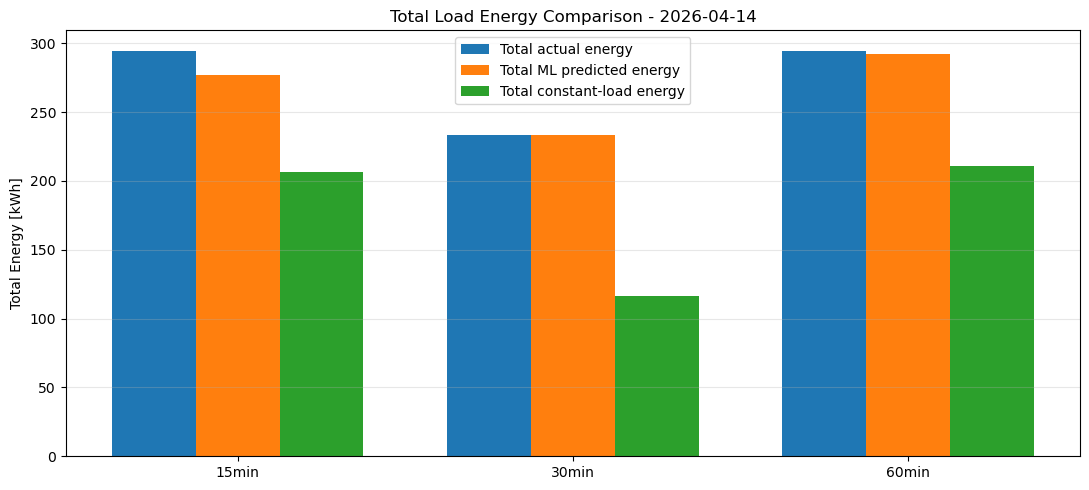

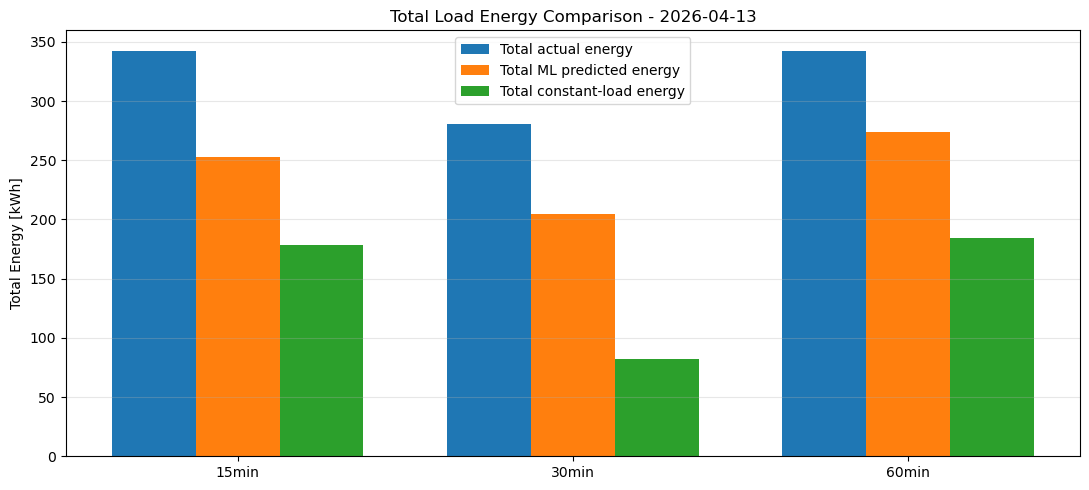

Saved all total-load energy error results to:
C:\Data_analysis\Thesis\outputs\profile_forecasting\total_load_energy_error_comparison


In [120]:
# =========================================================
# Total-load day-wise energy error comparison
# ML prediction vs constant-load baseline
# For multiple predicted load columns
# =========================================================

def resolution_to_hours(resolution: str) -> float:
    mapping = {
        "15min": 15 / 60,
        "30min": 30 / 60,
        "60min": 60 / 60,
        "1h": 1.0,
    }
    if resolution not in mapping:
        raise ValueError(f"Unknown resolution: {resolution}")
    return mapping[resolution]


def read_profile_prediction_csv(pred_path: Path):
    df = pd.read_csv(pred_path)

    first_col = df.columns[0]
    df[first_col] = pd.to_datetime(df[first_col], errors="coerce")

    df = df.dropna(subset=[first_col]).copy()
    df = df.rename(columns={first_col: "issue_time"})
    df = df.sort_values("issue_time").reset_index(drop=True)

    true_cols = sorted([c for c in df.columns if c.endswith("_true")])
    pred_cols = sorted([c for c in df.columns if c.endswith("_pred")])

    if len(true_cols) == 0:
        raise ValueError(f"No *_true columns found in: {pred_path}")

    if len(pred_cols) == 0:
        raise ValueError(f"No *_pred columns found in: {pred_path}")

    if len(true_cols) != len(pred_cols):
        raise ValueError(
            f"Mismatch in {pred_path}: {len(true_cols)} true columns vs {len(pred_cols)} pred columns"
        )

    return df, true_cols, pred_cols


def build_actual_lookup_from_profiles(df: pd.DataFrame, true_cols: list[str], dt_hours: float) -> pd.Series:
    """
    Reconstruct actual time-series values from wide profile CSV.

    y_tplus_001 belongs to issue_time + 1 step.
    y_tplus_002 belongs to issue_time + 2 steps.
    ...
    """
    rows = []
    step = pd.to_timedelta(dt_hours, unit="h")

    for _, row in df.iterrows():
        issue_time = row["issue_time"]

        for i, col in enumerate(true_cols, start=1):
            actual_time = issue_time + i * step
            rows.append({
                "actual_time": actual_time,
                "actual_load_kW": row[col],
            })

    actual_long = pd.DataFrame(rows)
    actual_long = actual_long.dropna(subset=["actual_time", "actual_load_kW"])

    actual_lookup = (
        actual_long
        .sort_values("actual_time")
        .drop_duplicates("actual_time", keep="last")
        .set_index("actual_time")["actual_load_kW"]
    )

    return actual_lookup


def daily_energy_for_one_load(pred_path: Path, resolution: str, load_name: str) -> pd.DataFrame:
    dt_hours = resolution_to_hours(resolution)

    df, true_cols, pred_cols = read_profile_prediction_csv(pred_path)
    actual_lookup = build_actual_lookup_from_profiles(df, true_cols, dt_hours)

    n_steps = len(true_cols)

    rows = []

    for _, row in df.iterrows():
        issue_time = row["issue_time"]
        forecast_date = (issue_time + pd.Timedelta(days=1)).date()

        actual_profile = row[true_cols].astype(float).values
        predicted_profile = row[pred_cols].astype(float).values

        actual_energy_kWh = np.nansum(actual_profile) * dt_hours
        predicted_energy_kWh = np.nansum(predicted_profile) * dt_hours

        constant_load_kW = actual_lookup.get(issue_time, np.nan)
        constant_energy_kWh = (
            constant_load_kW * n_steps * dt_hours
            if pd.notna(constant_load_kW)
            else np.nan
        )

        rows.append({
            "date": forecast_date,
            "issue_time": issue_time,
            "resolution": resolution,
            "load_name": load_name,
            "n_horizon_steps": n_steps,

            "actual_energy_kWh": actual_energy_kWh,
            "ml_predicted_energy_kWh": predicted_energy_kWh,
            "constant_load_kW": constant_load_kW,
            "constant_energy_kWh": constant_energy_kWh,
        })

    out = pd.DataFrame(rows)

    out["ml_residual_energy_kWh"] = (
        out["actual_energy_kWh"] - out["ml_predicted_energy_kWh"]
    )

    out["constant_residual_energy_kWh"] = (
        out["actual_energy_kWh"] - out["constant_energy_kWh"]
    )

    out["ml_abs_energy_error_kWh"] = out["ml_residual_energy_kWh"].abs()
    out["constant_abs_energy_error_kWh"] = out["constant_residual_energy_kWh"].abs()

    out["ml_abs_energy_error_%"] = np.where(
        out["actual_energy_kWh"] != 0,
        out["ml_abs_energy_error_kWh"] / out["actual_energy_kWh"] * 100,
        np.nan,
    )

    out["constant_abs_energy_error_%"] = np.where(
        out["actual_energy_kWh"] != 0,
        out["constant_abs_energy_error_kWh"] / out["actual_energy_kWh"] * 100,
        np.nan,
    )

    return out


# =========================================================
# Step 1: calculate energy error for every load column
# =========================================================

all_load_daily_tables = []

for resolution, load_dict in prediction_files_all_loads.items():
    for load_name, pred_path in load_dict.items():
        print(f"Processing {resolution} | {load_name}")
        one_load_daily = daily_energy_for_one_load(
            pred_path=pred_path,
            resolution=resolution,
            load_name=load_name,
        )
        all_load_daily_tables.append(one_load_daily)

all_load_daily_energy = pd.concat(all_load_daily_tables, ignore_index=True)

display(all_load_daily_energy.head())


# =========================================================
# Step 2: sum all load columns to make total load day-wise
# =========================================================

total_daily_energy = (
    all_load_daily_energy
    .groupby(["date", "issue_time", "resolution"], as_index=False)
    .agg(
        n_load_columns=("load_name", "nunique"),
        total_actual_energy_kWh=("actual_energy_kWh", "sum"),
        total_ml_predicted_energy_kWh=("ml_predicted_energy_kWh", "sum"),
        total_constant_energy_kWh=("constant_energy_kWh", "sum"),
    )
)

# If any constant value was missing for a load column, the group sum may still work.
# This column checks how many valid constant entries existed.
valid_constant_counts = (
    all_load_daily_energy
    .assign(valid_constant=all_load_daily_energy["constant_energy_kWh"].notna())
    .groupby(["date", "issue_time", "resolution"], as_index=False)
    .agg(n_valid_constant_loads=("valid_constant", "sum"))
)

total_daily_energy = total_daily_energy.merge(
    valid_constant_counts,
    on=["date", "issue_time", "resolution"],
    how="left"
)

# Keep only days where constant baseline exists for all load columns
total_daily_energy = total_daily_energy[
    total_daily_energy["n_valid_constant_loads"] == total_daily_energy["n_load_columns"]
].copy()


# =========================================================
# Step 3: calculate total-load residuals and errors
# residual = actual - prediction/input
# =========================================================

total_daily_energy["total_ml_residual_energy_kWh"] = (
    total_daily_energy["total_actual_energy_kWh"]
    - total_daily_energy["total_ml_predicted_energy_kWh"]
)

total_daily_energy["total_constant_residual_energy_kWh"] = (
    total_daily_energy["total_actual_energy_kWh"]
    - total_daily_energy["total_constant_energy_kWh"]
)

total_daily_energy["total_ml_abs_energy_error_kWh"] = (
    total_daily_energy["total_ml_residual_energy_kWh"].abs()
)

total_daily_energy["total_constant_abs_energy_error_kWh"] = (
    total_daily_energy["total_constant_residual_energy_kWh"].abs()
)

total_daily_energy["total_ml_abs_energy_error_%"] = np.where(
    total_daily_energy["total_actual_energy_kWh"] != 0,
    total_daily_energy["total_ml_abs_energy_error_kWh"]
    / total_daily_energy["total_actual_energy_kWh"] * 100,
    np.nan,
)

total_daily_energy["total_constant_abs_energy_error_%"] = np.where(
    total_daily_energy["total_actual_energy_kWh"] != 0,
    total_daily_energy["total_constant_abs_energy_error_kWh"]
    / total_daily_energy["total_actual_energy_kWh"] * 100,
    np.nan,
)

total_daily_energy["ml_error_reduction_vs_constant_kWh"] = (
    total_daily_energy["total_constant_abs_energy_error_kWh"]
    - total_daily_energy["total_ml_abs_energy_error_kWh"]
)

total_daily_energy["ml_error_reduction_vs_constant_%"] = np.where(
    total_daily_energy["total_constant_abs_energy_error_kWh"] != 0,
    total_daily_energy["ml_error_reduction_vs_constant_kWh"]
    / total_daily_energy["total_constant_abs_energy_error_kWh"] * 100,
    np.nan,
)

display(total_daily_energy.head())


# =========================================================
# Step 4: day-wise comparison across all resolutions
# =========================================================

day_wise_total_summary = (
    total_daily_energy
    .groupby("date", as_index=False)
    .agg(
        mean_total_actual_energy_kWh=("total_actual_energy_kWh", "mean"),
        mean_total_ml_predicted_energy_kWh=("total_ml_predicted_energy_kWh", "mean"),
        mean_total_constant_energy_kWh=("total_constant_energy_kWh", "mean"),

        mean_total_ml_abs_error_kWh=("total_ml_abs_energy_error_kWh", "mean"),
        mean_total_constant_abs_error_kWh=("total_constant_abs_energy_error_kWh", "mean"),

        mean_total_ml_abs_error_percent=("total_ml_abs_energy_error_%", "mean"),
        mean_total_constant_abs_error_percent=("total_constant_abs_energy_error_%", "mean"),

        mean_ml_error_reduction_vs_constant_kWh=("ml_error_reduction_vs_constant_kWh", "mean"),
        mean_ml_error_reduction_vs_constant_percent=("ml_error_reduction_vs_constant_%", "mean"),

        n_resolutions=("resolution", "nunique"),
        n_load_columns=("n_load_columns", "max"),
    )
)

display(day_wise_total_summary.sort_values("mean_total_ml_abs_error_kWh"))


# =========================================================
# Step 5: resolution-wise total energy comparison
# =========================================================

resolution_wise_total_summary = (
    total_daily_energy
    .groupby("resolution", as_index=False)
    .agg(
        n_days=("date", "nunique"),
        n_load_columns=("n_load_columns", "max"),

        total_actual_energy_kWh=("total_actual_energy_kWh", "sum"),
        total_ml_predicted_energy_kWh=("total_ml_predicted_energy_kWh", "sum"),
        total_constant_energy_kWh=("total_constant_energy_kWh", "sum"),

        total_ml_abs_error_kWh=("total_ml_abs_energy_error_kWh", "sum"),
        total_constant_abs_error_kWh=("total_constant_abs_energy_error_kWh", "sum"),

        mean_daily_ml_abs_error_kWh=("total_ml_abs_energy_error_kWh", "mean"),
        mean_daily_constant_abs_error_kWh=("total_constant_abs_energy_error_kWh", "mean"),

        mean_daily_ml_abs_error_percent=("total_ml_abs_energy_error_%", "mean"),
        mean_daily_constant_abs_error_percent=("total_constant_abs_energy_error_%", "mean"),

        mean_ml_error_reduction_vs_constant_kWh=("ml_error_reduction_vs_constant_kWh", "mean"),
        mean_ml_error_reduction_vs_constant_percent=("ml_error_reduction_vs_constant_%", "mean"),
    )
)

display(resolution_wise_total_summary)


# =========================================================
# Step 6: find best and worst total-load forecasted day
# Based on total ML absolute energy error
# =========================================================

best_total_day = (
    day_wise_total_summary
    .sort_values("mean_total_ml_abs_error_kWh", ascending=True)
    .iloc[0]["date"]
)

worst_total_day = (
    day_wise_total_summary
    .sort_values("mean_total_ml_abs_error_kWh", ascending=False)
    .iloc[0]["date"]
)

print("Best total-load forecasted day:", best_total_day)
print("Worst total-load forecasted day:", worst_total_day)

best_worst_total_comparison = total_daily_energy[
    total_daily_energy["date"].isin([best_total_day, worst_total_day])
].copy()

best_worst_total_comparison["day_type"] = np.where(
    best_worst_total_comparison["date"] == best_total_day,
    "best_total_day",
    "worst_total_day",
)

best_worst_total_comparison = best_worst_total_comparison.sort_values(
    ["day_type", "resolution"]
)

display(best_worst_total_comparison)


# =========================================================
# Step 7: plot best and worst day
# =========================================================

def plot_total_energy_comparison_for_day(df, selected_day):
    plot_df = df[df["date"] == selected_day].copy()
    plot_df = plot_df.sort_values("resolution")

    x = np.arange(len(plot_df))
    width = 0.25

    plt.figure(figsize=(11, 5))

    plt.bar(
        x - width,
        plot_df["total_actual_energy_kWh"],
        width,
        label="Total actual energy",
    )

    plt.bar(
        x,
        plot_df["total_ml_predicted_energy_kWh"],
        width,
        label="Total ML predicted energy",
    )

    plt.bar(
        x + width,
        plot_df["total_constant_energy_kWh"],
        width,
        label="Total constant-load energy",
    )

    plt.xticks(x, plot_df["resolution"])
    plt.ylabel("Total Energy [kWh]")
    plt.title(f"Total Load Energy Comparison - {selected_day}")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_total_energy_comparison_for_day(total_daily_energy, best_total_day)
plot_total_energy_comparison_for_day(total_daily_energy, worst_total_day)


# =========================================================
# Step 8: save outputs
# =========================================================

out_dir = Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\total_load_energy_error_comparison")
out_dir.mkdir(parents=True, exist_ok=True)

all_load_daily_energy.to_csv(
    out_dir / "individual_load_daily_energy_error.csv",
    index=False,
)

total_daily_energy.to_csv(
    out_dir / "total_load_daily_energy_error_by_resolution.csv",
    index=False,
)

day_wise_total_summary.to_csv(
    out_dir / "total_load_day_wise_summary.csv",
    index=False,
)

resolution_wise_total_summary.to_csv(
    out_dir / "total_load_resolution_wise_summary.csv",
    index=False,
)

best_worst_total_comparison.to_csv(
    out_dir / "best_worst_total_load_energy_error.csv",
    index=False,
)

print("Saved all total-load energy error results to:")
print(out_dir)

In [108]:
def resolution_to_hours(resolution: str) -> float:
    mapping = {
        "15min": 15 / 60,
        "30min": 30 / 60,
        "60min": 1.0,
        "1h": 1.0,
    }
    if resolution not in mapping:
        raise ValueError(f"Unknown resolution: {resolution}")
    return mapping[resolution]


def read_profile_prediction_csv(pred_path: Path):
    df = pd.read_csv(pred_path)

    first_col = df.columns[0]
    df[first_col] = pd.to_datetime(df[first_col], errors="coerce")

    df = df.dropna(subset=[first_col]).copy()
    df = df.rename(columns={first_col: "issue_time"})
    df = df.sort_values("issue_time").reset_index(drop=True)

    true_cols = sorted([c for c in df.columns if c.endswith("_true")])
    pred_cols = sorted([c for c in df.columns if c.endswith("_pred")])

    if len(true_cols) == 0:
        raise ValueError(f"No *_true columns found in {pred_path}")

    if len(pred_cols) == 0:
        raise ValueError(f"No *_pred columns found in {pred_path}")

    if len(true_cols) != len(pred_cols):
        raise ValueError(
            f"Mismatch in {pred_path}: {len(true_cols)} true cols vs {len(pred_cols)} pred cols"
        )

    return df, true_cols, pred_cols


def reconstruct_actual_lookup(df, true_cols, dt_hours):
    """
    Reconstruct actual load values from wide profile rows.

    If issue_time = 2026-04-22 23:45,
    then y_tplus_001 = 2026-04-23 00:00,
    ...
    and the last horizon value is near the next issue time.
    """
    rows = []
    step = pd.to_timedelta(dt_hours, unit="h")

    for _, row in df.iterrows():
        issue_time = row["issue_time"]

        for step_id, col in enumerate(true_cols, start=1):
            actual_time = issue_time + step_id * step
            rows.append({
                "actual_time": actual_time,
                "actual_load_kW": row[col],
            })

    actual_long = pd.DataFrame(rows)

    actual_lookup = (
        actual_long
        .dropna(subset=["actual_time", "actual_load_kW"])
        .sort_values("actual_time")
        .drop_duplicates("actual_time", keep="last")
        .set_index("actual_time")["actual_load_kW"]
    )

    return actual_lookup


def calculate_one_load_daily_energy(pred_path: Path, resolution: str, load_name: str) -> pd.DataFrame:
    dt_hours = resolution_to_hours(resolution)

    df, true_cols, pred_cols = read_profile_prediction_csv(pred_path)
    actual_lookup = reconstruct_actual_lookup(df, true_cols, dt_hours)

    n_steps = len(true_cols)

    rows = []

    for _, row in df.iterrows():
        issue_time = row["issue_time"]

        # Forecasted day starts after issue time
        forecast_date = (issue_time + pd.Timedelta(days=1)).date()

        actual_profile = row[true_cols].astype(float).values
        pred_profile = row[pred_cols].astype(float).values

        actual_energy_kWh = np.nansum(actual_profile) * dt_hours
        predicted_energy_kWh = np.nansum(pred_profile) * dt_hours

        # Constant baseline = actual load at issue_time held for full horizon
        constant_load_kW = actual_lookup.get(issue_time, np.nan)

        if pd.notna(constant_load_kW):
            constant_energy_kWh = constant_load_kW * n_steps * dt_hours
        else:
            constant_energy_kWh = np.nan

        rows.append({
            "date": forecast_date,
            "issue_time": issue_time,
            "resolution": resolution,
            "load_name": load_name,
            "n_horizon_steps": n_steps,

            "actual_energy_kWh": actual_energy_kWh,
            "ml_predicted_energy_kWh": predicted_energy_kWh,
            "constant_load_kW": constant_load_kW,
            "constant_energy_kWh": constant_energy_kWh,
        })

    out = pd.DataFrame(rows)

    out["ml_residual_energy_kWh"] = (
        out["actual_energy_kWh"] - out["ml_predicted_energy_kWh"]
    )

    out["constant_residual_energy_kWh"] = (
        out["actual_energy_kWh"] - out["constant_energy_kWh"]
    )

    out["ml_abs_energy_error_kWh"] = out["ml_residual_energy_kWh"].abs()
    out["constant_abs_energy_error_kWh"] = out["constant_residual_energy_kWh"].abs()

    return out


# =========================================================
# Step 1: calculate daily energy for every load column
# =========================================================

all_load_tables = []

for resolution, load_paths in prediction_files_all_loads.items():
    for load_name, pred_path in load_paths.items():
        print(f"Processing {resolution} | {load_name}")
        one = calculate_one_load_daily_energy(
            pred_path=pred_path,
            resolution=resolution,
            load_name=load_name,
        )
        all_load_tables.append(one)

individual_load_daily_energy = pd.concat(all_load_tables, ignore_index=True)

display(individual_load_daily_energy.head())


# =========================================================
# Step 2: strict completeness check
# Keep only date-resolution combinations where ALL expected loads exist
# and ALL constant baselines are valid
# =========================================================

expected_loads_by_resolution = {
    resolution: set(load_paths.keys())
    for resolution, load_paths in prediction_files_all_loads.items()
}

completeness_rows = []

for (date, issue_time, resolution), g in individual_load_daily_energy.groupby(
    ["date", "issue_time", "resolution"]
):
    expected_loads = expected_loads_by_resolution[resolution]
    available_loads = set(g["load_name"].unique())

    missing_loads = sorted(expected_loads - available_loads)

    all_loads_available = available_loads == expected_loads
    all_constant_valid = g["constant_energy_kWh"].notna().all()

    completeness_rows.append({
        "date": date,
        "issue_time": issue_time,
        "resolution": resolution,
        "expected_n_loads": len(expected_loads),
        "available_n_loads": len(available_loads),
        "all_loads_available": all_loads_available,
        "all_constant_valid": all_constant_valid,
        "missing_loads": missing_loads,
    })

completeness_check = pd.DataFrame(completeness_rows)

valid_groups = completeness_check[
    (completeness_check["all_loads_available"]) &
    (completeness_check["all_constant_valid"])
][["date", "issue_time", "resolution"]]

print("Total date-resolution groups:", len(completeness_check))
print("Valid complete groups:", len(valid_groups))

display(completeness_check.head())

# =========================================================
# Step 3: keep only complete groups
# =========================================================

individual_load_daily_energy_valid = individual_load_daily_energy.merge(
    valid_groups,
    on=["date", "issue_time", "resolution"],
    how="inner",
)

print("Rows before strict filtering:", len(individual_load_daily_energy))
print("Rows after strict filtering:", len(individual_load_daily_energy_valid))


# =========================================================
# Step 4: sum load columns to make total daily load energy
# =========================================================

total_daily_energy = (
    individual_load_daily_energy_valid
    .groupby(["date", "issue_time", "resolution"], as_index=False)
    .agg(
        n_load_columns=("load_name", "nunique"),

        total_actual_energy_kWh=("actual_energy_kWh", "sum"),
        total_ml_predicted_energy_kWh=("ml_predicted_energy_kWh", "sum"),
        total_constant_energy_kWh=("constant_energy_kWh", "sum"),
    )
)

# Residual definition: actual - prediction/input
total_daily_energy["total_ml_residual_energy_kWh"] = (
    total_daily_energy["total_actual_energy_kWh"]
    - total_daily_energy["total_ml_predicted_energy_kWh"]
)

total_daily_energy["total_constant_residual_energy_kWh"] = (
    total_daily_energy["total_actual_energy_kWh"]
    - total_daily_energy["total_constant_energy_kWh"]
)

total_daily_energy["total_ml_abs_energy_error_kWh"] = (
    total_daily_energy["total_ml_residual_energy_kWh"].abs()
)

total_daily_energy["total_constant_abs_energy_error_kWh"] = (
    total_daily_energy["total_constant_residual_energy_kWh"].abs()
)

total_daily_energy["total_ml_abs_energy_error_%"] = np.where(
    total_daily_energy["total_actual_energy_kWh"] != 0,
    total_daily_energy["total_ml_abs_energy_error_kWh"]
    / total_daily_energy["total_actual_energy_kWh"] * 100,
    np.nan,
)

total_daily_energy["total_constant_abs_energy_error_%"] = np.where(
    total_daily_energy["total_actual_energy_kWh"] != 0,
    total_daily_energy["total_constant_abs_energy_error_kWh"]
    / total_daily_energy["total_actual_energy_kWh"] * 100,
    np.nan,
)

total_daily_energy["ml_error_reduction_vs_constant_kWh"] = (
    total_daily_energy["total_constant_abs_energy_error_kWh"]
    - total_daily_energy["total_ml_abs_energy_error_kWh"]
)

total_daily_energy["ml_error_reduction_vs_constant_%"] = np.where(
    total_daily_energy["total_constant_abs_energy_error_kWh"] != 0,
    total_daily_energy["ml_error_reduction_vs_constant_kWh"]
    / total_daily_energy["total_constant_abs_energy_error_kWh"] * 100,
    np.nan,
)

display(total_daily_energy.head())


# =========================================================
# Step 5: day-wise summary across available resolutions
# =========================================================

day_wise_total_summary = (
    total_daily_energy
    .groupby("date", as_index=False)
    .agg(
        mean_total_actual_energy_kWh=("total_actual_energy_kWh", "mean"),
        mean_total_ml_predicted_energy_kWh=("total_ml_predicted_energy_kWh", "mean"),
        mean_total_constant_energy_kWh=("total_constant_energy_kWh", "mean"),

        mean_total_ml_abs_error_kWh=("total_ml_abs_energy_error_kWh", "mean"),
        mean_total_constant_abs_error_kWh=("total_constant_abs_energy_error_kWh", "mean"),

        mean_total_ml_abs_error_percent=("total_ml_abs_energy_error_%", "mean"),
        mean_total_constant_abs_error_percent=("total_constant_abs_energy_error_%", "mean"),

        mean_ml_error_reduction_vs_constant_kWh=("ml_error_reduction_vs_constant_kWh", "mean"),
        mean_ml_error_reduction_vs_constant_percent=("ml_error_reduction_vs_constant_%", "mean"),

        n_resolutions=("resolution", "nunique"),
        n_load_columns=("n_load_columns", "max"),
    )
)

display(day_wise_total_summary.sort_values("mean_total_ml_abs_error_kWh"))


# =========================================================
# Step 6: resolution-wise summary
# =========================================================

resolution_wise_total_summary = (
    total_daily_energy
    .groupby("resolution", as_index=False)
    .agg(
        n_days=("date", "nunique"),
        n_load_columns=("n_load_columns", "max"),

        total_actual_energy_kWh=("total_actual_energy_kWh", "sum"),
        total_ml_predicted_energy_kWh=("total_ml_predicted_energy_kWh", "sum"),
        total_constant_energy_kWh=("total_constant_energy_kWh", "sum"),

        total_ml_abs_error_kWh=("total_ml_abs_energy_error_kWh", "sum"),
        total_constant_abs_error_kWh=("total_constant_abs_energy_error_kWh", "sum"),

        mean_daily_ml_abs_error_kWh=("total_ml_abs_energy_error_kWh", "mean"),
        mean_daily_constant_abs_error_kWh=("total_constant_abs_energy_error_kWh", "mean"),

        mean_daily_ml_abs_error_percent=("total_ml_abs_energy_error_%", "mean"),
        mean_daily_constant_abs_error_percent=("total_constant_abs_energy_error_%", "mean"),

        mean_ml_error_reduction_vs_constant_kWh=("ml_error_reduction_vs_constant_kWh", "mean"),
        mean_ml_error_reduction_vs_constant_percent=("ml_error_reduction_vs_constant_%", "mean"),
    )
)

display(resolution_wise_total_summary)


# =========================================================
# Step 7: best and worst total-load day
# =========================================================

best_total_day = (
    day_wise_total_summary
    .sort_values("mean_total_ml_abs_error_kWh", ascending=True)
    .iloc[0]["date"]
)

worst_total_day = (
    day_wise_total_summary
    .sort_values("mean_total_ml_abs_error_kWh", ascending=False)
    .iloc[0]["date"]
)

print("Best total-load forecasted day:", best_total_day)
print("Worst total-load forecasted day:", worst_total_day)

best_worst_total_comparison = total_daily_energy[
    total_daily_energy["date"].isin([best_total_day, worst_total_day])
].copy()

best_worst_total_comparison["day_type"] = np.where(
    best_worst_total_comparison["date"] == best_total_day,
    "best_total_day",
    "worst_total_day",
)

display(best_worst_total_comparison.sort_values(["day_type", "resolution"]))


# =========================================================
# Step 8: save outputs
# =========================================================

out_dir = Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\total_load_energy_error_comparison")
out_dir.mkdir(parents=True, exist_ok=True)

individual_load_daily_energy.to_csv(
    out_dir / "individual_load_daily_energy_all_rows.csv",
    index=False,
)

individual_load_daily_energy_valid.to_csv(
    out_dir / "individual_load_daily_energy_valid_complete_rows.csv",
    index=False,
)

completeness_check.to_csv(
    out_dir / "completeness_check.csv",
    index=False,
)

total_daily_energy.to_csv(
    out_dir / "total_load_daily_energy_error_by_resolution.csv",
    index=False,
)

day_wise_total_summary.to_csv(
    out_dir / "total_load_day_wise_summary.csv",
    index=False,
)

resolution_wise_total_summary.to_csv(
    out_dir / "total_load_resolution_wise_summary.csv",
    index=False,
)

best_worst_total_comparison.to_csv(
    out_dir / "best_worst_total_load_energy_error.csv",
    index=False,
)

print("Saved outputs to:")
print(out_dir)

Processing 15min | BU_TotActPwr_SDB_EL_Substation
Processing 15min | BU_TotActPwr_Academy
Processing 15min | BU_TotActPwr_Tech_Room
Processing 30min | BU_TotActPwr_SDB_EL_Substation
Processing 30min | BU_TotActPwr_Academy
Processing 30min | BU_TotActPwr_Tech_Room
Processing 60min | BU_TotActPwr_SDB_EL_Substation
Processing 60min | BU_TotActPwr_Academy
Processing 60min | BU_TotActPwr_Tech_Room


,date,issue_time,resolution,load_name,n_horizon_steps,actual_energy_kWh,ml_predicted_energy_kWh,constant_load_kW,constant_energy_kWh,ml_residual_energy_kWh,constant_residual_energy_kWh,ml_abs_energy_error_kWh,constant_abs_energy_error_kWh
0,2026-04-12,2026-04-11 23:45:00,15min,BU_TotActPwr_SDB_EL_Substation,96,145.184763,167.931082,NaN,NaN,-22.746319,NaN,22.746319,NaN
1,2026-04-13,2026-04-12 23:45:00,15min,BU_TotActPwr_SDB_EL_Substation,96,109.015918,137.160307,6.16767,148.02408,-28.144389,-39.008162,28.144389,39.008162
2,2026-04-14,2026-04-13 23:45:00,15min,BU_TotActPwr_SDB_EL_Substation,96,101.082583,106.437381,5.75100,138.02400,-5.354799,-36.941418,5.354799,36.941418
3,2026-04-15,2026-04-14 23:45:00,15min,BU_TotActPwr_SDB_EL_Substation,96,99.525425,101.860943,5.75933,138.22392,-2.335518,-38.698495,2.335518,38.698495
4,2026-04-16,2026-04-15 23:45:00,15min,BU_TotActPwr_SDB_EL_Substation,96,92.572997,99.250231,5.52667,132.64008,-6.677234,-40.067083,6.677234,40.067083


Total date-resolution groups: 76
Valid complete groups: 26


,date,issue_time,resolution,expected_n_loads,available_n_loads,all_loads_available,all_constant_valid,missing_loads
0,2026-04-12,2026-04-11 23:00:00,30min,3,1,False,False,"[BU_TotActPwr_Academy, BU_TotActPwr_SDB_EL_Sub..."
1,2026-04-12,2026-04-11 23:00:00,60min,3,2,False,False,[BU_TotActPwr_SDB_EL_Substation]
2,2026-04-12,2026-04-11 23:30:00,30min,3,1,False,False,"[BU_TotActPwr_SDB_EL_Substation, BU_TotActPwr_..."
3,2026-04-12,2026-04-11 23:45:00,15min,3,3,True,False,[]
4,2026-04-13,2026-04-12 23:00:00,30min,3,1,False,False,"[BU_TotActPwr_Academy, BU_TotActPwr_SDB_EL_Sub..."


Rows before strict filtering: 151
Rows after strict filtering: 78


...

,date,mean_total_actual_energy_kWh,mean_total_ml_predicted_energy_kWh,mean_total_constant_energy_kWh,mean_total_ml_abs_error_kWh,mean_total_constant_abs_error_kWh,mean_total_ml_abs_error_percent,mean_total_constant_abs_error_percent,mean_ml_error_reduction_vs_constant_kWh,mean_ml_error_reduction_vs_constant_percent,n_resolutions,n_load_columns
4,2026-04-17,309.699247,319.607117,293.28000,9.907869,16.419247,3.199191,5.301675,6.511378,39.656983,1,3
11,2026-04-24,318.265087,307.405280,288.26508,10.859808,30.000007,3.412373,9.426125,19.140200,63.972371,2,3
1,2026-04-14,395.694093,383.576232,344.56800,12.117861,51.126093,3.062432,12.920611,39.008232,76.298089,1,3
16,2026-04-29,319.712000,299.503821,289.03104,20.208179,30.680960,6.320745,9.596437,10.472781,36.897324,2,3
2,2026-04-15,400.223130,378.479957,324.98376,21.743173,75.239370,5.432763,18.799356,53.496197,71.101335,1,3
17,2026-04-30,293.890644,318.574059,320.14284,24.683414,26.252196,8.397318,8.931939,1.568781,8.729586,2,3
3,2026-04-16,337.529738,363.723126,340.85616,26.193389,3.326423,7.760320,0.985520,-22.866966,-687.434217,1,3
15,2026-04-28,310.186415,321.497741,299.17692,26.465430,11.009495,8.532105,3.549316,-15.455935,-219.925859,2,3
14,2026-04-27,324.336790,296.849979,275.81712,27.486811,48.519670,8.474223,14.959309,21.032859,45.092563,2,3
6,2026-04-19,238.768136,269.105743,299.93616,30.337607,61.168024,12.705886,25.618169,30.830417,50.402832,1,3


,resolution,n_days,n_load_columns,total_actual_energy_kWh,total_ml_predicted_energy_kWh,total_constant_energy_kWh,total_ml_abs_error_kWh,total_constant_abs_error_kWh,mean_daily_ml_abs_error_kWh,mean_daily_constant_abs_error_kWh,mean_daily_ml_abs_error_percent,mean_daily_constant_abs_error_percent,mean_ml_error_reduction_vs_constant_kWh,mean_ml_error_reduction_vs_constant_percent
0,15min,18,3,5673.094227,5503.074817,5358.35208,652.732757,698.690767,36.262931,38.816154,12.033770,12.077101,2.553223,-90.209502
1,60min,8,3,2378.096290,2506.314550,2347.19304,205.772041,283.791730,25.721505,35.473966,9.277959,12.308060,9.752461,23.427943


Best total-load forecasted day: 2026-04-17
Worst total-load forecasted day: 2026-04-13


,date,issue_time,resolution,n_load_columns,total_actual_energy_kWh,total_ml_predicted_energy_kWh,total_constant_energy_kWh,total_ml_residual_energy_kWh,total_constant_residual_energy_kWh,total_ml_abs_energy_error_kWh,total_constant_abs_energy_error_kWh,total_ml_abs_energy_error_%,total_constant_abs_energy_error_%,ml_error_reduction_vs_constant_kWh,ml_error_reduction_vs_constant_%,day_type
4,2026-04-17,2026-04-16 23:45:00,15min,3,309.699247,319.607117,293.28000,-9.907869,16.419247,9.907869,16.419247,3.199191,5.301675,6.511378,39.656983,best_total_day
0,2026-04-13,2026-04-12 23:45:00,15min,3,451.630258,389.682005,326.77608,61.948253,124.854178,61.948253,124.854178,13.716586,27.645220,62.905925,50.383516,worst_total_day


Saved outputs to:
C:\Data_analysis\Thesis\outputs\profile_forecasting\total_load_energy_error_comparison


In [121]:
raw_paths_15min = r"""
C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_103256_5b9564b6_ridge_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv
C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_103256_8d8ee460_random_forest_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv
C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_103315_f105595b_xgboost_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv
C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_103328_f7f2ad0e_ridge_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv
C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_103330_afbef34f_random_forest_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv
C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_103352_3e95d759_xgboost_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv
C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_103435_00fafa11_ridge_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv
C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_103436_8efce381_random_forest_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv
C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_103554_7349fd9e_xgboost_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv
C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_103659_0be467c3_ridge_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv
C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_103701_6aa7d6e5_random_forest_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv
C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_103809_33852bc0_xgboost_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv
C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260528_115247_e5788bbd_ridge_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv
C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260528_115248_6555fdd3_random_forest_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv
C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260528_115357_a9278b63_xgboost_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv
C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260528_115441_29b76fd7_ridge_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv
C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260528_115442_63c0a563_random_forest_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv
C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260528_115551_310b7ffb_xgboost_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv
"""

In [122]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def parse_prediction_filename(path, resolution):
    path = Path(path)
    name = path.name

    # Example:
    # run_20260528_115551_310b7ffb_xgboost_BU_TotActPwr_SDB_EL_Substation_profile_predictions.csv

    stem = name.replace("_profile_predictions.csv", "")
    parts = stem.split("_")

    run_id = "_".join(parts[:4])
    run_date = parts[1]
    run_time = parts[2]

    known_models = ["random_forest", "xgboost", "ridge"]

    model_name = None
    model_start_idx = None

    for model in known_models:
        model_parts = model.split("_")
        for i in range(len(parts)):
            if parts[i:i + len(model_parts)] == model_parts:
                model_name = model
                model_start_idx = i
                break
        if model_name is not None:
            break

    if model_name is None:
        raise ValueError(f"Could not detect model name from: {name}")

    load_name = "_".join(parts[model_start_idx + len(model_name.split("_")):])

    return {
        "csv_path": str(path),
        "file_name": name,
        "run_id": run_id,
        "run_date": run_date,
        "run_time": run_time,
        "run_datetime": pd.to_datetime(run_date + run_time, format="%Y%m%d%H%M%S"),
        "model_name": model_name,
        "load_name": load_name,
        "resolution": resolution,
    }


paths_15min = [
    line.strip()
    for line in raw_paths_15min.strip().splitlines()
    if line.strip()
]

prediction_files_15min = pd.DataFrame(
    [parse_prediction_filename(p, resolution="15min") for p in paths_15min]
)

display(prediction_files_15min)
print("Number of files:", len(prediction_files_15min))
print(prediction_files_15min[["model_name", "run_datetime"]].value_counts())

,csv_path,file_name,run_id,run_date,run_time,run_datetime,model_name,load_name,resolution
0,C:\Data_analysis\Thesis\outputs\profile_foreca...,run_20260521_103256_5b9564b6_ridge_BU_TotActPw...,run_20260521_103256_5b9564b6,20260521,103256,2026-05-21 10:32:56,ridge,BU_TotActPwr_SDB_EL_Substation,15min
1,C:\Data_analysis\Thesis\outputs\profile_foreca...,run_20260521_103256_8d8ee460_random_forest_BU_...,run_20260521_103256_8d8ee460,20260521,103256,2026-05-21 10:32:56,random_forest,BU_TotActPwr_SDB_EL_Substation,15min
2,C:\Data_analysis\Thesis\outputs\profile_foreca...,run_20260521_103315_f105595b_xgboost_BU_TotAct...,run_20260521_103315_f105595b,20260521,103315,2026-05-21 10:33:15,xgboost,BU_TotActPwr_SDB_EL_Substation,15min
3,C:\Data_analysis\Thesis\outputs\profile_foreca...,run_20260521_103328_f7f2ad0e_ridge_BU_TotActPw...,run_20260521_103328_f7f2ad0e,20260521,103328,2026-05-21 10:33:28,ridge,BU_TotActPwr_SDB_EL_Substation,15min
4,C:\Data_analysis\Thesis\outputs\profile_foreca...,run_20260521_103330_afbef34f_random_forest_BU_...,run_20260521_103330_afbef34f,20260521,103330,2026-05-21 10:33:30,random_forest,BU_TotActPwr_SDB_EL_Substation,15min
5,C:\Data_analysis\Thesis\outputs\profile_foreca...,run_20260521_103352_3e95d759_xgboost_BU_TotAct...,run_20260521_103352_3e95d759,20260521,103352,2026-05-21 10:33:52,xgboost,BU_TotActPwr_SDB_EL_Substation,15min
6,C:\Data_analysis\Thesis\outputs\profile_foreca...,run_20260521_103435_00fafa11_ridge_BU_TotActPw...,run_20260521_103435_00fafa11,20260521,103435,2026-05-21 10:34:35,ridge,BU_TotActPwr_SDB_EL_Substation,15min
7,C:\Data_analysis\Thesis\outputs\profile_foreca...,run_20260521_103436_8efce381_random_forest_BU_...,run_20260521_103436_8efce381,20260521,103436,2026-05-21 10:34:36,random_forest,BU_TotActPwr_SDB_EL_Substation,15min
8,C:\Data_analysis\Thesis\outputs\profile_foreca...,run_20260521_103554_7349fd9e_xgboost_BU_TotAct...,run_20260521_103554_7349fd9e,20260521,103554,2026-05-21 10:35:54,xgboost,BU_TotActPwr_SDB_EL_Substation,15min
9,C:\Data_analysis\Thesis\outputs\profile_foreca...,run_20260521_103659_0be467c3_ridge_BU_TotActPw...,run_20260521_103659_0be467c3,20260521,103659,2026-05-21 10:36:59,ridge,BU_TotActPwr_SDB_EL_Substation,15min


Number of files: 18
model_name     run_datetime       
ridge          2026-05-21 10:32:56    1
random_forest  2026-05-21 10:32:56    1
xgboost        2026-05-21 10:33:15    1
ridge          2026-05-21 10:33:28    1
random_forest  2026-05-21 10:33:30    1
xgboost        2026-05-21 10:33:52    1
ridge          2026-05-21 10:34:35    1
random_forest  2026-05-21 10:34:36    1
xgboost        2026-05-21 10:35:54    1
ridge          2026-05-21 10:36:59    1
random_forest  2026-05-21 10:37:01    1
xgboost        2026-05-21 10:38:09    1
ridge          2026-05-28 11:52:47    1
random_forest  2026-05-28 11:52:48    1
xgboost        2026-05-28 11:53:57    1
ridge          2026-05-28 11:54:41    1
random_forest  2026-05-28 11:54:42    1
xgboost        2026-05-28 11:55:51    1
Name: count, dtype: int64


In [123]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator != 0
    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100


def evaluate_error(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    valid = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true = y_true[valid]
    y_pred = y_pred[valid]

    if len(y_true) == 0:
        return {
            "n_values": 0,
            "MAE": np.nan,
            "RMSE": np.nan,
            "MAPE_%": np.nan,
            "sMAPE_%": np.nan,
            "R2": np.nan,
            "mean_signed_error": np.nan,
            "mean_absolute_error": np.nan,
        }

    residual = y_true - y_pred

    return {
        "n_values": len(y_true),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE_%": mape(y_true, y_pred),
        "sMAPE_%": smape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred) if len(y_true) > 1 else np.nan,
        "mean_signed_error": np.mean(residual),
        "mean_absolute_error": np.mean(np.abs(residual)),
    }

In [124]:
def read_profile_prediction_csv(csv_path):
    df = pd.read_csv(csv_path)

    # Your saved profile prediction file uses index=True,
    # so the first column may be issue time without a proper column name.
    first_col = df.columns[0]

    if first_col.startswith("Unnamed") or first_col not in df.columns[1:]:
        df = df.rename(columns={first_col: "issue_time"})

    df["issue_time"] = pd.to_datetime(df["issue_time"], errors="coerce")
    df = df.dropna(subset=["issue_time"]).copy()

    return df


def evaluate_profile_prediction_file(row):
    csv_path = row["csv_path"]

    df = read_profile_prediction_csv(csv_path)

    true_cols = sorted([c for c in df.columns if c.endswith("_true")])
    pred_cols = sorted([c for c in df.columns if c.endswith("_pred")])

    if len(true_cols) == 0:
        raise ValueError(f"No *_true columns found in {csv_path}")

    if len(pred_cols) == 0:
        raise ValueError(f"No *_pred columns found in {csv_path}")

    if len(true_cols) != len(pred_cols):
        raise ValueError(
            f"Mismatch in true/pred columns for {csv_path}: "
            f"{len(true_cols)} true columns, {len(pred_cols)} pred columns"
        )

    horizon_rows = []

    all_true = []
    all_pred = []

    for h, true_col in enumerate(true_cols, start=1):
        base = true_col.replace("_true", "")
        pred_col = f"{base}_pred"

        if pred_col not in df.columns:
            raise ValueError(f"Missing matching prediction column: {pred_col}")

        y_true_h = pd.to_numeric(df[true_col], errors="coerce")
        y_pred_h = pd.to_numeric(df[pred_col], errors="coerce")

        metrics_h = evaluate_error(y_true_h, y_pred_h)

        horizon_rows.append({
            "run_id": row["run_id"],
            "run_datetime": row["run_datetime"],
            "load_name": row["load_name"],
            "resolution": row["resolution"],
            "model_name": row["model_name"],
            "horizon_step": h,
            "true_col": true_col,
            "pred_col": pred_col,
            **metrics_h,
            "csv_path": csv_path,
        })

        all_true.append(y_true_h.to_numpy())
        all_pred.append(y_pred_h.to_numpy())

    all_true = np.concatenate(all_true)
    all_pred = np.concatenate(all_pred)

    global_metrics = evaluate_error(all_true, all_pred)

    summary_row = {
        "run_id": row["run_id"],
        "run_datetime": row["run_datetime"],
        "load_name": row["load_name"],
        "resolution": row["resolution"],
        "model_name": row["model_name"],
        "n_issue_times": len(df),
        "n_horizons": len(true_cols),
        **global_metrics,
        "csv_path": csv_path,
    }

    return pd.DataFrame([summary_row]), pd.DataFrame(horizon_rows)

In [125]:
summary_tables = []
horizon_tables = []

for _, row in prediction_files_15min.iterrows():
    try:
        summary_df, horizon_df = evaluate_profile_prediction_file(row)
        summary_tables.append(summary_df)
        horizon_tables.append(horizon_df)

    except Exception as e:
        print("Failed:", row["csv_path"])
        print("Reason:", e)


model_error_summary_15min = pd.concat(summary_tables, ignore_index=True)
model_error_by_horizon_15min = pd.concat(horizon_tables, ignore_index=True)

display(model_error_summary_15min)
display(model_error_by_horizon_15min.head())

,run_id,run_datetime,load_name,resolution,model_name,n_issue_times,n_horizons,n_values,MAE,RMSE,MAPE_%,sMAPE_%,R2,mean_signed_error,mean_absolute_error,csv_path
0,run_20260521_103256_5b9564b6,2026-05-21 10:32:56,BU_TotActPwr_SDB_EL_Substation,15min,ridge,19,24,456,0.561735,0.697239,13.196380,13.041426,0.564376,0.006159,0.561735,C:\Data_analysis\Thesis\outputs\profile_foreca...
1,run_20260521_103256_8d8ee460,2026-05-21 10:32:56,BU_TotActPwr_SDB_EL_Substation,15min,random_forest,19,24,456,0.572051,0.722494,13.488692,12.910258,0.532246,-0.152413,0.572051,C:\Data_analysis\Thesis\outputs\profile_foreca...
2,run_20260521_103315_f105595b,2026-05-21 10:33:15,BU_TotActPwr_SDB_EL_Substation,15min,xgboost,19,24,456,0.562987,0.699536,13.333189,12.889747,0.561501,-0.082031,0.562987,C:\Data_analysis\Thesis\outputs\profile_foreca...
3,run_20260521_103328_f7f2ad0e,2026-05-21 10:33:28,BU_TotActPwr_SDB_EL_Substation,15min,ridge,19,24,456,0.660899,0.822120,15.986490,15.524582,0.394354,-0.054918,0.660899,C:\Data_analysis\Thesis\outputs\profile_foreca...
4,run_20260521_103330_afbef34f,2026-05-21 10:33:30,BU_TotActPwr_SDB_EL_Substation,15min,random_forest,19,24,456,0.554971,0.699267,13.012316,12.602148,0.561838,-0.111997,0.554971,C:\Data_analysis\Thesis\outputs\profile_foreca...
5,run_20260521_103352_3e95d759,2026-05-21 10:33:52,BU_TotActPwr_SDB_EL_Substation,15min,xgboost,19,24,456,0.563013,0.708598,13.158426,12.929451,0.550067,-0.026250,0.563013,C:\Data_analysis\Thesis\outputs\profile_foreca...
6,run_20260521_103435_00fafa11,2026-05-21 10:34:35,BU_TotActPwr_SDB_EL_Substation,15min,ridge,19,96,1824,0.756179,0.961452,24.933770,22.270606,0.601838,-0.253954,0.756179,C:\Data_analysis\Thesis\outputs\profile_foreca...
7,run_20260521_103436_8efce381,2026-05-21 10:34:36,BU_TotActPwr_SDB_EL_Substation,15min,random_forest,19,96,1824,0.773582,0.973569,26.209116,22.508026,0.591738,-0.355526,0.773582,C:\Data_analysis\Thesis\outputs\profile_foreca...
8,run_20260521_103554_7349fd9e,2026-05-21 10:35:54,BU_TotActPwr_SDB_EL_Substation,15min,xgboost,19,96,1824,0.777472,0.967391,27.330281,22.835862,0.596904,-0.377787,0.777472,C:\Data_analysis\Thesis\outputs\profile_foreca...
9,run_20260521_103659_0be467c3,2026-05-21 10:36:59,BU_TotActPwr_SDB_EL_Substation,15min,ridge,19,96,1824,0.838775,1.061318,27.313106,28.142055,0.514828,0.039663,0.838775,C:\Data_analysis\Thesis\outputs\profile_foreca...


,run_id,run_datetime,load_name,resolution,model_name,horizon_step,true_col,pred_col,n_values,MAE,RMSE,MAPE_%,sMAPE_%,R2,mean_signed_error,mean_absolute_error,csv_path
0,run_20260521_103256_5b9564b6,2026-05-21 10:32:56,BU_TotActPwr_SDB_EL_Substation,15min,ridge,1,y_tplus_001_true,y_tplus_001_pred,19,0.629549,0.706665,13.825769,13.431994,0.410801,-0.010583,0.629549,C:\Data_analysis\Thesis\outputs\profile_foreca...
1,run_20260521_103256_5b9564b6,2026-05-21 10:32:56,BU_TotActPwr_SDB_EL_Substation,15min,ridge,2,y_tplus_002_true,y_tplus_002_pred,19,0.813231,0.919798,17.672751,16.967589,0.379828,-0.229709,0.813231,C:\Data_analysis\Thesis\outputs\profile_foreca...
2,run_20260521_103256_5b9564b6,2026-05-21 10:32:56,BU_TotActPwr_SDB_EL_Substation,15min,ridge,3,y_tplus_003_true,y_tplus_003_pred,19,0.562090,0.729570,12.698624,12.871584,0.535275,0.067900,0.562090,C:\Data_analysis\Thesis\outputs\profile_foreca...
3,run_20260521_103256_5b9564b6,2026-05-21 10:32:56,BU_TotActPwr_SDB_EL_Substation,15min,ridge,4,y_tplus_004_true,y_tplus_004_pred,19,0.653674,0.781539,15.448204,14.518641,0.553487,-0.156840,0.653674,C:\Data_analysis\Thesis\outputs\profile_foreca...
4,run_20260521_103256_5b9564b6,2026-05-21 10:32:56,BU_TotActPwr_SDB_EL_Substation,15min,ridge,5,y_tplus_005_true,y_tplus_005_pred,19,0.496889,0.607037,10.444303,10.715481,0.691769,0.113786,0.496889,C:\Data_analysis\Thesis\outputs\profile_foreca...


In [126]:
best_runs_15min = (
    model_error_summary_15min
    .sort_values(["load_name", "resolution", "MAE"])
    .groupby(["load_name", "resolution"], as_index=False)
    .first()
)

display(best_runs_15min)

,load_name,resolution,run_id,run_datetime,model_name,n_issue_times,n_horizons,n_values,MAE,RMSE,MAPE_%,sMAPE_%,R2,mean_signed_error,mean_absolute_error,csv_path
0,BU_TotActPwr_SDB_EL_Substation,15min,run_20260521_103330_afbef34f,2026-05-21 10:33:30,random_forest,19,24,456,0.554971,0.699267,13.012316,12.602148,0.561838,-0.111997,0.554971,C:\Data_analysis\Thesis\outputs\profile_foreca...


In [127]:
best_run_per_model_15min = (
    model_error_summary_15min
    .sort_values(["load_name", "resolution", "model_name", "MAE"])
    .groupby(["load_name", "resolution", "model_name"], as_index=False)
    .first()
)

display(best_run_per_model_15min)

,load_name,resolution,model_name,run_id,run_datetime,n_issue_times,n_horizons,n_values,MAE,RMSE,MAPE_%,sMAPE_%,R2,mean_signed_error,mean_absolute_error,csv_path
0,BU_TotActPwr_SDB_EL_Substation,15min,random_forest,run_20260521_103330_afbef34f,2026-05-21 10:33:30,19,24,456,0.554971,0.699267,13.012316,12.602148,0.561838,-0.111997,0.554971,C:\Data_analysis\Thesis\outputs\profile_foreca...
1,BU_TotActPwr_SDB_EL_Substation,15min,ridge,run_20260521_103256_5b9564b6,2026-05-21 10:32:56,19,24,456,0.561735,0.697239,13.196380,13.041426,0.564376,0.006159,0.561735,C:\Data_analysis\Thesis\outputs\profile_foreca...
2,BU_TotActPwr_SDB_EL_Substation,15min,xgboost,run_20260521_103315_f105595b,2026-05-21 10:33:15,19,24,456,0.562987,0.699536,13.333189,12.889747,0.561501,-0.082031,0.562987,C:\Data_analysis\Thesis\outputs\profile_foreca...


In [128]:
latest_run_per_model_15min = (
    model_error_summary_15min
    .sort_values("run_datetime")
    .groupby(["load_name", "resolution", "model_name"], as_index=False)
    .tail(1)
    .sort_values(["load_name", "resolution", "MAE"])
)

display(latest_run_per_model_15min)

,run_id,run_datetime,load_name,resolution,model_name,n_issue_times,n_horizons,n_values,MAE,RMSE,MAPE_%,sMAPE_%,R2,mean_signed_error,mean_absolute_error,csv_path
16,run_20260528_115442_63c0a563,2026-05-28 11:54:42,BU_TotActPwr_SDB_EL_Substation,15min,random_forest,10,96,960,0.620521,0.790645,21.490573,19.662078,0.634994,-0.141946,0.620521,C:\Data_analysis\Thesis\outputs\profile_foreca...
17,run_20260528_115551_310b7ffb,2026-05-28 11:55:51,BU_TotActPwr_SDB_EL_Substation,15min,xgboost,10,96,960,0.656166,0.820475,23.547422,20.998596,0.606932,-0.141139,0.656166,C:\Data_analysis\Thesis\outputs\profile_foreca...
15,run_20260528_115441_29b76fd7,2026-05-28 11:54:41,BU_TotActPwr_SDB_EL_Substation,15min,ridge,10,96,960,0.802236,1.038946,27.769891,30.001666,0.369735,0.142966,0.802236,C:\Data_analysis\Thesis\outputs\profile_foreca...


In [129]:
horizon_comparison_15min = model_error_by_horizon_15min[
    [
        "load_name",
        "resolution",
        "model_name",
        "run_id",
        "horizon_step",
        "MAE",
        "RMSE",
        "MAPE_%",
        "sMAPE_%",
        "R2",
        "mean_signed_error",
    ]
].sort_values(["model_name", "run_id", "horizon_step"])

display(horizon_comparison_15min)

,load_name,resolution,model_name,run_id,horizon_step,MAE,RMSE,MAPE_%,sMAPE_%,R2,mean_signed_error
24,BU_TotActPwr_SDB_EL_Substation,15min,random_forest,run_20260521_103256_8d8ee460,1,0.644105,0.725902,13.824610,13.525607,0.378286,-0.047936
25,BU_TotActPwr_SDB_EL_Substation,15min,random_forest,run_20260521_103256_8d8ee460,2,0.827732,0.974806,17.523354,16.498173,0.303432,-0.275969
26,BU_TotActPwr_SDB_EL_Substation,15min,random_forest,run_20260521_103256_8d8ee460,3,0.625010,0.755416,14.904916,14.018743,0.501765,-0.184332
27,BU_TotActPwr_SDB_EL_Substation,15min,random_forest,run_20260521_103256_8d8ee460,4,0.603097,0.740655,14.261604,13.417626,0.598981,-0.225127
28,BU_TotActPwr_SDB_EL_Substation,15min,random_forest,run_20260521_103256_8d8ee460,5,0.504106,0.619379,10.898054,10.504271,0.679108,-0.096137
...,...,...,...,...,...,...,...,...,...,...,...
1291,BU_TotActPwr_SDB_EL_Substation,15min,xgboost,run_20260528_115551_310b7ffb,92,0.920536,0.984164,21.038752,20.089242,-0.512409,-0.161997
1292,BU_TotActPwr_SDB_EL_Substation,15min,xgboost,run_20260528_115551_310b7ffb,93,0.822529,0.979698,18.136573,17.106496,-0.590655,-0.140768
1293,BU_TotActPwr_SDB_EL_Substation,15min,xgboost,run_20260528_115551_310b7ffb,94,0.689890,0.761558,15.574645,14.976352,0.002048,-0.146118
1294,BU_TotActPwr_SDB_EL_Substation,15min,xgboost,run_20260528_115551_310b7ffb,95,0.619759,0.724290,13.809318,13.252101,-0.270751,-0.167858


In [130]:
def dt_hours_from_resolution(resolution):
    resolution = str(resolution).lower()

    if resolution in ["15min", "15m"]:
        return 0.25
    elif resolution in ["30min", "30m"]:
        return 0.5
    elif resolution in ["60min", "1h", "1hr", "h"]:
        return 1.0
    else:
        raise ValueError(f"Unknown resolution: {resolution}")


def daily_energy_error_from_profile_file(row):
    df = read_profile_prediction_csv(row["csv_path"])

    true_cols = sorted([c for c in df.columns if c.endswith("_true")])
    pred_cols = sorted([c for c in df.columns if c.endswith("_pred")])

    dt_hours = dt_hours_from_resolution(row["resolution"])

    rows = []

    for _, r in df.iterrows():
        issue_time = r["issue_time"]

        y_true = pd.to_numeric(r[true_cols], errors="coerce").to_numpy(dtype=float)

        matched_pred_cols = [
            c.replace("_true", "_pred")
            for c in true_cols
        ]

        y_pred = pd.to_numeric(r[matched_pred_cols], errors="coerce").to_numpy(dtype=float)

        valid = ~(np.isnan(y_true) | np.isnan(y_pred))
        y_true = y_true[valid]
        y_pred = y_pred[valid]

        actual_energy_kWh = np.sum(y_true * dt_hours)
        predicted_energy_kWh = np.sum(y_pred * dt_hours)

        signed_energy_error_kWh = actual_energy_kWh - predicted_energy_kWh

        # This is sum of absolute step-wise energy errors
        absolute_energy_error_kWh = np.sum(np.abs(y_true - y_pred) * dt_hours)

        # This is only the absolute difference between total actual and total predicted energy
        net_absolute_energy_error_kWh = abs(signed_energy_error_kWh)

        rows.append({
            "issue_time": issue_time,
            "forecast_date": (issue_time + pd.Timedelta(days=1)).date(),
            "run_id": row["run_id"],
            "run_datetime": row["run_datetime"],
            "load_name": row["load_name"],
            "resolution": row["resolution"],
            "model_name": row["model_name"],
            "n_horizon_steps": len(y_true),
            "actual_energy_kWh": actual_energy_kWh,
            "predicted_energy_kWh": predicted_energy_kWh,
            "signed_energy_error_kWh": signed_energy_error_kWh,
            "absolute_energy_error_kWh": absolute_energy_error_kWh,
            "net_absolute_energy_error_kWh": net_absolute_energy_error_kWh,
            "signed_energy_error_%": (
                signed_energy_error_kWh / actual_energy_kWh * 100
                if actual_energy_kWh != 0 else np.nan
            ),
            "absolute_energy_error_%": (
                absolute_energy_error_kWh / actual_energy_kWh * 100
                if actual_energy_kWh != 0 else np.nan
            ),
            "net_absolute_energy_error_%": (
                net_absolute_energy_error_kWh / actual_energy_kWh * 100
                if actual_energy_kWh != 0 else np.nan
            ),
            "csv_path": row["csv_path"],
        })

    return pd.DataFrame(rows)

In [131]:
daily_energy_tables = []

for _, row in prediction_files_15min.iterrows():
    try:
        daily_energy_tables.append(daily_energy_error_from_profile_file(row))
    except Exception as e:
        print("Failed daily energy calculation:", row["csv_path"])
        print("Reason:", e)

daily_energy_error_15min = pd.concat(daily_energy_tables, ignore_index=True)

display(daily_energy_error_15min.head())

,issue_time,forecast_date,run_id,run_datetime,load_name,resolution,model_name,n_horizon_steps,actual_energy_kWh,predicted_energy_kWh,signed_energy_error_kWh,absolute_energy_error_kWh,net_absolute_energy_error_kWh,signed_energy_error_%,absolute_energy_error_%,net_absolute_energy_error_%,csv_path
0,2026-04-11 23:45:00,2026-04-12,run_20260521_103256_5b9564b6,2026-05-21 10:32:56,BU_TotActPwr_SDB_EL_Substation,15min,ridge,24,42.285420,42.123178,0.162242,2.703553,0.162242,0.383683,6.393582,0.383683,C:\Data_analysis\Thesis\outputs\profile_foreca...
1,2026-04-12 23:45:00,2026-04-13,run_20260521_103256_5b9564b6,2026-05-21 10:32:56,BU_TotActPwr_SDB_EL_Substation,15min,ridge,24,33.370748,36.237623,-2.866876,3.236389,2.866876,-8.590985,9.698283,8.590985,C:\Data_analysis\Thesis\outputs\profile_foreca...
2,2026-04-13 23:45:00,2026-04-14,run_20260521_103256_5b9564b6,2026-05-21 10:32:56,BU_TotActPwr_SDB_EL_Substation,15min,ridge,24,30.062082,28.626045,1.436038,3.172010,1.436038,4.776907,10.551532,4.776907,C:\Data_analysis\Thesis\outputs\profile_foreca...
3,2026-04-14 23:45:00,2026-04-15,run_20260521_103256_5b9564b6,2026-05-21 10:32:56,BU_TotActPwr_SDB_EL_Substation,15min,ridge,24,27.298545,28.341133,-1.042588,4.325487,1.042588,-3.819207,15.845119,3.819207,C:\Data_analysis\Thesis\outputs\profile_foreca...
4,2026-04-15 23:45:00,2026-04-16,run_20260521_103256_5b9564b6,2026-05-21 10:32:56,BU_TotActPwr_SDB_EL_Substation,15min,ridge,24,28.372495,26.729693,1.642802,3.765907,1.642802,5.790121,13.273091,5.790121,C:\Data_analysis\Thesis\outputs\profile_foreca...


In [132]:
daily_energy_summary_15min = (
    daily_energy_error_15min
    .groupby(
        [
            "load_name",
            "resolution",
            "model_name",
            "run_id",
            "run_datetime",
        ],
        as_index=False
    )
    .agg(
        n_forecast_days=("forecast_date", "nunique"),
        mean_actual_energy_kWh=("actual_energy_kWh", "mean"),
        mean_predicted_energy_kWh=("predicted_energy_kWh", "mean"),
        mean_signed_energy_error_kWh=("signed_energy_error_kWh", "mean"),
        mean_absolute_energy_error_kWh=("absolute_energy_error_kWh", "mean"),
        mean_net_absolute_energy_error_kWh=("net_absolute_energy_error_kWh", "mean"),
        mean_signed_energy_error_percent=("signed_energy_error_%", "mean"),
        mean_absolute_energy_error_percent=("absolute_energy_error_%", "mean"),
        mean_net_absolute_energy_error_percent=("net_absolute_energy_error_%", "mean"),
    )
    .sort_values("mean_absolute_energy_error_kWh")
)

display(daily_energy_summary_15min)

,load_name,resolution,model_name,run_id,run_datetime,n_forecast_days,mean_actual_energy_kWh,mean_predicted_energy_kWh,mean_signed_energy_error_kWh,mean_absolute_energy_error_kWh,mean_net_absolute_energy_error_kWh,mean_signed_energy_error_percent,mean_absolute_energy_error_percent,mean_net_absolute_energy_error_percent
1,BU_TotActPwr_SDB_EL_Substation,15min,random_forest,run_20260521_103330_afbef34f,2026-05-21 10:33:30,19,26.015311,26.687294,-0.671983,3.329826,1.300336,-2.479025,12.832811,4.912008
6,BU_TotActPwr_SDB_EL_Substation,15min,ridge,run_20260521_103256_5b9564b6,2026-05-21 10:32:56,19,26.015311,25.978357,0.036954,3.370408,1.546764,-0.133836,13.240598,6.245769
12,BU_TotActPwr_SDB_EL_Substation,15min,xgboost,run_20260521_103315_f105595b,2026-05-21 10:33:15,19,26.015311,26.507500,-0.492189,3.377924,1.314869,-2.034405,13.116519,5.232677
13,BU_TotActPwr_SDB_EL_Substation,15min,xgboost,run_20260521_103352_3e95d759,2026-05-21 10:33:52,19,26.015311,26.172809,-0.157497,3.378081,1.415886,-0.627890,13.100415,5.546250
0,BU_TotActPwr_SDB_EL_Substation,15min,random_forest,run_20260521_103256_8d8ee460,2026-05-21 10:32:56,19,26.015311,26.929790,-0.914478,3.432303,1.485742,-3.383287,13.179007,5.611131
7,BU_TotActPwr_SDB_EL_Substation,15min,ridge,run_20260521_103328_f7f2ad0e,2026-05-21 10:33:28,19,26.015311,26.344817,-0.329506,3.965393,1.470774,-1.636083,15.727472,5.894587
5,BU_TotActPwr_SDB_EL_Substation,15min,random_forest,run_20260528_115442_63c0a563,2026-05-28 11:54:42,10,81.785797,85.192506,-3.406709,14.892495,5.144940,-4.423200,18.212439,6.406780
4,BU_TotActPwr_SDB_EL_Substation,15min,random_forest,run_20260528_115248_6555fdd3,2026-05-28 11:52:48,10,81.785797,86.385096,-4.599300,15.735753,6.023247,-5.846211,19.237224,7.497671
17,BU_TotActPwr_SDB_EL_Substation,15min,xgboost,run_20260528_115551_310b7ffb,2026-05-28 11:55:51,10,81.785797,85.173123,-3.387326,15.747994,5.255286,-4.381527,19.218629,6.547116
10,BU_TotActPwr_SDB_EL_Substation,15min,ridge,run_20260528_115247_e5788bbd,2026-05-28 11:52:47,10,81.785797,85.925668,-4.139871,16.398002,6.772938,-5.305880,20.015061,8.329307


In [133]:
output_dir = Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\error_analysis")
output_dir.mkdir(parents=True, exist_ok=True)

prediction_files_15min.to_csv(output_dir / "input_prediction_files_15min.csv", index=False)
model_error_summary_15min.to_csv(output_dir / "model_error_summary_15min.csv", index=False)
model_error_by_horizon_15min.to_csv(output_dir / "model_error_by_horizon_15min.csv", index=False)
best_runs_15min.to_csv(output_dir / "best_runs_15min.csv", index=False)
best_run_per_model_15min.to_csv(output_dir / "best_run_per_model_15min.csv", index=False)
latest_run_per_model_15min.to_csv(output_dir / "latest_run_per_model_15min.csv", index=False)
daily_energy_error_15min.to_csv(output_dir / "daily_energy_error_15min.csv", index=False)
daily_energy_summary_15min.to_csv(output_dir / "daily_energy_summary_15min.csv", index=False)

print("Saved all error analysis files to:")
print(output_dir)

Saved all error analysis files to:
C:\Data_analysis\Thesis\outputs\profile_forecasting\error_analysis


# BU_TotActPwr_SDB_EL_Substation

In [141]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


pred_dir = Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions")
target_col = "BU_TotActPwr_SDB_EL_Substation"

prediction_files = sorted(pred_dir.glob(f"*_{target_col}_profile_predictions.csv"))

print("Files found:", len(prediction_files))


def detect_model_name(file_name):
    if "_random_forest_" in file_name:
        return "random_forest"
    if "_xgboost_" in file_name:
        return "xgboost"
    if "_catboost_" in file_name:
        return "catboost"
    if "_ridge_" in file_name:
        return "ridge"
    if "_linear_regression_" in file_name:
        return "linear_regression"
    return "unknown"


def detect_resolution_from_horizons(n_horizons):
    if n_horizons == 96:
        return "15min", 0.25
    if n_horizons == 48:
        return "30min", 0.5
    if n_horizons == 24:
        return "60min", 1.0
    return "unknown", np.nan


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


rows = []

for file in prediction_files:
    df = pd.read_csv(file)

    df = df.rename(columns={df.columns[0]: "issue_time"})
    df["issue_time"] = pd.to_datetime(df["issue_time"], errors="coerce")

    true_cols = sorted([c for c in df.columns if c.endswith("_true")])
    pred_cols = [c.replace("_true", "_pred") for c in true_cols]

    n_horizons = len(true_cols)
    resolution, dt_hours = detect_resolution_from_horizons(n_horizons)

    y_true = df[true_cols].to_numpy(dtype=float).ravel()
    y_pred = df[pred_cols].to_numpy(dtype=float).ravel()

    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    errors = y_true - y_pred

    rows.append({
        "file_name": file.name,
        "model_name": detect_model_name(file.name),
        "target_col": target_col,
        "resolution": resolution,
        "dt_hours": dt_hours,
        "n_issue_times": len(df),
        "n_horizon_steps": n_horizons,
        "n_values": len(y_true),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE_%": mape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "bias_actual_minus_pred": np.mean(errors),
        "error_std": np.std(errors),
    })


error_summary = pd.DataFrame(rows).sort_values(
    ["resolution", "MAE"]
).reset_index(drop=True)

display(error_summary)

Files found: 69


,file_name,model_name,target_col,resolution,dt_hours,n_issue_times,n_horizon_steps,n_values,MAE,RMSE,MAPE_%,R2,bias_actual_minus_pred,error_std
0,run_20260528_115442_63c0a563_random_forest_BU_...,random_forest,BU_TotActPwr_SDB_EL_Substation,15min,0.25,10,96,960,0.620521,0.790645,21.490573,0.634994,-0.141946,0.777799
1,run_20260528_115248_6555fdd3_random_forest_BU_...,random_forest,BU_TotActPwr_SDB_EL_Substation,15min,0.25,10,96,960,0.655656,0.838039,23.141396,0.589923,-0.191637,0.815833
2,run_20260528_115551_310b7ffb_xgboost_BU_TotAct...,xgboost,BU_TotActPwr_SDB_EL_Substation,15min,0.25,10,96,960,0.656166,0.820475,23.547422,0.606932,-0.141139,0.808245
3,run_20260528_115247_e5788bbd_ridge_BU_TotActPw...,ridge,BU_TotActPwr_SDB_EL_Substation,15min,0.25,10,96,960,0.683250,0.873350,24.144405,0.554637,-0.172495,0.856146
4,run_20260528_115357_a9278b63_xgboost_BU_TotAct...,xgboost,BU_TotActPwr_SDB_EL_Substation,15min,0.25,10,96,960,0.726324,0.918743,26.559487,0.507138,-0.318350,0.861825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,run_20260521_103328_f7f2ad0e_ridge_BU_TotActPw...,ridge,BU_TotActPwr_SDB_EL_Substation,60min,1.00,19,24,456,0.660899,0.822120,15.986490,0.394354,-0.054918,0.820284
65,run_20260521_102616_b5c57b3e_random_forest_BU_...,random_forest,BU_TotActPwr_SDB_EL_Substation,60min,1.00,19,24,456,0.688296,0.855184,23.140810,0.650711,-0.438987,0.733914
66,run_20260521_102707_3736b8fe_xgboost_BU_TotAct...,xgboost,BU_TotActPwr_SDB_EL_Substation,60min,1.00,19,24,456,0.688368,0.839192,23.443725,0.663652,-0.444610,0.711734
67,run_20260527_083231_d510284c_xgboost_BU_TotAct...,xgboost,BU_TotActPwr_SDB_EL_Substation,60min,1.00,9,24,216,0.732308,0.905801,26.797882,0.476346,-0.554670,0.716113


In [142]:
best_60min = (
    error_summary[error_summary["resolution"] == "60min"]
    .sort_values("MAE")
    .iloc[0]
)

display(best_60min)

file_name                 run_20260513_095636_ab78adf8_catboost_BU_TotAc...
model_name                                                         catboost
target_col                                   BU_TotActPwr_SDB_EL_Substation
resolution                                                            60min
dt_hours                                                                1.0
n_issue_times                                                             8
n_horizon_steps                                                          24
n_values                                                                192
MAE                                                                0.443163
RMSE                                                               0.560371
MAPE_%                                                            15.624057
R2                                                                 0.807232
bias_actual_minus_pred                                             -0.17962
error_std   

In [143]:
best_per_model = (
    error_summary
    .sort_values("MAE")
    .groupby("model_name", as_index=False)
    .first()
)

display(best_per_model)

,model_name,file_name,target_col,resolution,dt_hours,n_issue_times,n_horizon_steps,n_values,MAE,RMSE,MAPE_%,R2,bias_actual_minus_pred,error_std
0,catboost,run_20260513_095636_ab78adf8_catboost_BU_TotAc...,BU_TotActPwr_SDB_EL_Substation,60min,1.0,8,24,192,0.443163,0.560371,15.624057,0.807232,-0.179620,0.530803
1,random_forest,run_20260527_085930_12b5ab5b_random_forest_BU_...,BU_TotActPwr_SDB_EL_Substation,60min,1.0,9,24,216,0.459642,0.647346,15.480967,0.622689,0.090068,0.641050
2,ridge,run_20260527_083211_c3cb7819_ridge_BU_TotActPw...,BU_TotActPwr_SDB_EL_Substation,60min,1.0,9,24,216,0.519317,0.676752,18.218909,0.707694,-0.229092,0.636797
3,unknown,run_20260513_095547_f928f5a4_hist_gbr_BU_TotAc...,BU_TotActPwr_SDB_EL_Substation,60min,1.0,8,24,192,0.483461,0.617991,15.490237,0.765552,-0.019398,0.617686
4,xgboost,run_20260513_095611_c051fb77_xgboost_BU_TotAct...,BU_TotActPwr_SDB_EL_Substation,60min,1.0,8,24,192,0.463997,0.607157,15.658446,0.773700,-0.032042,0.606311


In [148]:
def calculate_energy_error_for_best_model(best_row, pred_dir):
    best_file = pred_dir / best_row["file_name"]
    dt_hours = best_row["dt_hours"]

    df = pd.read_csv(best_file)

    df = df.rename(columns={df.columns[0]: "issue_time"})
    df["issue_time"] = pd.to_datetime(df["issue_time"], errors="coerce")
    df = df.dropna(subset=["issue_time"])

    true_cols = sorted([c for c in df.columns if c.endswith("_true")])
    pred_cols = [c.replace("_true", "_pred") for c in true_cols]

    rows = []

    for _, r in df.iterrows():
        issue_time = r["issue_time"]

        y_true = pd.to_numeric(r[true_cols], errors="coerce").to_numpy(dtype=float)
        y_pred = pd.to_numeric(r[pred_cols], errors="coerce").to_numpy(dtype=float)

        # Constant baseline = first actual value in forecast horizon
        constant_load = y_true[0]
        y_constant = np.full_like(y_true, constant_load)

        mask = ~(np.isnan(y_true) | np.isnan(y_pred) | np.isnan(y_constant))

        y_true = y_true[mask]
        y_pred = y_pred[mask]
        y_constant = y_constant[mask]

        ml_residual = y_true - y_pred
        constant_residual = y_true - y_constant

        actual_energy_kWh = np.sum(y_true * dt_hours)
        ml_predicted_energy_kWh = np.sum(y_pred * dt_hours)
        constant_energy_kWh = np.sum(y_constant * dt_hours)

        ml_abs_energy_error_kWh = np.sum(np.abs(ml_residual) * dt_hours)
        constant_abs_energy_error_kWh = np.sum(np.abs(constant_residual) * dt_hours)

        rows.append({
            "issue_time": issue_time,
            "forecast_date": (issue_time + pd.Timedelta(days=1)).date(),
            "resolution": best_row["resolution"],
            "model_name": best_row["model_name"],
            "file_name": best_row["file_name"],

            "actual_energy_kWh": actual_energy_kWh,
            "ml_predicted_energy_kWh": ml_predicted_energy_kWh,
            "constant_energy_kWh": constant_energy_kWh,

            "ml_signed_energy_error_kWh": actual_energy_kWh - ml_predicted_energy_kWh,
            "constant_signed_energy_error_kWh": actual_energy_kWh - constant_energy_kWh,

            "ml_absolute_energy_error_kWh": ml_abs_energy_error_kWh,
            "constant_absolute_energy_error_kWh": constant_abs_energy_error_kWh,

            "ml_absolute_energy_error_%": (
                ml_abs_energy_error_kWh / actual_energy_kWh * 100
                if actual_energy_kWh != 0 else np.nan
            ),
            "constant_absolute_energy_error_%": (
                constant_abs_energy_error_kWh / actual_energy_kWh * 100
                if actual_energy_kWh != 0 else np.nan
            ),

            "ml_improvement_vs_constant_kWh": (
                constant_abs_energy_error_kWh - ml_abs_energy_error_kWh
            ),
            "ml_improvement_vs_constant_%": (
                (constant_abs_energy_error_kWh - ml_abs_energy_error_kWh)
                / constant_abs_energy_error_kWh * 100
                if constant_abs_energy_error_kWh != 0 else np.nan
            ),

            "constant_load_kW": constant_load,
            "ml_mean_residual_kW": np.mean(ml_residual),
            "constant_mean_residual_kW": np.mean(constant_residual),
            "n_horizon_steps": len(y_true),
        })

    return pd.DataFrame(rows)

In [149]:
energy_tables = []

for _, best_row in best_each_resolution.iterrows():
    energy_df = calculate_energy_error_for_best_model(best_row, pred_dir)
    energy_tables.append(energy_df)

energy_comparison_all_resolutions = pd.concat(energy_tables, ignore_index=True)

display(energy_comparison_all_resolutions)

,issue_time,forecast_date,resolution,model_name,file_name,actual_energy_kWh,ml_predicted_energy_kWh,constant_energy_kWh,ml_signed_energy_error_kWh,constant_signed_energy_error_kWh,ml_absolute_energy_error_kWh,constant_absolute_energy_error_kWh,ml_absolute_energy_error_%,constant_absolute_energy_error_%,ml_improvement_vs_constant_kWh,ml_improvement_vs_constant_%,constant_load_kW,ml_mean_residual_kW,constant_mean_residual_kW,n_horizon_steps
0,2026-04-20 23:45:00,2026-04-21,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,83.772247,80.789117,112.15200,2.983130,-28.379753,16.364700,32.211253,19.534751,38.450983,15.846553,49.195705,4.67300,0.124297,-1.182490,96
1,2026-04-21 23:45:00,2026-04-22,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,73.333091,81.286804,104.68800,-7.953713,-31.354909,15.938878,34.113074,21.734905,46.517981,18.174196,53.276337,4.36200,-0.331405,-1.306455,96
2,2026-04-22 23:45:00,2026-04-23,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,78.713250,78.841121,95.13600,-0.127871,-16.422750,10.573842,29.591420,13.433370,37.593950,19.017578,64.267202,3.96400,-0.005328,-0.684281,96
3,2026-04-23 23:45:00,2026-04-24,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,89.406368,88.520544,134.04792,0.885823,-44.641553,16.559930,46.693233,18.522092,52.225847,30.133303,64.534626,5.58533,0.036909,-1.860065,96
4,2026-04-24 23:45:00,2026-04-25,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,89.863930,85.041728,109.05600,4.822202,-19.192070,15.613977,35.802070,17.375133,39.840312,20.188093,56.388060,4.54400,0.200925,-0.799670,96
5,2026-04-25 23:45:00,2026-04-26,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,87.274750,95.104847,103.21608,-7.830097,-15.941330,17.995177,29.672775,20.618996,33.999267,11.677598,39.354586,4.30067,-0.326254,-0.664222,96
6,2026-04-26 23:45:00,2026-04-27,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,80.900827,84.904170,125.46408,-4.003342,-44.563253,12.921409,46.501567,15.971912,57.479718,33.580158,72.212960,5.22767,-0.166806,-1.856802,96
7,2026-04-27 23:45:00,2026-04-28,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,78.381497,83.474970,85.60008,-5.093472,-7.218583,13.441283,25.549842,17.148540,32.596778,12.108560,47.391916,3.56667,-0.212228,-0.300774,96
8,2026-04-28 23:45:00,2026-04-29,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,77.917840,86.397251,124.33608,-8.479411,-46.418240,13.965854,48.041730,17.923820,61.656907,34.075876,70.929744,5.18067,-0.353309,-1.934093,96
9,2026-04-29 23:45:00,2026-04-30,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,78.294164,87.564502,100.72008,-9.270339,-22.425916,15.549905,30.419879,19.860874,38.853316,14.869974,48.882423,4.19667,-0.386264,-0.934413,96


In [150]:
energy_summary_all_resolutions = (
    energy_comparison_all_resolutions
    .groupby(["resolution", "model_name", "file_name"], as_index=False)
    .agg(
        n_forecast_days=("forecast_date", "nunique"),

        mean_actual_energy_kWh=("actual_energy_kWh", "mean"),
        mean_ml_predicted_energy_kWh=("ml_predicted_energy_kWh", "mean"),
        mean_constant_energy_kWh=("constant_energy_kWh", "mean"),

        mean_ml_signed_energy_error_kWh=("ml_signed_energy_error_kWh", "mean"),
        mean_constant_signed_energy_error_kWh=("constant_signed_energy_error_kWh", "mean"),

        mean_ml_absolute_energy_error_kWh=("ml_absolute_energy_error_kWh", "mean"),
        mean_constant_absolute_energy_error_kWh=("constant_absolute_energy_error_kWh", "mean"),

        mean_ml_absolute_energy_error_percent=("ml_absolute_energy_error_%", "mean"),
        mean_constant_absolute_energy_error_percent=("constant_absolute_energy_error_%", "mean"),

        mean_ml_improvement_vs_constant_kWh=("ml_improvement_vs_constant_kWh", "mean"),
        mean_ml_improvement_vs_constant_percent=("ml_improvement_vs_constant_%", "mean"),

        mean_ml_residual_kW=("ml_mean_residual_kW", "mean"),
        mean_constant_residual_kW=("constant_mean_residual_kW", "mean"),
    )
    .sort_values("mean_ml_absolute_energy_error_kWh")
)

display(energy_summary_all_resolutions)

,resolution,model_name,file_name,n_forecast_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh,mean_ml_signed_energy_error_kWh,mean_constant_signed_energy_error_kWh,mean_ml_absolute_energy_error_kWh,mean_constant_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_constant_absolute_energy_error_percent,mean_ml_improvement_vs_constant_kWh,mean_ml_improvement_vs_constant_percent,mean_ml_residual_kW,mean_constant_residual_kW
2,60min,catboost,run_20260513_095636_ab78adf8_catboost_BU_TotAc...,8,82.711270,87.022158,105.564510,-4.310888,-22.853240,10.635919,30.822427,12.836926,37.315588,20.186508,65.138770,-0.179620,-0.952218
1,30min,ridge,run_20260527_085838_bddbf081_ridge_BU_TotActPw...,9,81.652248,86.466756,107.838213,-4.814508,-26.185965,13.524637,34.278122,16.614048,41.859627,20.753485,57.511177,-0.200604,-1.091082
0,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,10,81.785797,85.192506,109.441632,-3.406709,-27.655836,14.892495,35.859684,18.212439,43.921506,20.967189,56.643356,-0.141946,-1.152326


In [152]:
best_resolution_ml_comparison = energy_summary_all_resolutions[
    [
        "resolution",
        "model_name",
        "n_forecast_days",
        "mean_actual_energy_kWh",
        "mean_ml_predicted_energy_kWh",
        "mean_ml_signed_energy_error_kWh",
        "mean_ml_absolute_energy_error_kWh",
        "mean_ml_absolute_energy_error_percent",
        "mean_ml_residual_kW",
        "file_name",
    ]
].sort_values("mean_ml_absolute_energy_error_kWh")

display(best_resolution_ml_comparison)

,resolution,model_name,n_forecast_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_ml_signed_energy_error_kWh,mean_ml_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_ml_residual_kW,file_name
2,60min,catboost,8,82.711270,87.022158,-4.310888,10.635919,12.836926,-0.179620,run_20260513_095636_ab78adf8_catboost_BU_TotAc...
1,30min,ridge,9,81.652248,86.466756,-4.814508,13.524637,16.614048,-0.200604,run_20260527_085838_bddbf081_ridge_BU_TotActPw...
0,15min,random_forest,10,81.785797,85.192506,-3.406709,14.892495,18.212439,-0.141946,run_20260528_115442_63c0a563_random_forest_BU_...


In [154]:
date_check = (
    energy_comparison_all_resolutions
    .groupby("resolution")["forecast_date"]
    .agg(
        first_date="min",
        last_date="max",
        n_days="nunique"
    )
    .reset_index()
)

display(date_check)

,resolution,first_date,last_date,n_days
0,15min,2026-04-21,2026-04-30,10
1,30min,2026-04-22,2026-04-30,9
2,60min,2026-04-23,2026-04-30,8


In [155]:
date_resolution_count = (
    energy_comparison_all_resolutions
    .groupby("forecast_date")["resolution"]
    .nunique()
    .reset_index(name="n_resolutions")
)

display(date_resolution_count.sort_values("forecast_date"))

,forecast_date,n_resolutions
0,2026-04-21,1
1,2026-04-22,2
2,2026-04-23,3
3,2026-04-24,3
4,2026-04-25,3
5,2026-04-26,3
6,2026-04-27,3
7,2026-04-28,3
8,2026-04-29,3
9,2026-04-30,3


In [159]:
required_resolutions = {"15min", "30min", "60min"}

available_by_date = (
    energy_comparison_all_resolutions
    .groupby("forecast_date")["resolution"]
    .apply(set)
)

common_dates = available_by_date[
    available_by_date.apply(lambda x: required_resolutions.issubset(x))
].index

energy_common_dates = energy_comparison_all_resolutions[
    energy_comparison_all_resolutions["forecast_date"].isin(common_dates)
].copy()

print("Common dates:", len(common_dates))
display(energy_common_dates.sort_values(["forecast_date", "resolution"]))

Common dates: 8


,issue_time,forecast_date,resolution,model_name,file_name,actual_energy_kWh,ml_predicted_energy_kWh,constant_energy_kWh,ml_signed_energy_error_kWh,constant_signed_energy_error_kWh,ml_absolute_energy_error_kWh,constant_absolute_energy_error_kWh,ml_absolute_energy_error_%,constant_absolute_energy_error_%,ml_improvement_vs_constant_kWh,ml_improvement_vs_constant_%,constant_load_kW,ml_mean_residual_kW,constant_mean_residual_kW,n_horizon_steps
2,2026-04-22 23:45:00,2026-04-23,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,78.713250,78.841121,95.13600,-0.127871,-16.422750,10.573842,29.591420,13.433370,37.593950,19.017578,64.267202,3.96400,-0.005328,-0.684281,96
11,2026-04-22 23:30:00,2026-04-23,30min,ridge,run_20260527_085838_bddbf081_ridge_BU_TotActPw...,78.713255,77.504006,91.19208,1.209249,-12.478825,8.213912,27.227625,10.435234,34.590902,19.013713,69.832432,3.79967,0.050385,-0.519951,48
19,2026-04-22 23:00:00,2026-04-23,60min,catboost,run_20260513_095636_ab78adf8_catboost_BU_TotAc...,78.713250,86.836534,91.57392,-8.123284,-12.860670,12.421095,27.386710,15.780184,34.793011,14.965615,54.645537,3.81558,-0.338470,-0.535861,24
3,2026-04-23 23:45:00,2026-04-24,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,89.406368,88.520544,134.04792,0.885823,-44.641553,16.559930,46.693233,18.522092,52.225847,30.133303,64.534626,5.58533,0.036909,-1.860065,96
12,2026-04-23 23:30:00,2026-04-24,30min,ridge,run_20260527_085838_bddbf081_ridge_BU_TotActPw...,89.413350,84.604335,138.83592,4.809015,-49.422570,13.014051,49.942910,14.554931,55.856212,36.928859,73.942145,5.78483,0.200376,-2.059274,48
20,2026-04-23 23:00:00,2026-04-24,60min,catboost,run_20260513_095636_ab78adf8_catboost_BU_TotAc...,89.498160,89.792375,117.58392,-0.294215,-28.085760,10.093199,32.617300,11.277549,36.444660,22.524101,69.055689,4.89933,-0.012259,-1.170240,24
4,2026-04-24 23:45:00,2026-04-25,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,89.863930,85.041728,109.05600,4.822202,-19.192070,15.613977,35.802070,17.375133,39.840312,20.188093,56.388060,4.54400,0.200925,-0.799670,96
13,2026-04-24 23:30:00,2026-04-25,30min,ridge,run_20260527_085838_bddbf081_ridge_BU_TotActPw...,89.874755,90.612669,100.74408,-0.737914,-10.869325,11.687740,31.529945,13.004475,35.082093,19.842205,62.931302,4.19767,-0.030746,-0.452889,48
21,2026-04-24 23:00:00,2026-04-25,60min,catboost,run_20260513_095636_ab78adf8_catboost_BU_TotAc...,89.918530,88.563880,105.16608,1.354650,-15.247550,10.052553,32.802190,11.179623,36.479900,22.749637,69.354019,4.38192,0.056444,-0.635315,24
5,2026-04-25 23:45:00,2026-04-26,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,87.274750,95.104847,103.21608,-7.830097,-15.941330,17.995177,29.672775,20.618996,33.999267,11.677598,39.354586,4.30067,-0.326254,-0.664222,96


In [160]:
fair_resolution_comparison = (
    energy_common_dates
    .groupby(["resolution", "model_name", "file_name"], as_index=False)
    .agg(
        n_common_days=("forecast_date", "nunique"),

        mean_actual_energy_kWh=("actual_energy_kWh", "mean"),
        mean_ml_predicted_energy_kWh=("ml_predicted_energy_kWh", "mean"),
        mean_constant_energy_kWh=("constant_energy_kWh", "mean"),

        mean_ml_signed_energy_error_kWh=("ml_signed_energy_error_kWh", "mean"),
        mean_constant_signed_energy_error_kWh=("constant_signed_energy_error_kWh", "mean"),

        mean_ml_absolute_energy_error_kWh=("ml_absolute_energy_error_kWh", "mean"),
        mean_ml_absolute_energy_error_percent=("ml_absolute_energy_error_%", "mean"),

        mean_constant_absolute_energy_error_kWh=("constant_absolute_energy_error_kWh", "mean"),
        mean_constant_absolute_energy_error_percent=("constant_absolute_energy_error_%", "mean"),

        mean_ml_improvement_vs_constant_kWh=("ml_improvement_vs_constant_kWh", "mean"),
        mean_ml_improvement_vs_constant_percent=("ml_improvement_vs_constant_%", "mean"),

        mean_ml_residual_kW=("ml_mean_residual_kW", "mean"),
        mean_constant_residual_kW=("constant_mean_residual_kW", "mean"),
    )
    .sort_values("mean_ml_absolute_energy_error_kWh")
)

display(fair_resolution_comparison)

,resolution,model_name,file_name,n_common_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh,mean_ml_signed_energy_error_kWh,mean_constant_signed_energy_error_kWh,mean_ml_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_constant_absolute_energy_error_kWh,mean_constant_absolute_energy_error_percent,mean_ml_improvement_vs_constant_kWh,mean_ml_improvement_vs_constant_percent,mean_ml_residual_kW,mean_constant_residual_kW
2,60min,catboost,run_20260513_095636_ab78adf8_catboost_BU_TotAc...,8,82.711270,87.022158,105.56451,-4.310888,-22.853240,10.635919,12.836926,30.822427,37.315588,20.186508,65.13877,-0.179620,-0.952218
1,30min,ridge,run_20260527_085838_bddbf081_ridge_BU_TotActPw...,8,82.689397,86.210804,109.31250,-3.521407,-26.623103,12.924259,15.567696,35.173642,42.471751,22.249383,60.64944,-0.146725,-1.109296
0,15min,random_forest,run_20260528_115442_63c0a563_random_forest_BU_...,8,82.594078,86.231142,109.69704,-3.637063,-27.102962,14.577672,17.606842,36.534065,44.280762,21.956392,57.99519,-0.151544,-1.129290


### best_resolution_by_energy

In [161]:
best_resolution_by_energy = fair_resolution_comparison.iloc[0]

display(best_resolution_by_energy)

resolution                                                                                 60min
model_name                                                                              catboost
file_name                                      run_20260513_095636_ab78adf8_catboost_BU_TotAc...
n_common_days                                                                                  8
mean_actual_energy_kWh                                                                  82.71127
mean_ml_predicted_energy_kWh                                                           87.022158
mean_constant_energy_kWh                                                               105.56451
mean_ml_signed_energy_error_kWh                                                        -4.310888
mean_constant_signed_energy_error_kWh                                                  -22.85324
mean_ml_absolute_energy_error_kWh                                                      10.635919
mean_ml_absolute_energy_error_

### final_resolution_comparison

In [ ]:
# final_resolution_comparison = fair_resolution_comparison[
#     [
#         "resolution",
#         "model_name",
#         "n_common_days",

#         "mean_actual_energy_kWh",
#         "mean_ml_predicted_energy_kWh",
#         "mean_constant_energy_kWh",

#         "mean_ml_signed_energy_error_kWh",
#         "mean_constant_signed_energy_error_kWh",

#         "mean_ml_absolute_energy_error_kWh",
#         "mean_ml_absolute_energy_error_percent",

#         "mean_constant_absolute_energy_error_kWh",
#         "mean_constant_absolute_energy_error_percent",

#         "mean_ml_improvement_vs_constant_kWh",
#         "mean_ml_improvement_vs_constant_percent",

#         "mean_ml_residual_kW",
#         "file_name",
#     ]
# ].sort_values("mean_ml_absolute_energy_error_kWh")

# display(final_resolution_comparison)

,resolution,model_name,n_common_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh,mean_ml_signed_energy_error_kWh,mean_constant_signed_energy_error_kWh,mean_ml_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_constant_absolute_energy_error_kWh,mean_constant_absolute_energy_error_percent,mean_ml_improvement_vs_constant_kWh,mean_ml_improvement_vs_constant_percent,mean_ml_residual_kW,file_name
2,60min,catboost,8,82.711270,87.022158,105.56451,-4.310888,-22.853240,10.635919,12.836926,30.822427,37.315588,20.186508,65.13877,-0.179620,run_20260513_095636_ab78adf8_catboost_BU_TotAc...
1,30min,ridge,8,82.689397,86.210804,109.31250,-3.521407,-26.623103,12.924259,15.567696,35.173642,42.471751,22.249383,60.64944,-0.146725,run_20260527_085838_bddbf081_ridge_BU_TotActPw...
0,15min,random_forest,8,82.594078,86.231142,109.69704,-3.637063,-27.102962,14.577672,17.606842,36.534065,44.280762,21.956392,57.99519,-0.151544,run_20260528_115442_63c0a563_random_forest_BU_...


### forecast_date	 avaiable resolution

In [158]:
check_common = (
    energy_common_dates
    .groupby("forecast_date")["resolution"]
    .apply(lambda x: sorted(x.unique()))
    .reset_index()
)

display(check_common)

,forecast_date,resolution
0,2026-04-23,"[15min, 30min, 60min]"
1,2026-04-24,"[15min, 30min, 60min]"
2,2026-04-25,"[15min, 30min, 60min]"
3,2026-04-26,"[15min, 30min, 60min]"
4,2026-04-27,"[15min, 30min, 60min]"
5,2026-04-28,"[15min, 30min, 60min]"
6,2026-04-29,"[15min, 30min, 60min]"
7,2026-04-30,"[15min, 30min, 60min]"


###  Day-wise comparison for only common forecast dates

In [177]:
# Day-wise comparison for only common forecast dates
daywise_resolution_comparison = energy_common_dates[
    [
        "forecast_date",
        "resolution",
        "model_name",

        "actual_energy_kWh",
        "ml_predicted_energy_kWh",
        "constant_energy_kWh",

        "ml_signed_energy_error_kWh",
        "constant_signed_energy_error_kWh",

        "ml_absolute_energy_error_kWh",
        "ml_absolute_energy_error_%",
        "constant_absolute_energy_error_kWh",
        "constant_absolute_energy_error_%",

        "ml_improvement_vs_constant_kWh",
        "ml_improvement_vs_constant_%",

        "ml_mean_residual_kW",
        "constant_mean_residual_kW",
        "file_name",
    ]
].sort_values(["forecast_date", "resolution"]).reset_index(drop=True)

display(daywise_resolution_comparison)

,forecast_date,resolution,model_name,actual_energy_kWh,ml_predicted_energy_kWh,constant_energy_kWh,ml_signed_energy_error_kWh,constant_signed_energy_error_kWh,ml_absolute_energy_error_kWh,ml_absolute_energy_error_%,constant_absolute_energy_error_kWh,constant_absolute_energy_error_%,ml_improvement_vs_constant_kWh,ml_improvement_vs_constant_%,ml_mean_residual_kW,constant_mean_residual_kW,file_name
0,2026-04-23,15min,random_forest,78.713250,78.841121,95.13600,-0.127871,-16.422750,10.573842,13.433370,29.591420,37.593950,19.017578,64.267202,-0.005328,-0.684281,run_20260528_115442_63c0a563_random_forest_BU_...
1,2026-04-23,30min,ridge,78.713255,77.504006,91.19208,1.209249,-12.478825,8.213912,10.435234,27.227625,34.590902,19.013713,69.832432,0.050385,-0.519951,run_20260527_085838_bddbf081_ridge_BU_TotActPw...
2,2026-04-23,60min,catboost,78.713250,86.836534,91.57392,-8.123284,-12.860670,12.421095,15.780184,27.386710,34.793011,14.965615,54.645537,-0.338470,-0.535861,run_20260513_095636_ab78adf8_catboost_BU_TotAc...
3,2026-04-24,15min,random_forest,89.406368,88.520544,134.04792,0.885823,-44.641553,16.559930,18.522092,46.693233,52.225847,30.133303,64.534626,0.036909,-1.860065,run_20260528_115442_63c0a563_random_forest_BU_...
4,2026-04-24,30min,ridge,89.413350,84.604335,138.83592,4.809015,-49.422570,13.014051,14.554931,49.942910,55.856212,36.928859,73.942145,0.200376,-2.059274,run_20260527_085838_bddbf081_ridge_BU_TotActPw...
5,2026-04-24,60min,catboost,89.498160,89.792375,117.58392,-0.294215,-28.085760,10.093199,11.277549,32.617300,36.444660,22.524101,69.055689,-0.012259,-1.170240,run_20260513_095636_ab78adf8_catboost_BU_TotAc...
6,2026-04-25,15min,random_forest,89.863930,85.041728,109.05600,4.822202,-19.192070,15.613977,17.375133,35.802070,39.840312,20.188093,56.388060,0.200925,-0.799670,run_20260528_115442_63c0a563_random_forest_BU_...
7,2026-04-25,30min,ridge,89.874755,90.612669,100.74408,-0.737914,-10.869325,11.687740,13.004475,31.529945,35.082093,19.842205,62.931302,-0.030746,-0.452889,run_20260527_085838_bddbf081_ridge_BU_TotActPw...
8,2026-04-25,60min,catboost,89.918530,88.563880,105.16608,1.354650,-15.247550,10.052553,11.179623,32.802190,36.479900,22.749637,69.354019,0.056444,-0.635315,run_20260513_095636_ab78adf8_catboost_BU_TotAc...
9,2026-04-26,15min,random_forest,87.274750,95.104847,103.21608,-7.830097,-15.941330,17.995177,20.618996,29.672775,33.999267,11.677598,39.354586,-0.326254,-0.664222,run_20260528_115442_63c0a563_random_forest_BU_...


### best_resolution_each_day

In [178]:
best_resolution_each_day = (
    daywise_resolution_comparison
    .sort_values(["forecast_date", "ml_absolute_energy_error_kWh"])
    .groupby("forecast_date", as_index=False)
    .first()
)

display(best_resolution_each_day)

,forecast_date,resolution,model_name,actual_energy_kWh,ml_predicted_energy_kWh,constant_energy_kWh,ml_signed_energy_error_kWh,constant_signed_energy_error_kWh,ml_absolute_energy_error_kWh,ml_absolute_energy_error_%,constant_absolute_energy_error_kWh,constant_absolute_energy_error_%,ml_improvement_vs_constant_kWh,ml_improvement_vs_constant_%,ml_mean_residual_kW,constant_mean_residual_kW,file_name
0,2026-04-23,30min,ridge,78.713255,77.504006,91.19208,1.209249,-12.478825,8.213912,10.435234,27.227625,34.590902,19.013713,69.832432,0.050385,-0.519951,run_20260527_085838_bddbf081_ridge_BU_TotActPw...
1,2026-04-24,60min,catboost,89.498160,89.792375,117.58392,-0.294215,-28.085760,10.093199,11.277549,32.617300,36.444660,22.524101,69.055689,-0.012259,-1.170240,run_20260513_095636_ab78adf8_catboost_BU_TotAc...
2,2026-04-25,60min,catboost,89.918530,88.563880,105.16608,1.354650,-15.247550,10.052553,11.179623,32.802190,36.479900,22.749637,69.354019,0.056444,-0.635315,run_20260513_095636_ab78adf8_catboost_BU_TotAc...
3,2026-04-26,60min,catboost,87.274740,98.244930,111.33408,-10.970190,-24.059340,15.959860,18.286918,30.280460,34.695560,14.320600,47.293204,-0.457091,-1.002472,run_20260513_095636_ab78adf8_catboost_BU_TotAc...
4,2026-04-27,30min,ridge,80.900830,85.696636,133.09200,-4.795806,-52.191170,10.840863,13.400187,52.874510,65.357191,42.033647,79.496996,-0.199825,-2.174632,run_20260527_085838_bddbf081_ridge_BU_TotActPw...
5,2026-04-28,60min,catboost,78.381500,83.392890,92.33808,-5.011390,-13.956580,9.665623,12.331511,26.553700,33.877509,16.888077,63.599711,-0.208808,-0.581524,run_20260513_095636_ab78adf8_catboost_BU_TotAc...
6,2026-04-29,60min,catboost,77.917830,81.969529,109.88400,-4.051699,-31.966170,8.220412,10.550104,34.251690,43.958732,26.031278,75.999982,-0.168821,-1.331924,run_20260513_095636_ab78adf8_catboost_BU_TotAc...
7,2026-04-30,60min,catboost,79.085310,78.395862,103.93800,0.689448,-24.852690,7.266005,9.187554,27.792870,35.142898,20.526865,73.856585,0.028727,-1.035529,run_20260513_095636_ab78adf8_catboost_BU_TotAc...


### Plots

In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def plot_forecast_and_residuals(best_row, pred_dir, forecast_date):
    file_path = pred_dir / best_row["file_name"]
    dt_hours = best_row["dt_hours"]

    # Automatically detect load column name from best_row
    load_name = best_row.get("target_col", best_row.get("load_name", "Load"))

    df = pd.read_csv(file_path)
    df = df.rename(columns={df.columns[0]: "issue_time"})
    df["issue_time"] = pd.to_datetime(df["issue_time"], errors="coerce")
    df = df.dropna(subset=["issue_time"]).copy()

    true_cols = sorted([c for c in df.columns if c.endswith("_true")])
    pred_cols = [c.replace("_true", "_pred") for c in true_cols]

    df["forecast_date"] = (df["issue_time"] + pd.Timedelta(days=1)).dt.date

    forecast_date = pd.to_datetime(forecast_date).date()
    row_df = df[df["forecast_date"] == forecast_date].copy()

    if row_df.empty:
        print(f"No forecast found for {forecast_date} in {best_row['resolution']}")
        return

    r = row_df.iloc[0]

    y_true = pd.to_numeric(r[true_cols], errors="coerce").to_numpy(dtype=float)
    y_pred = pd.to_numeric(r[pred_cols], errors="coerce").to_numpy(dtype=float)

    constant_load = y_true[0]
    y_constant = np.full_like(y_true, constant_load)

    mask = ~(np.isnan(y_true) | np.isnan(y_pred) | np.isnan(y_constant))

    y_true = y_true[mask]
    y_pred = y_pred[mask]
    y_constant = y_constant[mask]

    ml_residual = y_true - y_pred
    constant_residual = y_true - y_constant

    issue_time = r["issue_time"]
    step_minutes = int(dt_hours * 60)

    horizon_times = pd.date_range(
        start=issue_time + pd.Timedelta(minutes=step_minutes),
        periods=len(y_true),
        freq=f"{step_minutes}min"
    )

    actual_color = "tab:blue"
    ml_color = "tab:orange"
    constant_color = "tab:green"

    # =====================================================
    # Plot 1: Actual, ML Prediction, Constant Baseline
    # =====================================================

    plt.figure(figsize=(14, 5))

    plt.plot(
        horizon_times,
        y_true,
        label="Actual load",
        color=actual_color,
        linewidth=2
    )

    plt.plot(
        horizon_times,
        y_pred,
        label="Forecast",
        color=ml_color,
        linewidth=2
    )

    plt.plot(
        horizon_times,
        y_constant,
        label="Constant baseline",
        color=constant_color,
        linewidth=2,
        linestyle="--"
    )

    plt.title(
        f"{load_name} | {best_row['resolution']} | {best_row['model_name']} | "
        f"Actual vs Prediction vs Constant Baseline | {forecast_date}"
    )

    plt.xlabel("Time")
    plt.ylabel("Load [kW]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # =====================================================
    # Plot 2: Residuals
    # =====================================================

    plt.figure(figsize=(14, 5))

    plt.plot(
        horizon_times,
        ml_residual,
        label="Forecast Residual: Actual - Prediction",
        color=ml_color,
        linewidth=2
    )

    plt.plot(
        horizon_times,
        constant_residual,
        label="Constant residual: Actual - Constant baseline",
        color=constant_color,
        linewidth=2,
        linestyle="--"
    )

    plt.axhline(
        0,
        color="black",
        linestyle=":",
        linewidth=1
    )

    plt.title(
        f"{load_name} | {best_row['resolution']} | {best_row['model_name']} | "
        f"Residual comparison | {forecast_date}"
    )

    plt.xlabel("Time")
    plt.ylabel("Residual [kW]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

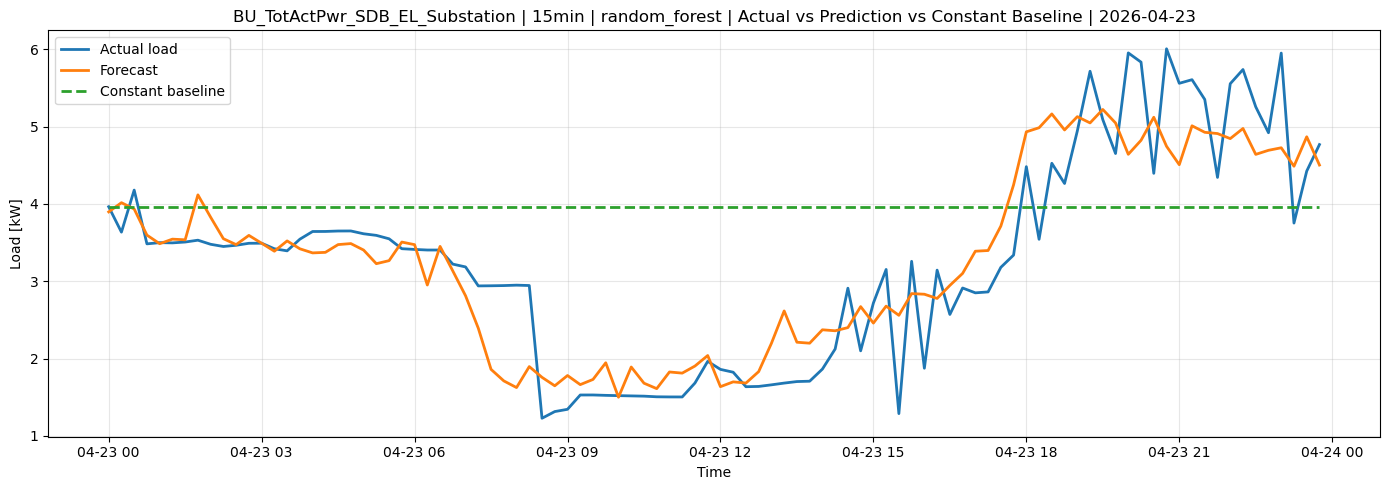

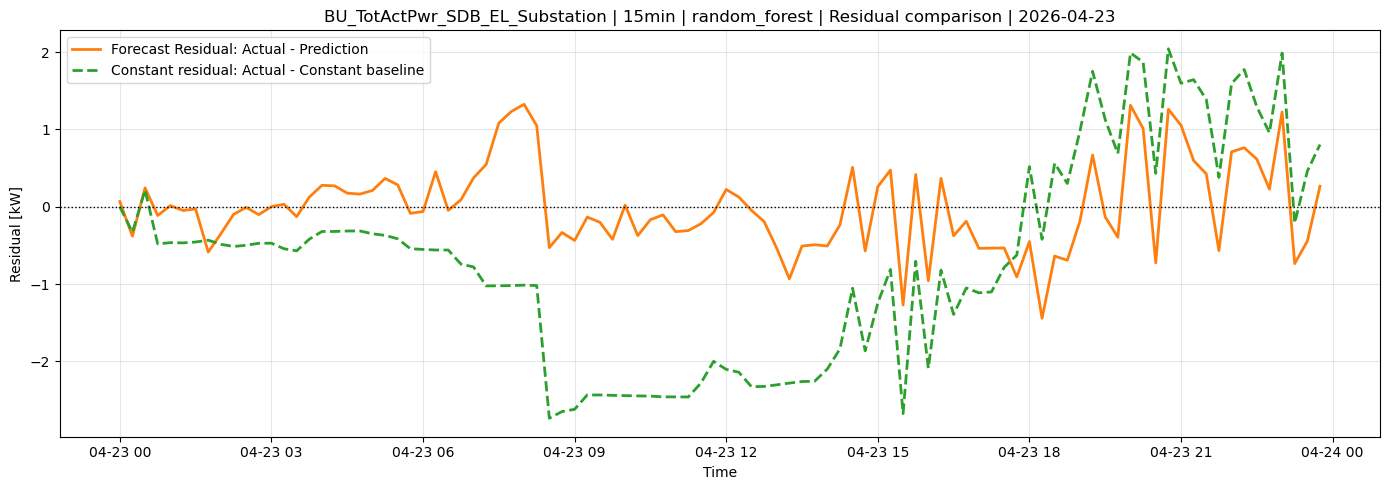

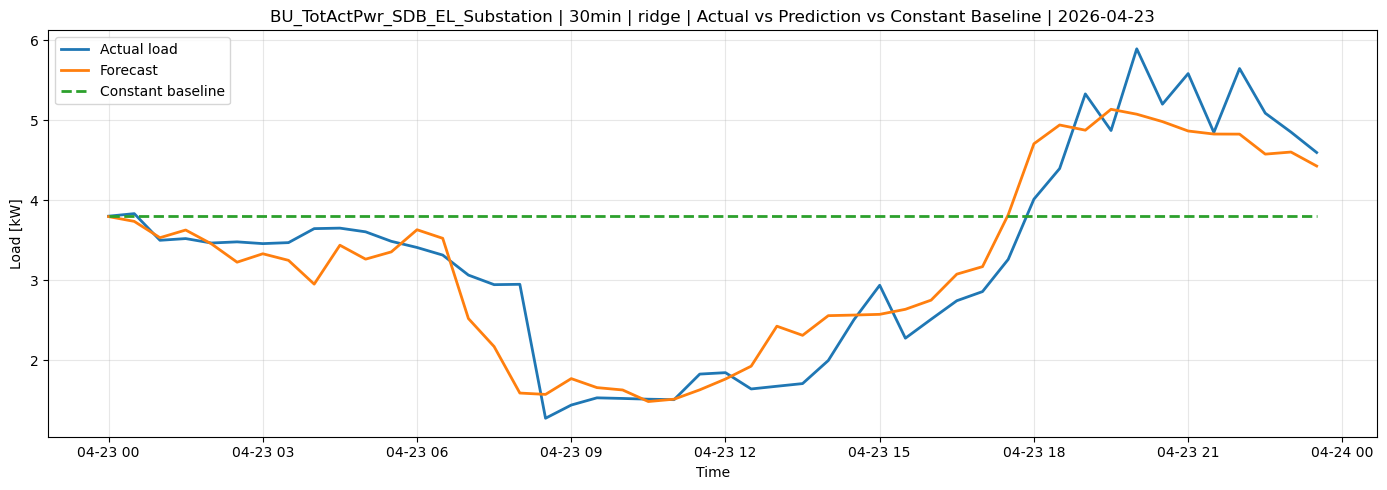

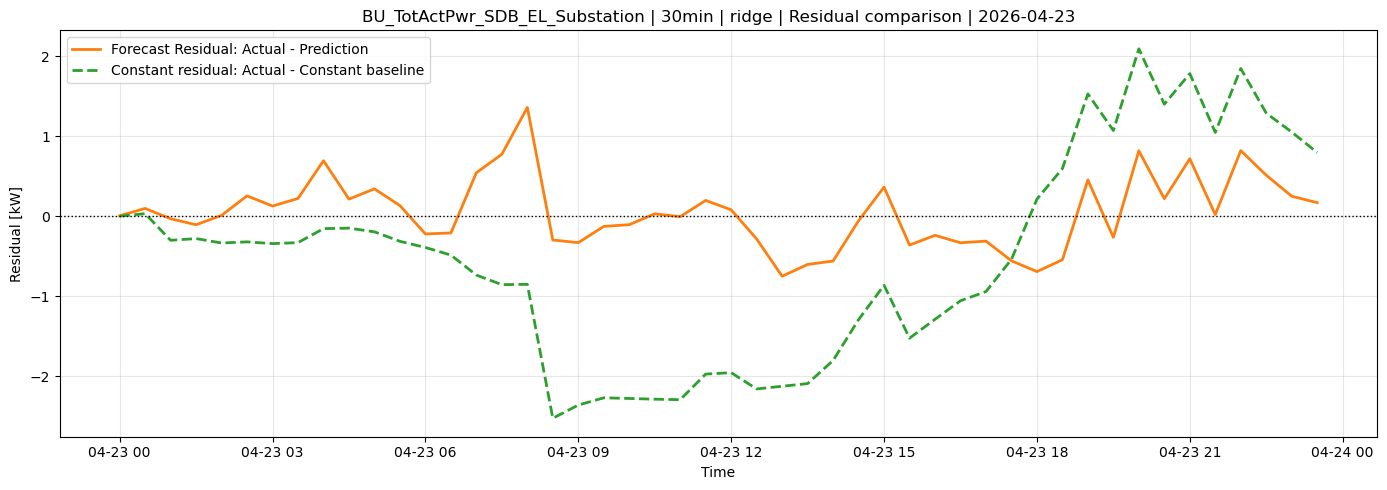

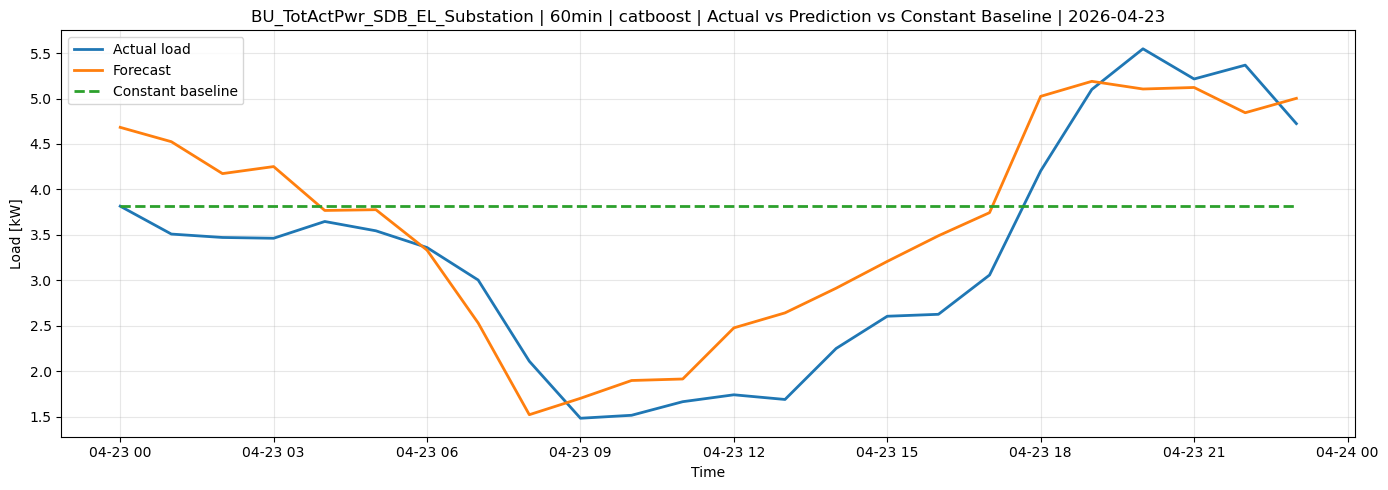

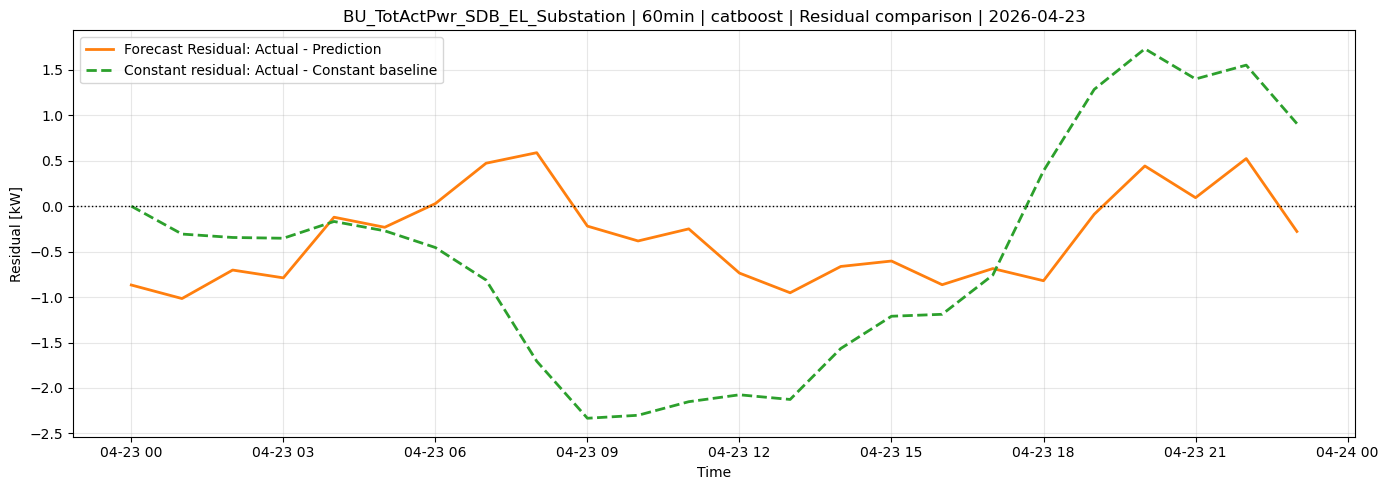

In [176]:
for _, best_row in best_each_resolution.iterrows():
    plot_forecast_and_residuals(
        best_row=best_row,
        pred_dir=pred_dir,
        forecast_date="2026-04-23"
    )